In [1]:
!pip install pennylane torch torchvision matplotlib scikit-learn seaborn fvcore -q 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.9 MB/s eta 0:00:00


In [2]:
import os
import tempfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pennylane as qml
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
from PIL import Image, ImageOps
import torchvision.transforms as transforms
from ipywidgets import FileUpload, Button, Output, VBox, Label
from IPython.display import display
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from fvcore.nn import FlopCountAnalysis
import time
import threading
import psutil
# ============================================================
# LATENT FEATURE INTERPRETABILITY ANALYSIS
# Fashion-MNIST Hybrid QNN
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from tqdm import tqdm


# ============================================================
# SIMAM-Enhanced Hybrid Quantum-Classical Neural Network
# FashionMNIST Classification
# ============================================================

print("🔥Imports Loaded!!!")

🔥Imports Loaded!!!


Using Seed: 42
Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.01MB/s]



DATASET INFORMATION
Original FashionMNIST training dataset : 60,000
Selected dataset fraction               : 100.0%
Selected samples                        : 60,000
Training samples                        : 42,000 (70.00% of original)
Validation samples                      : 9,000 (15.00% of original)
Internal test samples                   : 9,000 (15.00% of original)
Official test samples                   : 10,000

Training class distribution:
Counter({np.int64(1): 4673, np.int64(7): 4358, np.int64(3): 4284, np.int64(2): 4204, np.int64(9): 4183, np.int64(6): 4162, np.int64(0): 4121, np.int64(8): 4093, np.int64(4): 4082, np.int64(5): 3840})

Validation class distribution:
Counter({np.int64(1): 1024, np.int64(7): 983, np.int64(3): 934, np.int64(0): 907, np.int64(9): 882, np.int64(6): 877, np.int64(8): 872, np.int64(2): 868, np.int64(4): 847, np.int64(5): 806})

Internal test class distribution:
Counter({np.int64(1): 1045, np.int64(7): 924, np.int64(4): 913, np.int64(3): 913, np.int

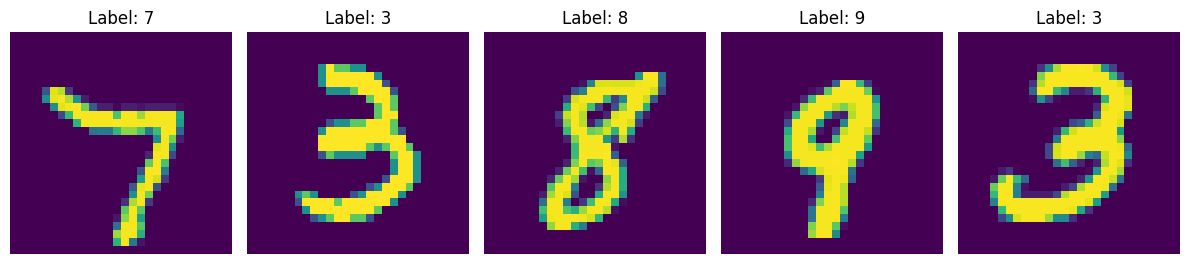


Number of Classes: 10


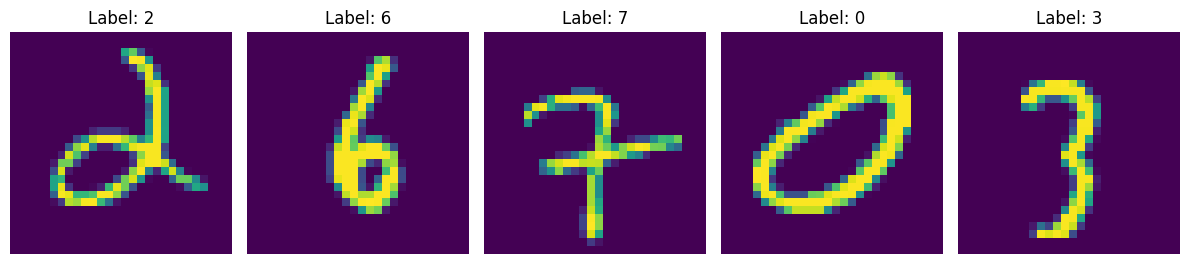

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (simam): SIMAM()
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 236,258
Trainable Parameters : 236,258
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...


Starting Training...



In [3]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 0
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================

# ============================================================
# Dataset & Data Processing
# ============================================================

# ------------------------------------------------------------
# Dataset Fractions
# ------------------------------------------------------------

DATASET_FRACTION = 1.0

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
INTERNAL_TEST_FRACTION = 0.15


# ============================================================
# Transform
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])


# ============================================================
# Load Full FashionMNIST Training Dataset
# ============================================================

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Load Official FashionMNIST Test Dataset
#
# IMPORTANT:
# This dataset is completely untouched.
# It is used ONLY for final evaluation.
# ============================================================

official_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Select 10% of Original Training Dataset
# ============================================================

total_train_samples = len(full_train_dataset)

selected_size = int(
    total_train_samples * DATASET_FRACTION
)


selected_dataset, _ = random_split(
    full_train_dataset,
    [
        selected_size,
        total_train_samples - selected_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Split Selected 10%
#
# 70% → Train
# 15% → Validation
# 15% → Internal Test
#
# Overall:
#
# 10% × 70% = 7%
# 10% × 15% = 1.5%
# 10% × 15% = 1.5%
# ============================================================

train_size = int(
    selected_size * TRAIN_FRACTION
)

val_size = int(
    selected_size * VAL_FRACTION
)

internal_test_size = (
    selected_size
    - train_size
    - val_size
)


train_dataset, val_dataset, internal_test_dataset = random_split(
    selected_dataset,
    [
        train_size,
        val_size,
        internal_test_size
    ],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# Dataset Information
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Original FashionMNIST training dataset : "
    f"{total_train_samples:,}"
)

print(
    f"Selected dataset fraction               : "
    f"{DATASET_FRACTION * 100:.1f}%"
)

print(
    f"Selected samples                        : "
    f"{selected_size:,}"
)

print(
    f"Training samples                        : "
    f"{len(train_dataset):,} "
    f"({len(train_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Validation samples                      : "
    f"{len(val_dataset):,} "
    f"({len(val_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Internal test samples                   : "
    f"{len(internal_test_dataset):,} "
    f"({len(internal_test_dataset) / total_train_samples * 100:.2f}% of original)"
)

print(
    f"Official test samples                   : "
    f"{len(official_test_dataset):,}"
)

print("=" * 60)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Official FashionMNIST test set
test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Recover Original Indices
# ============================================================

selected_indices = selected_dataset.indices

train_indices = train_dataset.indices
val_indices = val_dataset.indices
internal_test_indices = internal_test_dataset.indices


train_original_indices = [
    selected_indices[i]
    for i in train_indices
]

val_original_indices = [
    selected_indices[i]
    for i in val_indices
]

internal_test_original_indices = [
    selected_indices[i]
    for i in internal_test_indices
]


# ============================================================
# Extract Labels
# ============================================================

train_labels = (
    full_train_dataset
    .targets[train_original_indices]
    .numpy()
)

val_labels = (
    full_train_dataset
    .targets[val_original_indices]
    .numpy()
)

internal_test_labels = (
    full_train_dataset
    .targets[internal_test_original_indices]
    .numpy()
)

official_test_labels = (
    official_test_dataset
    .targets
    .numpy()
)


# ============================================================
# Class Distribution
# ============================================================

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nValidation class distribution:")
print(Counter(val_labels))

print("\nInternal test class distribution:")
print(Counter(internal_test_labels))

print("\nOfficial test class distribution:")
print(Counter(official_test_labels))


# ============================================================
# Class Weights
# ============================================================
#
# IMPORTANT:
# Calculate class weights ONLY from training data.
# Do NOT use validation or test labels.
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("\nClass Weights:")
print("-" * 30)

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()


# ============================================================
# Number of Classes
# ============================================================

NUM_CLASSES = len(
    torch.unique(
        full_train_dataset.targets
    )
)

print(
    f"\nNumber of Classes: {NUM_CLASSES}"
)




# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    img = (
        image.squeeze(0).numpy()
        * 0.3081
        + 0.1307
    )

    ax.imshow(
        img,
        # cmap="gray"
    )

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================

NUM_CLASSES = len(torch.unique(full_train_dataset.targets))

print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()


        # ====================================================
        # 1. SIMAM Attention
        # ====================================================

        self.simam = SIMAM(
            e_lambda=SIMAM_E_LAMBDA
        )


        # ====================================================
        # 2. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 784 → 256
            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # 256 → 128
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # 128 → NUM_QUBITS
            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 3. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer


        # ====================================================
        # 4. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # NUM_QUBITS → 64
            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),


            # 64 → 10
            nn.Linear(
                64,
                num_classes
            )
        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(self, x):


        # ====================================================
        # STEP 1 — Input
        # ====================================================
        #
        # x:
        #
        # [B, 1, 28, 28]
        #
        # ====================================================


        # ====================================================
        # STEP 2 — SIMAM
        # ====================================================

        x = self.simam(x)


        # ====================================================
        # STEP 3 — Flatten
        # ====================================================
        #
        # [B, 1, 28, 28]
        #
        #        ↓
        #
        # [B, 784]
        #
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 4 — Classical Feature Extraction
        # ====================================================
        #
        # 784 → 256 → 128 → NUM_QUBITS
        #
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 5 — Bound Quantum Angles
        # ====================================================
        #
        # tanh:
        #
        # [-∞, +∞] → [-1, +1]
        #
        # × π:
        #
        # [-1, +1] → [-π, +π]
        #
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 6 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit runs on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 7 — Classical Classifier
        # ====================================================
        #
        # NUM_QUBITS → 64 → 10
        #
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Best Model Tracking
# ============================================================

BEST_VAL_LOSS = float("inf")

BEST_MODEL_PATH = "best_model_val_loss.pth"

best_epoch = 0

print("\nStarting Training...\n")


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ============================================================
    # SAVE BEST MODEL
    # ============================================================
    
    # ============================================================
    # SAVE BEST MODEL BASED ON VALIDATION LOSS
    # ============================================================
    
    if val_loss < BEST_VAL_LOSS:
    
        BEST_VAL_LOSS = val_loss
        best_epoch = epoch + 1
    
        torch.save(
            {
                "epoch": best_epoch,
    
                # Model parameters
                "model_state_dict": model.state_dict(),
    
                # Optimizer state
                "optimizer_state_dict": optimizer.state_dict(),
    
                # Metrics
                "best_val_loss": BEST_VAL_LOSS,
                "val_accuracy": val_acc,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
    
                # Architecture configuration
                "num_qubits": NUM_QUBITS,
                "num_layers": NUM_LAYERS,
                "num_classes": NUM_CLASSES,
                "learning_rate": LR,
            },
            "best_model_checkpoint.pth"
        )
    
        print(
            f"\n✓ Best model saved | "
            f"Epoch: {best_epoch} | "
            f"Val Loss: {BEST_VAL_LOSS:.4f}"
        )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )

In [4]:
import os
import zipfile
import torch

CHECKPOINT_DIR = "/kaggle/input/datasets/dillihangrai078/modeli/best_model_checkpoint"
RECONSTRUCTED_PATH = "/kaggle/working/best_model_checkpoint.pth"

with zipfile.ZipFile(RECONSTRUCTED_PATH, "w", zipfile.ZIP_DEFLATED) as z:

    for root, dirs, files in os.walk(CHECKPOINT_DIR):

        for file in files:

            full_path = os.path.join(root, file)

            relative_path = os.path.relpath(
                full_path,
                CHECKPOINT_DIR
            )

            z.write(
                full_path,
                relative_path
            )

print("✓ Reconstructed checkpoint:")
print(RECONSTRUCTED_PATH)
print("Size:", os.path.getsize(RECONSTRUCTED_PATH), "bytes")

✓ Reconstructed checkpoint:
/kaggle/working/best_model_checkpoint.pth
Size: 2034760 bytes


In [5]:
import os

path = "/kaggle/working/best_model_checkpoint.pth"

print("=" * 60)
print("CHECKING EXISTING CHECKPOINT")
print("=" * 60)

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("Path:", path)
    print(
        "Size:",
        f"{os.path.getsize(path) / (1024**2):.2f} MB"
    )

    print(
        "Absolute path:",
        os.path.abspath(path)
    )

print("=" * 60)

CHECKING EXISTING CHECKPOINT
Exists: True
Path: /kaggle/working/best_model_checkpoint.pth
Size: 1.94 MB
Absolute path: /kaggle/working/best_model_checkpoint.pth


In [6]:
import os

MODEL_DIR = "/kaggle/input/datasets/dillihangrai078/modeli/best_model_checkpoint"

print("=" * 60)
print("MODEL DIRECTORY")
print("=" * 60)

print("Exists:", os.path.exists(MODEL_DIR))
print("Is directory:", os.path.isdir(MODEL_DIR))

if os.path.isdir(MODEL_DIR):

    for root, dirs, files in os.walk(MODEL_DIR):

        level = root.replace(MODEL_DIR, "").count(os.sep)
        indent = "    " * level

        print(f"{indent}{os.path.basename(root)}/")

        for file in files:
            filepath = os.path.join(root, file)
            size = os.path.getsize(filepath)

            print(
                f"{indent}    {file} "
                f"({size:,} bytes)"
            )

print("=" * 60)

MODEL DIRECTORY
Exists: True
Is directory: True
best_model_checkpoint/
    data.pkl (4,088 bytes)
    version (2 bytes)
    byteorder (6 bytes)
    data/
        7 (2,048 bytes)
        17 (4 bytes)
        19 (131,072 bytes)
        22 (512 bytes)
        2 (131,072 bytes)
        35 (4 bytes)
        23 (4 bytes)
        10 (40 bytes)
        5 (32 bytes)
        36 (256 bytes)
        20 (4 bytes)
        27 (32 bytes)
        41 (4 bytes)
        39 (2,560 bytes)
        32 (4 bytes)
        25 (4,096 bytes)
        42 (40 bytes)
        8 (256 bytes)
        38 (4 bytes)
        12 (802,816 bytes)
        0 (802,816 bytes)
        31 (576 bytes)
        34 (2,048 bytes)
        18 (131,072 bytes)
        28 (32 bytes)
        16 (1,024 bytes)
        13 (802,816 bytes)
        26 (4 bytes)
        15 (1,024 bytes)
        3 (512 bytes)
        43 (40 bytes)
        1 (1,024 bytes)
        30 (576 bytes)
        14 (4 bytes)
        4 (4,096 bytes)
        9 (2,560 bytes)
        2

In [7]:
import os
import zipfile
import shutil

# ============================================================
# ORIGINAL EXTRACTED CHECKPOINT
# ============================================================

SOURCE_DIR = (
    "/kaggle/input/datasets/"
    "dillihangrai078/modeli/"
    "best_model_checkpoint"
)

# ============================================================
# RECONSTRUCTED CHECKPOINT
# ============================================================

RECONSTRUCTED_PATH = (
    "/kaggle/working/"
    "best_model_checkpoint_reconstructed.pth"
)

# Remove previous reconstruction if it exists
if os.path.exists(RECONSTRUCTED_PATH):
    os.remove(RECONSTRUCTED_PATH)


# ============================================================
# CREATE PYTORCH ZIP ARCHIVE
# ============================================================

with zipfile.ZipFile(
    RECONSTRUCTED_PATH,
    "w",
    compression=zipfile.ZIP_STORED
) as z:

    # --------------------------------------------------------
    # IMPORTANT:
    # PyTorch expects everything under a common directory.
    # --------------------------------------------------------

    z.write(
        os.path.join(SOURCE_DIR, "data.pkl"),
        "archive/data.pkl"
    )

    z.write(
        os.path.join(SOURCE_DIR, "byteorder"),
        "archive/byteorder"
    )

    z.write(
        os.path.join(SOURCE_DIR, "version"),
        "archive/version"
    )

    # --------------------------------------------------------
    # Tensor storage files
    # --------------------------------------------------------

    DATA_DIR = os.path.join(
        SOURCE_DIR,
        "data"
    )

    for filename in os.listdir(DATA_DIR):

        source_file = os.path.join(
            DATA_DIR,
            filename
        )

        z.write(
            source_file,
            f"archive/data/{filename}"
        )


print("=" * 60)
print("CHECKPOINT RECONSTRUCTION")
print("=" * 60)

print("✓ Reconstruction complete")

print(
    f"Path : {RECONSTRUCTED_PATH}"
)

print(
    f"Size : "
    f"{os.path.getsize(RECONSTRUCTED_PATH) / (1024**2):.2f} MB"
)

print("=" * 60)

CHECKPOINT RECONSTRUCTION
✓ Reconstruction complete
Path : /kaggle/working/best_model_checkpoint_reconstructed.pth
Size : 2.71 MB


In [8]:
import zipfile

print("=" * 60)
print("VERIFYING RECONSTRUCTED CHECKPOINT")
print("=" * 60)

with zipfile.ZipFile(
    RECONSTRUCTED_PATH,
    "r"
) as z:

    files = z.namelist()

    for name in files:
        print(name)

print("=" * 60)

VERIFYING RECONSTRUCTED CHECKPOINT
archive/data.pkl
archive/byteorder
archive/version
archive/data/7
archive/data/17
archive/data/19
archive/data/22
archive/data/2
archive/data/35
archive/data/23
archive/data/10
archive/data/5
archive/data/36
archive/data/20
archive/data/27
archive/data/41
archive/data/39
archive/data/32
archive/data/25
archive/data/42
archive/data/8
archive/data/38
archive/data/12
archive/data/0
archive/data/31
archive/data/34
archive/data/18
archive/data/28
archive/data/16
archive/data/13
archive/data/26
archive/data/15
archive/data/3
archive/data/43
archive/data/1
archive/data/30
archive/data/14
archive/data/4
archive/data/9
archive/data/21
archive/data/40
archive/data/6
archive/data/11
archive/data/37
archive/data/33
archive/data/29
archive/data/24


In [9]:
checkpoint = torch.load(
    RECONSTRUCTED_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("=" * 60)
print("CHECKPOINT LOADED")
print("=" * 60)

print("Epoch:", checkpoint["epoch"])
print("Best Val Loss:", checkpoint["best_val_loss"])
print("Val Accuracy:", checkpoint["val_accuracy"])
print("Train Loss:", checkpoint["train_loss"])
print("Train Accuracy:", checkpoint["train_accuracy"])
print("Qubits:", checkpoint["num_qubits"])
print("Layers:", checkpoint["num_layers"])
print("Classes:", checkpoint["num_classes"])

print("=" * 60)

CHECKPOINT LOADED
Epoch: 8
Best Val Loss: 0.14071235142595379
Val Accuracy: 96.74444444444444
Train Loss: 0.05241770211811343
Train Accuracy: 98.58571428571429
Qubits: 8
Layers: 6
Classes: 10


In [10]:
# ============================================================
# IMPORT / LOAD BEST SAVED MODEL
# ============================================================

BEST_MODEL_PATH = RECONSTRUCTED_PATH

print("\n" + "=" * 60)
print("LOADING BEST SAVED MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

print(
    f"Checkpoint Epoch     : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Validation Loss : "
    f"{checkpoint['best_val_loss']:.4f}"
)

print(
    f"Validation Accuracy  : "
    f"{checkpoint['val_accuracy']:.2f}%"
)

print("=" * 60)


# ============================================================
# RECREATE MODEL
# ============================================================

loaded_model = DeepQNN(
    num_classes=checkpoint["num_classes"]
).to(DEVICE)


# ============================================================
# LOAD MODEL PARAMETERS
# ============================================================

loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)


# ============================================================
# EVALUATION MODE
# ============================================================

loaded_model.eval()

print("\n✓ Best model successfully loaded.")
print(f"✓ Model loaded from epoch: {checkpoint['epoch']}")


# ============================================================
# TEST ON OFFICIAL TEST DATASET
# ============================================================

test_loss = 0.0
test_correct = 0
test_total = 0


print("\n" + "=" * 60)
print("TESTING BEST SAVED MODEL")
print("=" * 60)


with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=True
    )

    for step, (images, labels) in enumerate(
        test_bar,
        start=1
    ):

        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = loaded_model(images)


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        test_total += labels.size(0)

        test_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        test_bar.set_postfix(
            Loss=f"{test_loss / step:.4f}",
            Acc=f"{100 * test_correct / test_total:.2f}%"
        )


# ============================================================
# FINAL TEST METRICS
# ============================================================

test_loss /= len(test_loader)

test_accuracy = (
    100.0
    * test_correct
    / test_total
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("BEST MODEL TEST RESULTS")
print("=" * 60)

print(
    f"Best Epoch       : "
    f"{checkpoint['epoch']}"
)

print(
    f"Test Samples     : "
    f"{test_total:,}"
)

print(
    f"Test Loss        : "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy    : "
    f"{test_accuracy:.2f}%"
)

print(
    f"Correct          : "
    f"{test_correct:,}"
)

print(
    f"Incorrect        : "
    f"{test_total - test_correct:,}"
)

print("=" * 60)


LOADING BEST SAVED MODEL
Checkpoint Epoch     : 8
Best Validation Loss : 0.1407
Validation Accuracy  : 96.74%

✓ Best model successfully loaded.
✓ Model loaded from epoch: 8

TESTING BEST SAVED MODEL


Testing: 100%|██████████| 157/157 [00:12<00:00, 12.24it/s, Acc=96.90%, Loss=0.1339]


BEST MODEL TEST RESULTS
Best Epoch       : 8
Test Samples     : 10,000
Test Loss        : 0.1339
Test Accuracy    : 96.90%
Correct          : 9,690
Incorrect        : 310



SINGLE SAMPLE TEST
Sample Index    : 912
True Label      : 3
Predicted Label : 3
Result          : CORRECT ✓


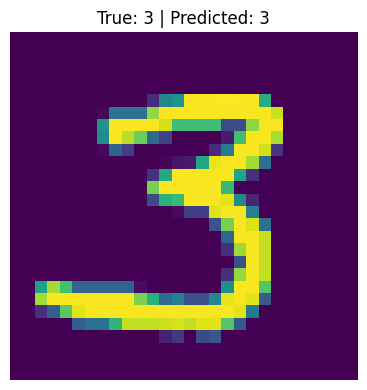

In [11]:
# ============================================================
# TEST ONE RANDOM TEST SAMPLE
# ============================================================

sample_index = np.random.randint(
    0,
    len(official_test_dataset)
)

image, true_label = official_test_dataset[
    sample_index
]


# ------------------------------------------------------------
# Add batch dimension
# ------------------------------------------------------------

input_image = image.unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

loaded_model.eval()

with torch.no_grad():

    output = loaded_model(
        input_image
    )

    predicted_label = output.argmax(
        dim=1
    ).item()


# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n" + "=" * 60)
print("SINGLE SAMPLE TEST")
print("=" * 60)

print(
    f"Sample Index    : {sample_index}"
)

print(
    f"True Label      : {true_label}"
)

print(
    f"Predicted Label : {predicted_label}"
)

print(
    f"Result          : "
    f"{'CORRECT ✓' if predicted_label == true_label else 'WRONG ✗'}"
)

print("=" * 60)


# ============================================================
# VISUALIZE SAMPLE
# ============================================================

img = (
    image.squeeze(0).cpu().numpy()
    * 0.3081
    + 0.1307
)

plt.figure(figsize=(4, 4))

plt.imshow(img)

plt.title(
    f"True: {true_label} | "
    f"Predicted: {predicted_label}"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
# MODEL SIZE
# ============================================================

def get_model_size_mb(model):
    """
    Save model state_dict temporarily and measure
    serialized checkpoint size in MB.
    """

    with tempfile.NamedTemporaryFile(
        suffix=".pth",
        delete=False
    ) as tmp:

        temp_path = tmp.name

    torch.save(
        model.state_dict(),
        temp_path
    )

    size_bytes = os.path.getsize(temp_path)

    os.remove(temp_path)

    size_mb = size_bytes / (1024 ** 2)

    return size_mb


model_size_mb = get_model_size_mb(model)

print("\nModel Size")
print("=" * 40)

print(
    f"Model Size: {model_size_mb:.4f} MB"
)


# ============================================================
# INFERENCE TIME
# ============================================================

model.eval()

images, labels = next(iter(test_loader))

images = images.to(DEVICE)


# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

with torch.no_grad():

    for _ in range(10):
        _ = model(images)


# ------------------------------------------------------------
# Measure inference
# ------------------------------------------------------------

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    _ = model(images)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()

inference_time = end_time - start_time

batch_size = images.size(0)

time_per_image = (
    inference_time / batch_size
)

throughput = (
    batch_size / inference_time
)


print("\nInference Efficiency")
print("=" * 40)

print(
    f"Batch Size          : {batch_size}"
)

print(
    f"Batch Inference Time: "
    f"{inference_time * 1000:.4f} ms"
)

print(
    f"Time per Image      : "
    f"{time_per_image * 1000:.4f} ms"
)

print(
    f"Throughput          : "
    f"{throughput:.2f} images/sec"
)


Model Size
Model Size: 0.9056 MB

Inference Efficiency
Batch Size          : 64
Batch Inference Time: 58.0097 ms
Time per Image      : 0.9064 ms
Throughput          : 1103.26 images/sec


In [13]:
# ============================================================
# BASIC EFFICIENCY TESTING
# (paste after your training + testing code, once `model`
#  is trained and `test_loader` exists)
# ============================================================

# ------------------------------------------------------------
# 1. Parameter Count
# ------------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params


# ------------------------------------------------------------
# 2. Model Size on Disk
# ------------------------------------------------------------

with tempfile.NamedTemporaryFile(suffix=".pth", delete=False) as tmp:
    temp_path = tmp.name

torch.save(model.state_dict(), temp_path)
model_size_bytes = os.path.getsize(temp_path)
os.remove(temp_path)

model_size_mb = model_size_bytes / (1024 ** 2)


# ------------------------------------------------------------
# Results — Parameters & Size
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL SIZE AND PARAMETER COUNT")
print("=" * 60)
print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Non-Trainable Params  : {non_trainable_params:,}")
print(f"Model Size            : {model_size_mb:.4f} MB")
print("=" * 60)


# ------------------------------------------------------------
# 3. Inference Time & Throughput
# ------------------------------------------------------------

model.eval()

images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Warm-up
with torch.no_grad():
    for _ in range(10):
        _ = model(images)

# Timed run
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    _ = model(images)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()

inference_time = end_time - start_time
batch_size = images.size(0)
time_per_image = inference_time / batch_size
throughput = batch_size / inference_time

print("\nInference Efficiency")
print("=" * 40)
print(f"Batch Size          : {batch_size}")
print(f"Batch Inference Time: {inference_time * 1000:.4f} ms")
print(f"Time per Image      : {time_per_image * 1000:.4f} ms")
print(f"Throughput          : {throughput:.2f} images/sec")
print("=" * 40)


MODEL SIZE AND PARAMETER COUNT
Total Parameters      : 236,258
Trainable Parameters  : 236,258
Non-Trainable Params  : 0
Model Size            : 0.9056 MB

Inference Efficiency
Batch Size          : 64
Batch Inference Time: 60.2646 ms
Time per Image      : 0.9416 ms
Throughput          : 1061.98 images/sec


In [14]:
# ============================================================
# MNIST QUANTUM MEASUREMENT ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# ============================================================
# Storage
# ============================================================

quantum_measurements = []
quantum_labels = []


# ============================================================
# Hook Quantum Layer
# ============================================================

def quantum_hook(module, inputs, output):

    quantum_measurements.append(
        output.detach().cpu()
    )


# ============================================================
# Register Hook
# ============================================================

hook_handle = loaded_model.quantum.register_forward_hook(
    quantum_hook
)


# ============================================================
# Extract Quantum Measurements
# ============================================================

loaded_model.eval()

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Extracting MNIST Quantum Measurements"
    ):

        images = images.to(DEVICE)

        _ = loaded_model(images)

        quantum_labels.append(
            labels.cpu()
        )


# ============================================================
# Remove Hook
# ============================================================

hook_handle.remove()


# ============================================================
# Combine
# ============================================================

quantum_measurements = torch.cat(
    quantum_measurements,
    dim=0
)

quantum_labels = torch.cat(
    quantum_labels,
    dim=0
)


print("\n" + "=" * 60)
print("MNIST QUANTUM MEASUREMENT EXTRACTION")
print("=" * 60)

print(
    f"Test Samples      : "
    f"{len(quantum_measurements):,}"
)

print(
    f"Quantum Qubits    : "
    f"{quantum_measurements.shape[1]}"
)

print(
    f"Measurement Shape : "
    f"{tuple(quantum_measurements.shape)}"
)

print("=" * 60)

Extracting MNIST Quantum Measurements: 100%|██████████| 157/157 [00:12<00:00, 12.21it/s]


MNIST QUANTUM MEASUREMENT EXTRACTION
Test Samples      : 10,000
Quantum Qubits    : 8
Measurement Shape : (10000, 8)


In [15]:
# ============================================================
# CLASS-WISE QUANTUM MEASUREMENT MEANS
# ============================================================

q_np = quantum_measurements.numpy()
labels_np = quantum_labels.numpy()

class_means = np.zeros(
    (10, NUM_QUBITS)
)

for digit in range(10):

    mask = (
        labels_np == digit
    )

    class_means[digit] = np.mean(
        q_np[mask],
        axis=0
    )


class_quantum_df = pd.DataFrame(
    class_means,
    index=[
        str(i)
        for i in range(10)
    ],
    columns=[
        f"Q{i}"
        for i in range(NUM_QUBITS)
    ]
)

print("\n")
print("=" * 60)
print("MNIST CLASS-WISE QUANTUM MEASUREMENT MEANS")
print("=" * 60)

print(
    class_quantum_df.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 60)



MNIST CLASS-WISE QUANTUM MEASUREMENT MEANS
       Q0      Q1      Q2      Q3      Q4      Q5      Q6      Q7
0 -0.0147 -0.0790  0.0855  0.1616  0.0063  0.1347 -0.2170  0.0023
1 -0.0165 -0.2031  0.2076  0.1827  0.2778  0.0454  0.1073  0.1513
2  0.0357 -0.0179  0.0830 -0.1891 -0.0502 -0.1865  0.1173  0.2237
3 -0.0332  0.2924  0.1162  0.1283 -0.0236  0.1095  0.1868 -0.1359
4 -0.0785 -0.0603 -0.2107 -0.2788 -0.0073  0.0411 -0.1276  0.0452
5  0.1369  0.2210 -0.2054 -0.0387 -0.2189 -0.0571  0.0937  0.0212
6  0.2226 -0.1605  0.0397  0.0374 -0.2733 -0.1078 -0.1079 -0.0667
7 -0.0546 -0.1247 -0.2547  0.0016  0.1787 -0.0257  0.2345  0.1439
8  0.0870 -0.0575  0.1539  0.1757  0.0367 -0.1950  0.1927 -0.1618
9 -0.2751  0.1150 -0.0701 -0.0820  0.1261  0.1127  0.1872 -0.1053


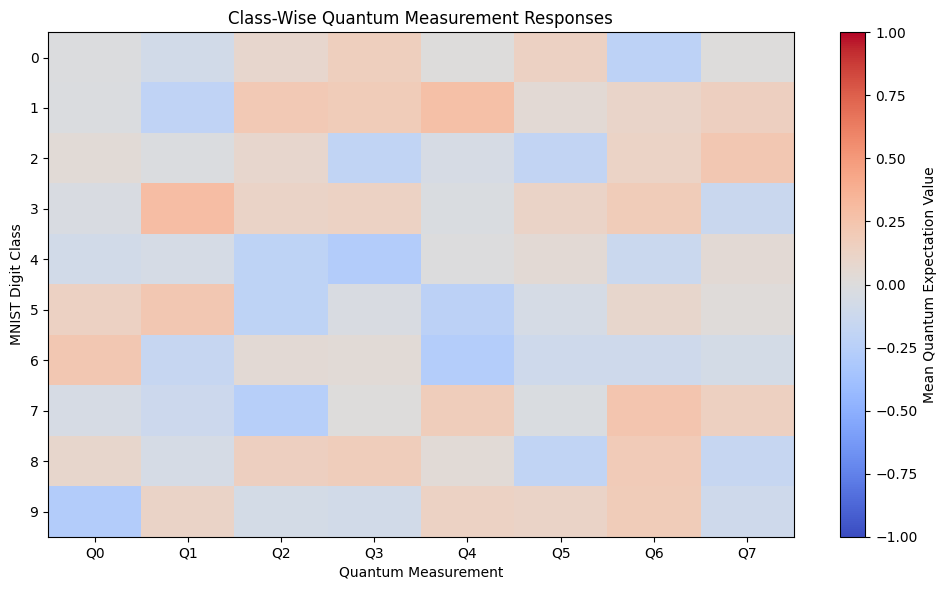

In [16]:
# ============================================================
# MNIST QUANTUM MEASUREMENT HEATMAP
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.imshow(
    class_means,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Mean Quantum Expectation Value"
)

plt.xticks(
    range(NUM_QUBITS),
    [
        f"Q{i}"
        for i in range(NUM_QUBITS)
    ]
)

plt.yticks(
    range(10),
    [
        str(i)
        for i in range(10)
    ]
)

plt.xlabel(
    "Quantum Measurement"
)

plt.ylabel(
    "MNIST Digit Class"
)

plt.title(
    "Class-Wise Quantum Measurement Responses"
)

plt.tight_layout()

plt.savefig(
    "mnist_quantum_measurement_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ============================================================
# QUANTUM MEASUREMENT DISCRIMINABILITY
# ============================================================

qubit_discriminability = np.std(
    class_means,
    axis=0
)

print("\n")
print("=" * 60)
print("QUANTUM MEASUREMENT DISCRIMINABILITY")
print("=" * 60)

for q in range(NUM_QUBITS):

    print(
        f"Q{q}: "
        f"{qubit_discriminability[q]:.4f}"
    )

print("=" * 60)


# ============================================================
# Ranking
# ============================================================

ranking = np.argsort(
    qubit_discriminability
)[::-1]

print("\nQubit Ranking:")
print("-" * 40)

for rank, q in enumerate(
    ranking,
    start=1
):

    print(
        f"{rank}. Q{q} "
        f"→ {qubit_discriminability[q]:.4f}"
    )



QUANTUM MEASUREMENT DISCRIMINABILITY
Q0: 0.1279
Q1: 0.1559
Q2: 0.1588
Q3: 0.1513
Q4: 0.1587
Q5: 0.1154
Q6: 0.1505
Q7: 0.1245

Qubit Ranking:
----------------------------------------
1. Q2 → 0.1588
2. Q4 → 0.1587
3. Q1 → 0.1559
4. Q3 → 0.1513
5. Q6 → 0.1505
6. Q0 → 0.1279
7. Q7 → 0.1245
8. Q5 → 0.1154


Loaded checkpoint from epoch 8 (Val Loss: 0.1407)

Collected quantum measurements: (9000, 8)
Range: [-0.3645, 0.3806]

Mean <Z> per Qubit by Class:
------------------------------------------------------------
           Q0      Q1      Q2      Q3      Q4      Q5      Q6      Q7
label                                                                
0     -0.0165 -0.0762  0.0863  0.1598  0.0061  0.1321 -0.2166  0.0032
1     -0.0148 -0.2032  0.2043  0.1798  0.2740  0.0451  0.1093  0.1537
2      0.0355 -0.0183  0.0831 -0.1920 -0.0489 -0.1887  0.1193  0.2249
3     -0.0284  0.2878  0.1156  0.1276 -0.0219  0.1040  0.1862 -0.1338
4     -0.0805 -0.0597 -0.2092 -0.2775 -0.0053  0.0412 -0.1244  0.0451
5      0.1343  0.2173 -0.2014 -0.0331 -0.2193 -0.0573  0.0968  0.0186
6      0.2273 -0.1661  0.0411  0.0367 -0.2806 -0.1099 -0.1107 -0.0697
7     -0.0538 -0.1271 -0.2627  0.0015  0.1770 -0.0279  0.2311  0.1441
8      0.0872 -0.0592  0.1543  0.1742  0.0383 -0.1947  0.1935 -0.1620
9     -0.2764  0.1146

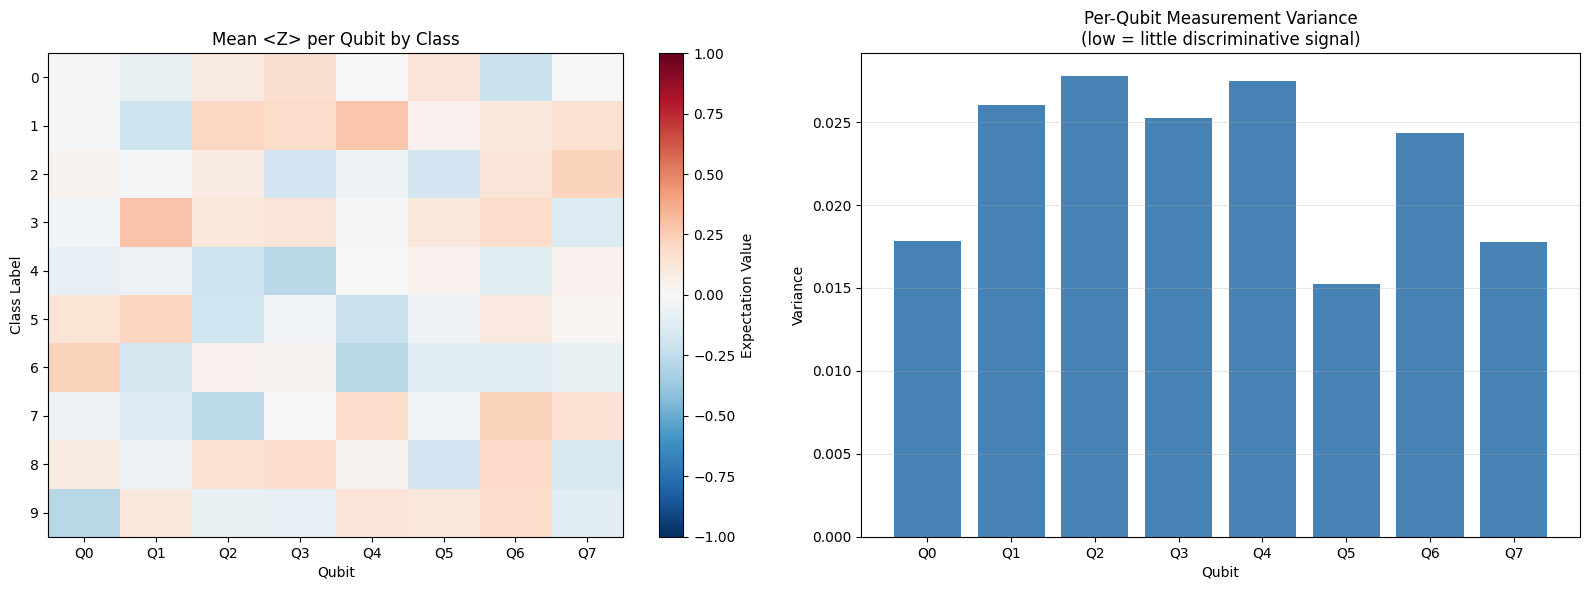


Saved diagram to: quantum_measurement_analysis.png


In [18]:
# ============================================================
# QUANTUM MEASUREMENT TRANSPARENCY ANALYSIS
# ============================================================
# Run this AFTER training (make sure EPOCHS > 0, otherwise the
# model is untrained and this will just show random noise).
# Uses the internal test set to inspect what the quantum layer
# is actually outputting per class.
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load best checkpoint (optional but recommended)
# ------------------------------------------------------------

checkpoint = torch.load("/kaggle/working/best_model_checkpoint_reconstructed.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} "
      f"(Val Loss: {checkpoint['best_val_loss']:.4f})")

# ------------------------------------------------------------
# Hook to capture raw quantum layer output (Pauli-Z expvals)
# ------------------------------------------------------------

quantum_outputs_log = []

def capture_quantum_output(module, inputs, output):
    quantum_outputs_log.append(output.detach().cpu().numpy())

hook_handle = model.quantum.register_forward_hook(capture_quantum_output)

# ------------------------------------------------------------
# Run inference over the internal test set to collect outputs
# ------------------------------------------------------------

quantum_outputs_log.clear()
all_labels = []

with torch.no_grad():
    for images, labels in internal_test_loader:
        images = images.to(DEVICE)
        _ = model(images)          # triggers the hook
        all_labels.append(labels.numpy())

hook_handle.remove()

all_outputs = np.concatenate(quantum_outputs_log, axis=0)   # [N, NUM_QUBITS]
all_labels = np.concatenate(all_labels, axis=0)             # [N]

print(f"\nCollected quantum measurements: {all_outputs.shape}")
print(f"Range: [{all_outputs.min():.4f}, {all_outputs.max():.4f}]")

# ------------------------------------------------------------
# Build DataFrame: rows = samples, cols = qubits + label
# ------------------------------------------------------------

df = pd.DataFrame(all_outputs, columns=[f"Q{i}" for i in range(NUM_QUBITS)])
df["label"] = all_labels

# ------------------------------------------------------------
# 1. Mean expectation value per qubit, per class
# ------------------------------------------------------------

class_profile = df.groupby("label").mean()

print("\nMean <Z> per Qubit by Class:")
print("-" * 60)
print(class_profile.round(4))

# ------------------------------------------------------------
# 2. Per-qubit variance across the whole dataset
#    (near-zero variance = qubit is not discriminative /
#     possible barren-plateau symptom)
# ------------------------------------------------------------

qubit_variance = df.iloc[:, :NUM_QUBITS].var()

print("\nPer-Qubit Variance (dataset-wide):")
print("-" * 60)
print(qubit_variance.round(6))

# ------------------------------------------------------------
# 3. Diagram: heatmap of mean <Z> per qubit per class
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Heatmap ---
im = axes[0].imshow(
    class_profile.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)
axes[0].set_xticks(range(NUM_QUBITS))
axes[0].set_xticklabels(class_profile.columns)
axes[0].set_yticks(range(len(class_profile.index)))
axes[0].set_yticklabels(class_profile.index)
axes[0].set_xlabel("Qubit")
axes[0].set_ylabel("Class Label")
axes[0].set_title("Mean <Z> per Qubit by Class")
plt.colorbar(im, ax=axes[0], label="Expectation Value")

# --- Variance bar chart ---
axes[1].bar(range(NUM_QUBITS), qubit_variance.values, color="steelblue")
axes[1].set_xticks(range(NUM_QUBITS))
axes[1].set_xticklabels([f"Q{i}" for i in range(NUM_QUBITS)])
axes[1].set_xlabel("Qubit")
axes[1].set_ylabel("Variance")
axes[1].set_title("Per-Qubit Measurement Variance\n(low = little discriminative signal)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("quantum_measurement_analysis.png", dpi=150)
plt.show()

print("\nSaved diagram to: quantum_measurement_analysis.png")

Loaded checkpoint | Epoch: 8 | Val Loss: 0.1407 | Val Acc: 96.74%


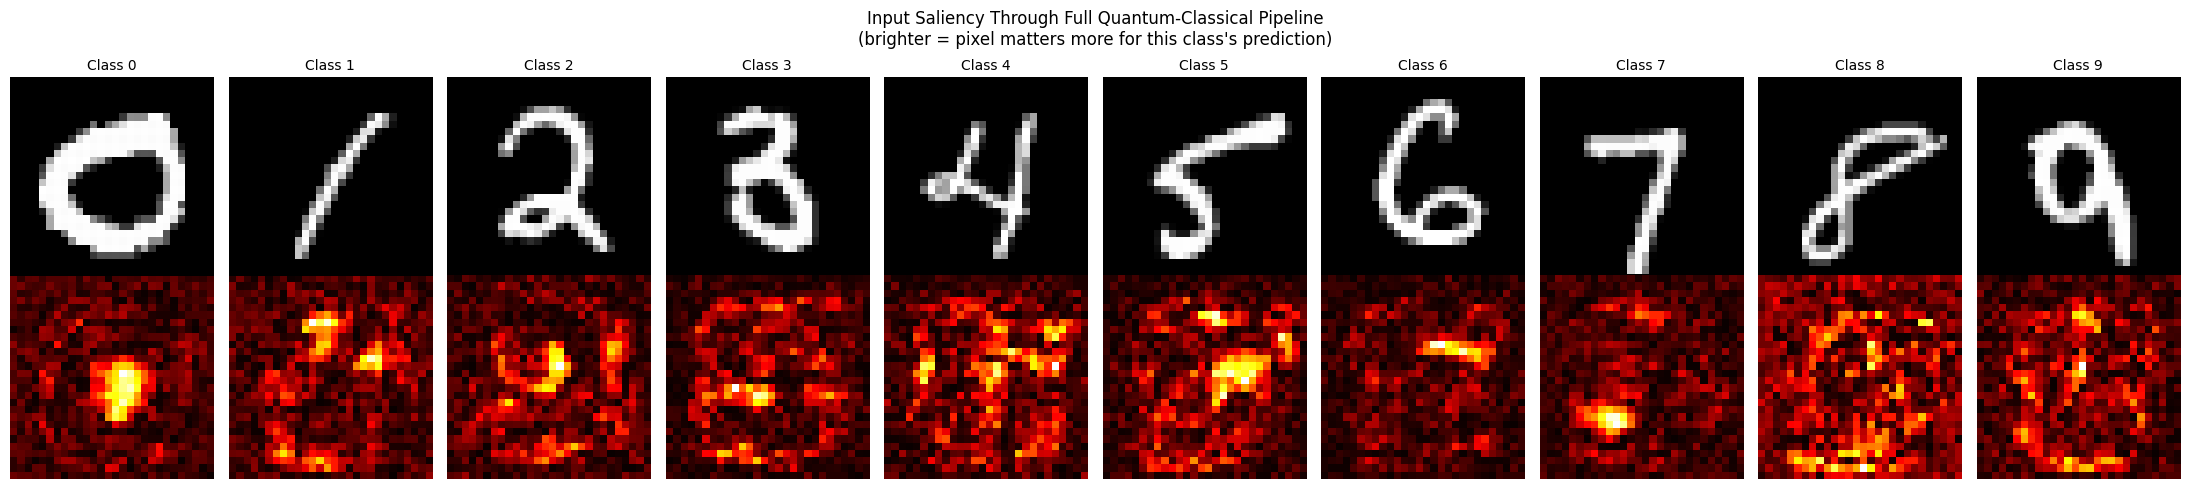

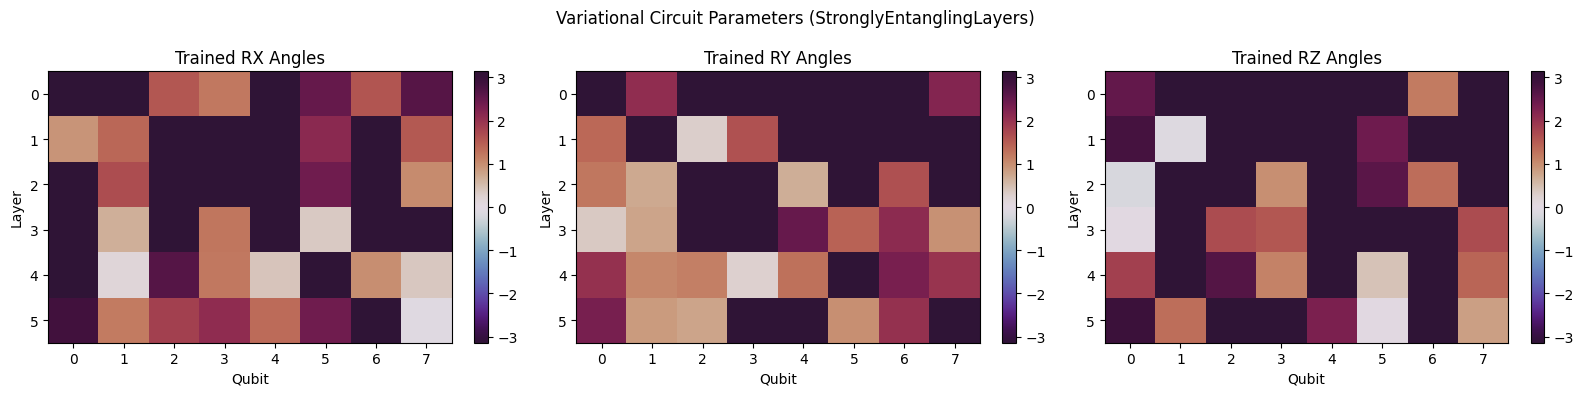


Average |weight| per layer (higher = more active layer):
  Layer 0: 3.7485
  Layer 1: 3.3023
  Layer 2: 3.1155
  Layer 3: 2.8885
  Layer 4: 2.0848
  Layer 5: 2.5360

Baseline (no ablation) | Acc: 96.74% | Conf: 0.9809
  Ablate Q0: Acc=96.83% (Δ=-0.09%) | Conf=0.9641
  Ablate Q1: Acc=96.02% (Δ=+0.72%) | Conf=0.9422
  Ablate Q2: Acc=96.18% (Δ=+0.57%) | Conf=0.9437
  Ablate Q3: Acc=96.27% (Δ=+0.48%) | Conf=0.9543
  Ablate Q4: Acc=96.06% (Δ=+0.69%) | Conf=0.9594
  Ablate Q5: Acc=96.58% (Δ=+0.17%) | Conf=0.9676
  Ablate Q6: Acc=96.59% (Δ=+0.16%) | Conf=0.9587
  Ablate Q7: Acc=96.40% (Δ=+0.34%) | Conf=0.9655


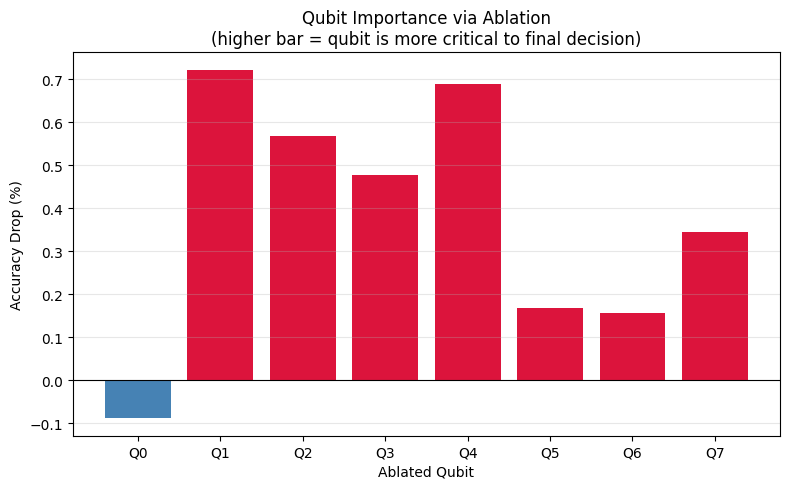


QUANTUM CIRCUIT INTERPRETABILITY SUMMARY
Qubit  Ablation_Acc_Drop_%
   Q0            -0.088889
   Q1             0.722222
   Q2             0.566667
   Q3             0.477778
   Q4             0.688889
   Q5             0.166667
   Q6             0.155556
   Q7             0.344444
Saved figures:
  - quantum_input_saliency.png   (which pixels drive the circuit)
  - quantum_circuit_weights.png  (what the trained gates look like)
  - quantum_qubit_ablation.png   (which qubits matter for output)


In [19]:
# ============================================================
# QUANTUM CIRCUIT INTERPRETABILITY ANALYSIS
# ============================================================
# Goal: open up the "black box" — show what the variational
# quantum circuit is doing at three levels:
#
#   1. INPUT  -> which pixels drive the encoding angles
#               (gradient-based saliency, end-to-end)
#   2. CIRCUIT -> what the trained variational weights look
#                like (per-layer, per-qubit, per-rotation-axis)
#   3. OUTPUT -> which qubits actually matter for the final
#               decision (ablation importance)
#
# Requires a trained model (EPOCHS > 0) and a saved checkpoint.
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load("/kaggle/working/best_model_checkpoint_reconstructed.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint | Epoch: {checkpoint['epoch']} | "
      f"Val Loss: {checkpoint['best_val_loss']:.4f} | "
      f"Val Acc: {checkpoint['val_accuracy']:.2f}%")


# ============================================================
# 1. INPUT-SIDE INTERPRETABILITY
#    Gradient-based saliency: d(predicted_logit)/d(pixel)
#    This traces backprop all the way through the quantum
#    circuit (diff_method="backprop") to the raw pixels.
# ============================================================

def compute_saliency(model, image, label):
    """Returns a [28,28] saliency map for one image."""
    image = image.clone().unsqueeze(0).to(DEVICE)
    image.requires_grad_(True)

    output = model(image)
    score = output[0, label]

    model.zero_grad()
    score.backward()

    saliency = image.grad.data.abs().squeeze().cpu().numpy()
    return saliency


# Grab one example per class from the internal test set
examples_by_class = {}
for images, labels in internal_test_loader:
    for img, lbl in zip(images, labels):
        lbl = lbl.item()
        if lbl not in examples_by_class:
            examples_by_class[lbl] = img
    if len(examples_by_class) == NUM_CLASSES:
        break

fig1, axes1 = plt.subplots(2, NUM_CLASSES, figsize=(2.2 * NUM_CLASSES, 5))

for c in range(NUM_CLASSES):
    img = examples_by_class[c]
    sal = compute_saliency(model, img, c)

    raw_img = (img.squeeze(0).numpy() * 0.3081 + 0.1307)

    axes1[0, c].imshow(raw_img, cmap="gray")
    axes1[0, c].set_title(f"Class {c}", fontsize=10)
    axes1[0, c].axis("off")

    axes1[1, c].imshow(sal, cmap="hot")
    axes1[1, c].axis("off")

axes1[0, 0].set_ylabel("Input", fontsize=10)
axes1[1, 0].set_ylabel("Saliency", fontsize=10)
fig1.suptitle("Input Saliency Through Full Quantum-Classical Pipeline\n"
              "(brighter = pixel matters more for this class's prediction)")
plt.tight_layout()
plt.savefig("quantum_input_saliency.png", dpi=150)
plt.show()


# ============================================================
# 2. CIRCUIT-SIDE INTERPRETABILITY
#    Visualize the trained variational weights:
#    shape = [NUM_LAYERS, NUM_QUBITS, 3] -> (RX, RY, RZ) per gate
# ============================================================

quantum_weights = model.quantum.weights.detach().cpu().numpy()
# shape: [NUM_LAYERS, NUM_QUBITS, 3]

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
rotation_names = ["RX", "RY", "RZ"]

for r in range(3):
    im = axes2[r].imshow(
        quantum_weights[:, :, r],
        aspect="auto",
        cmap="twilight_shifted",
        vmin=-np.pi,
        vmax=np.pi
    )
    axes2[r].set_xlabel("Qubit")
    axes2[r].set_ylabel("Layer")
    axes2[r].set_title(f"Trained {rotation_names[r]} Angles")
    plt.colorbar(im, ax=axes2[r], fraction=0.046)

fig2.suptitle("Variational Circuit Parameters (StronglyEntanglingLayers)")
plt.tight_layout()
plt.savefig("quantum_circuit_weights.png", dpi=150)
plt.show()

# Weight magnitude per layer -> how much each layer "does"
layer_magnitude = np.abs(quantum_weights).mean(axis=(1, 2))
print("\nAverage |weight| per layer (higher = more active layer):")
for i, m in enumerate(layer_magnitude):
    print(f"  Layer {i}: {m:.4f}")


# ============================================================
# 3. OUTPUT-SIDE INTERPRETABILITY
#    Qubit ablation: zero out one qubit's measurement at a
#    time and measure the resulting drop in validation
#    accuracy / confidence. Bigger drop = more important qubit.
# ============================================================

def evaluate_with_ablation(model, loader, ablate_qubit=None):
    correct, total = 0, 0
    confidences = []

    handle = None
    if ablate_qubit is not None:
        def ablation_hook(module, inputs, output):
            output = output.clone()
            output[:, ablate_qubit] = 0.0
            return output
        handle = model.quantum.register_forward_hook(ablation_hook)

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            conf, preds = probs.max(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            confidences.extend(conf.cpu().numpy())

    if handle is not None:
        handle.remove()

    return 100 * correct / total, np.mean(confidences)


baseline_acc, baseline_conf = evaluate_with_ablation(model, val_loader, ablate_qubit=None)
print(f"\nBaseline (no ablation) | Acc: {baseline_acc:.2f}% | Conf: {baseline_conf:.4f}")

qubit_importance = []
for q in range(NUM_QUBITS):
    acc, conf = evaluate_with_ablation(model, val_loader, ablate_qubit=q)
    drop = baseline_acc - acc
    qubit_importance.append(drop)
    print(f"  Ablate Q{q}: Acc={acc:.2f}% (Δ={drop:+.2f}%) | Conf={conf:.4f}")

fig3, ax3 = plt.subplots(figsize=(8, 5))
colors = ["crimson" if d > 0 else "steelblue" for d in qubit_importance]
ax3.bar(range(NUM_QUBITS), qubit_importance, color=colors)
ax3.set_xticks(range(NUM_QUBITS))
ax3.set_xticklabels([f"Q{i}" for i in range(NUM_QUBITS)])
ax3.set_xlabel("Ablated Qubit")
ax3.set_ylabel("Accuracy Drop (%)")
ax3.set_title("Qubit Importance via Ablation\n(higher bar = qubit is more critical to final decision)")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("quantum_qubit_ablation.png", dpi=150)
plt.show()


# ============================================================
# 4. COMBINED SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "Qubit": [f"Q{i}" for i in range(NUM_QUBITS)],
    "Ablation_Acc_Drop_%": qubit_importance,
})

print("\n" + "=" * 60)
print("QUANTUM CIRCUIT INTERPRETABILITY SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)
print("Saved figures:")
print("  - quantum_input_saliency.png   (which pixels drive the circuit)")
print("  - quantum_circuit_weights.png  (what the trained gates look like)")
print("  - quantum_qubit_ablation.png   (which qubits matter for output)")

Loaded checkpoint | Epoch: 8 | Val Acc: 96.74%

Generating plain-language explanations for one example per digit...



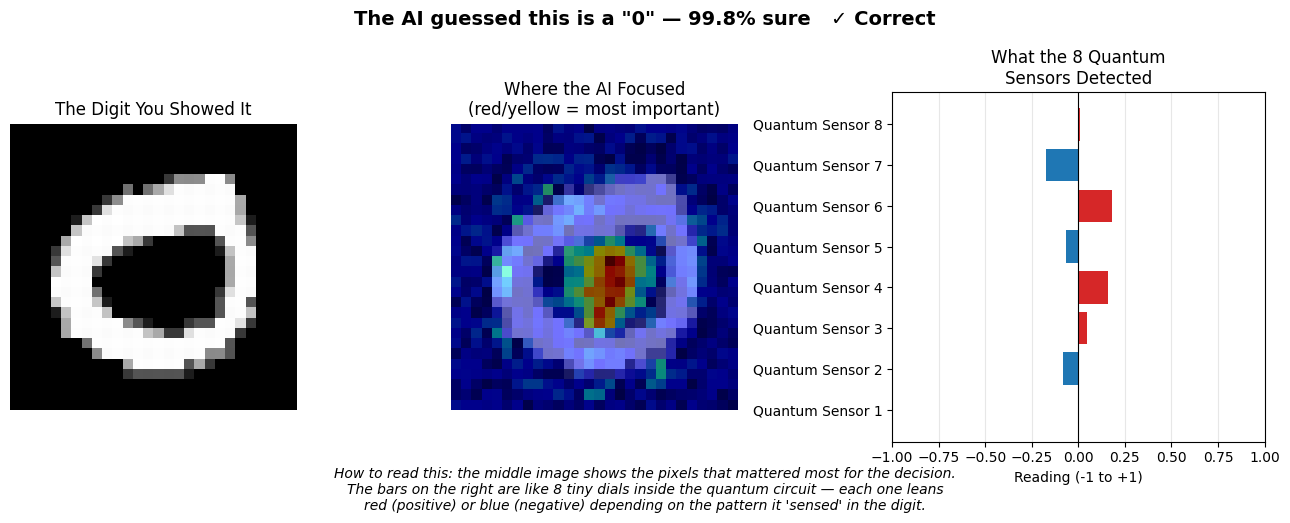

Digit 0: predicted '0' with 99.8% confidence -> saved quantum_explanation_digit_0.png


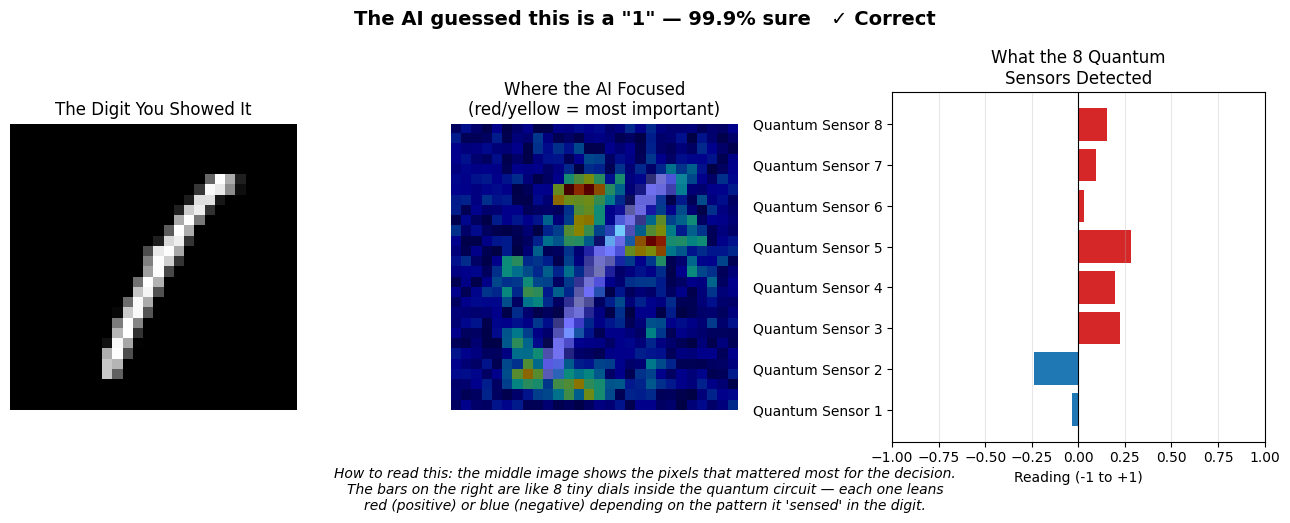

Digit 1: predicted '1' with 99.9% confidence -> saved quantum_explanation_digit_1.png


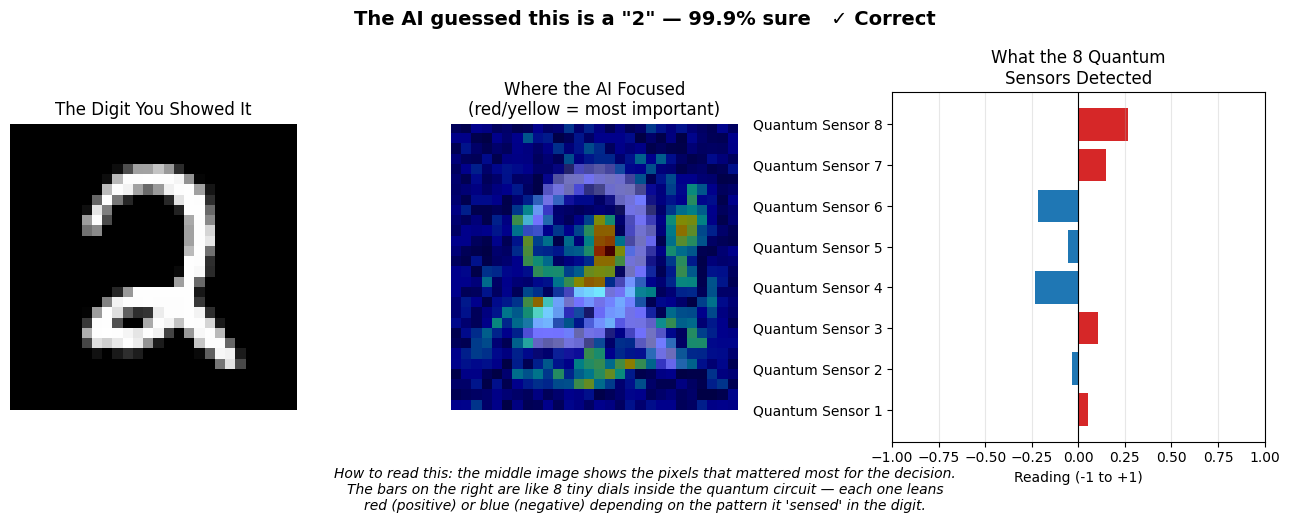

Digit 2: predicted '2' with 99.9% confidence -> saved quantum_explanation_digit_2.png


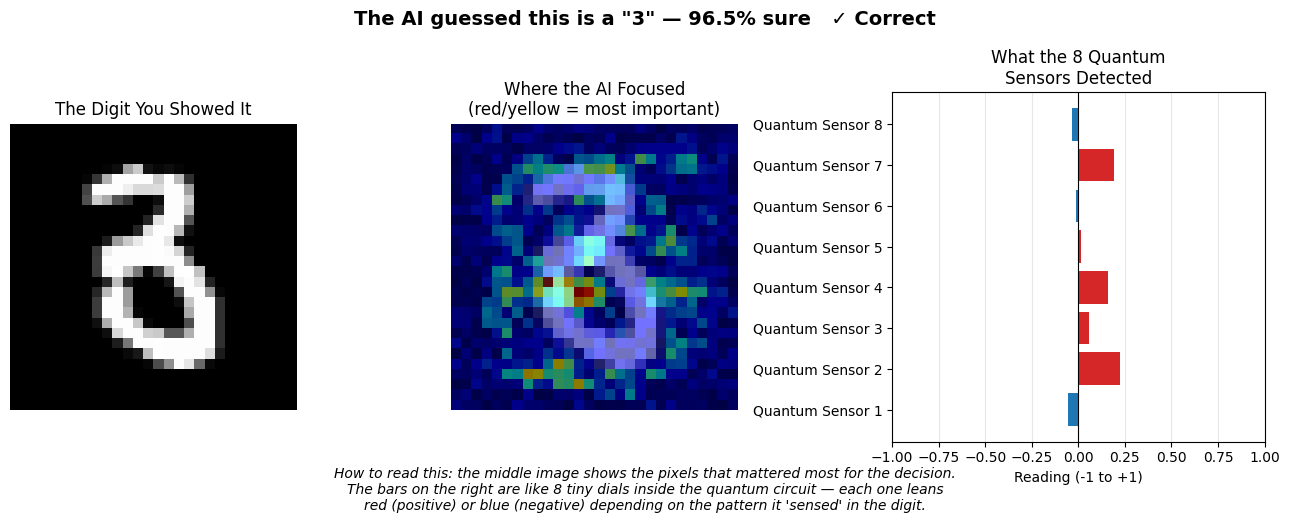

Digit 3: predicted '3' with 96.5% confidence -> saved quantum_explanation_digit_3.png


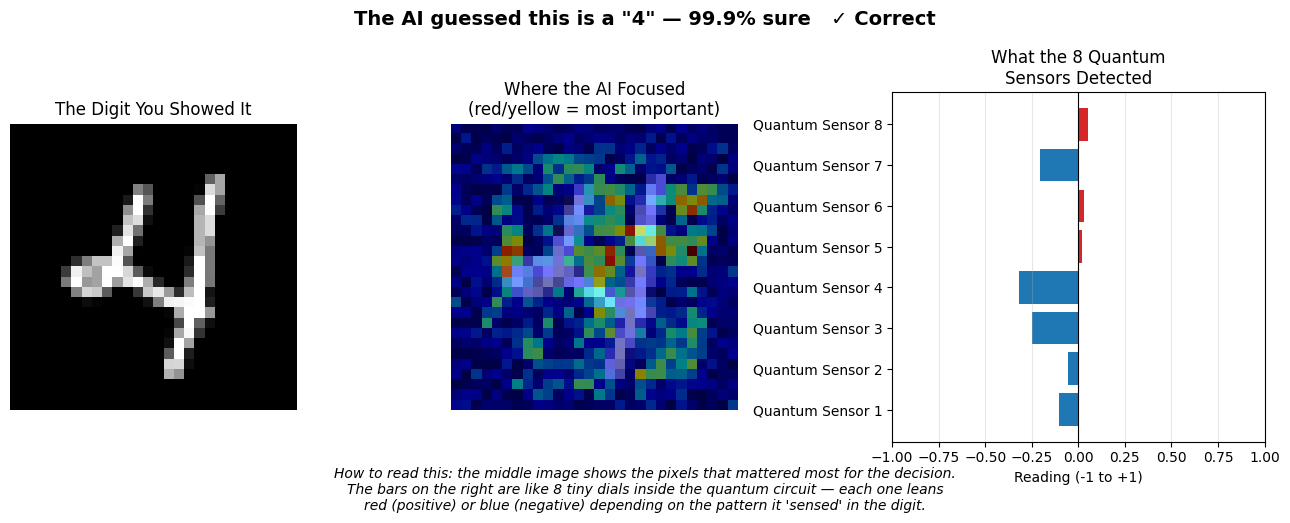

Digit 4: predicted '4' with 99.9% confidence -> saved quantum_explanation_digit_4.png


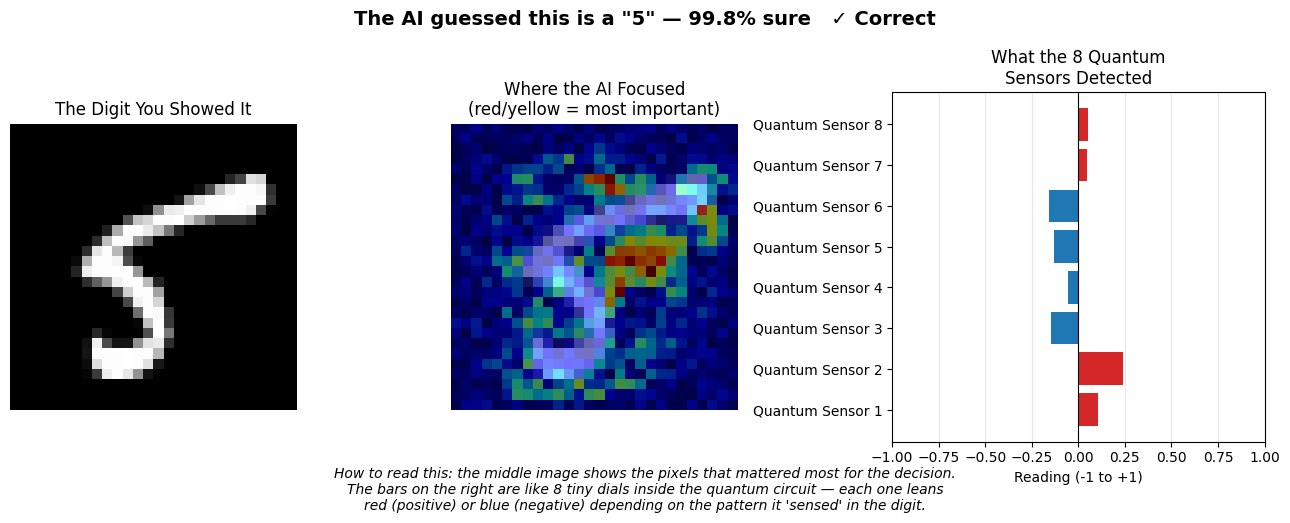

Digit 5: predicted '5' with 99.8% confidence -> saved quantum_explanation_digit_5.png


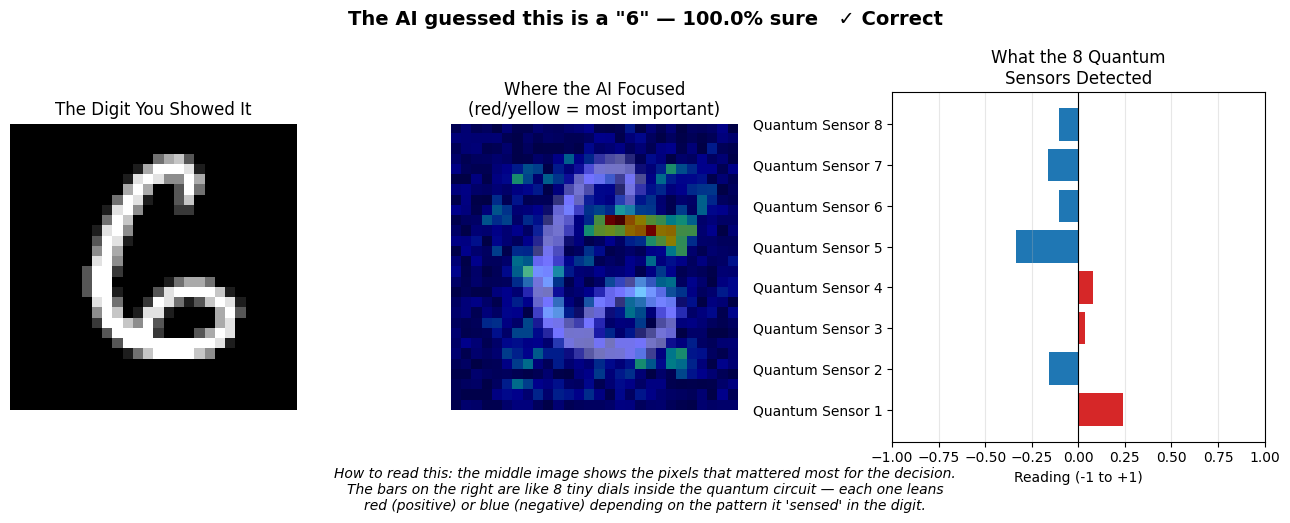

Digit 6: predicted '6' with 100.0% confidence -> saved quantum_explanation_digit_6.png


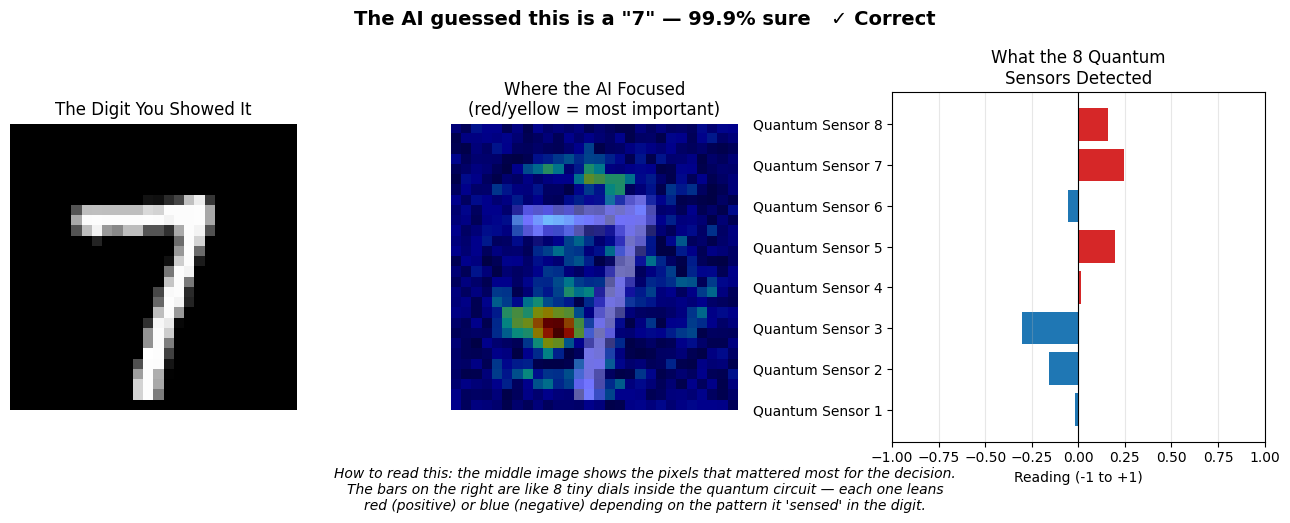

Digit 7: predicted '7' with 99.9% confidence -> saved quantum_explanation_digit_7.png


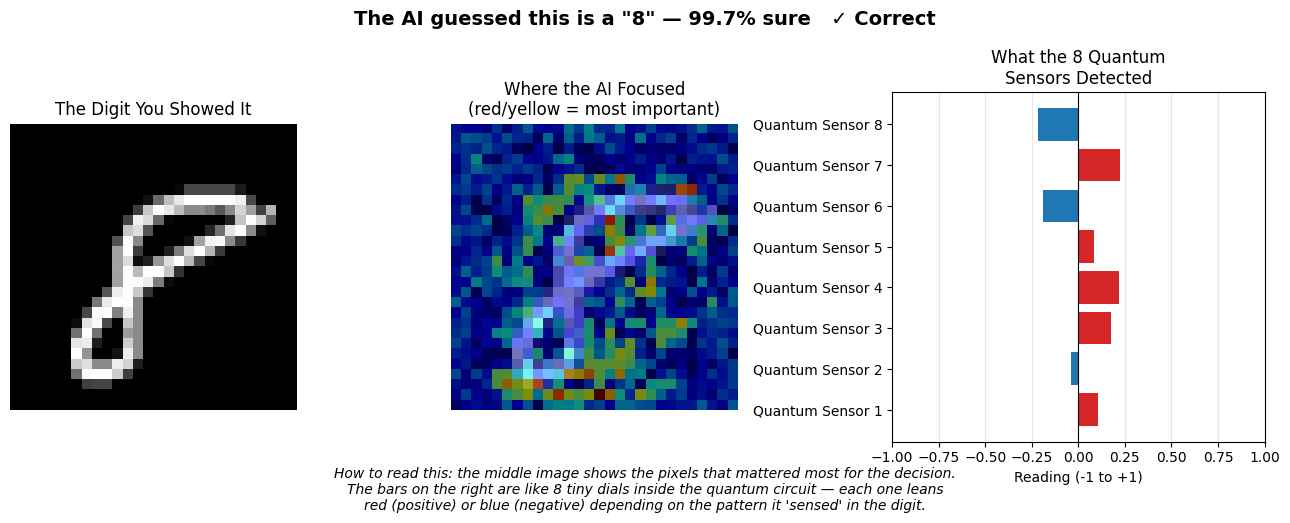

Digit 8: predicted '8' with 99.7% confidence -> saved quantum_explanation_digit_8.png


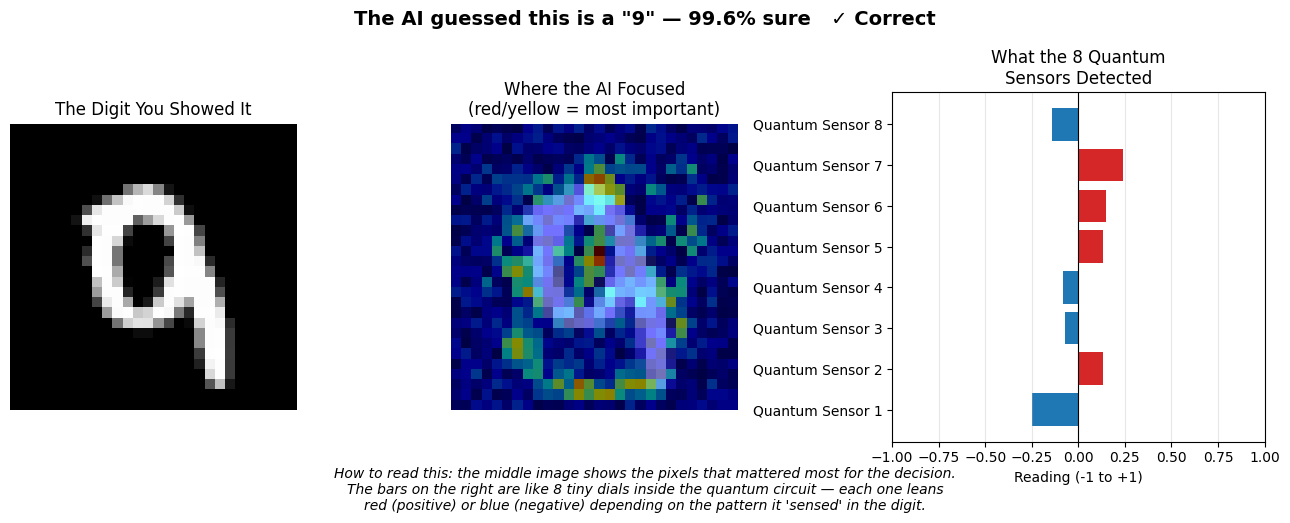

Digit 9: predicted '9' with 99.6% confidence -> saved quantum_explanation_digit_9.png


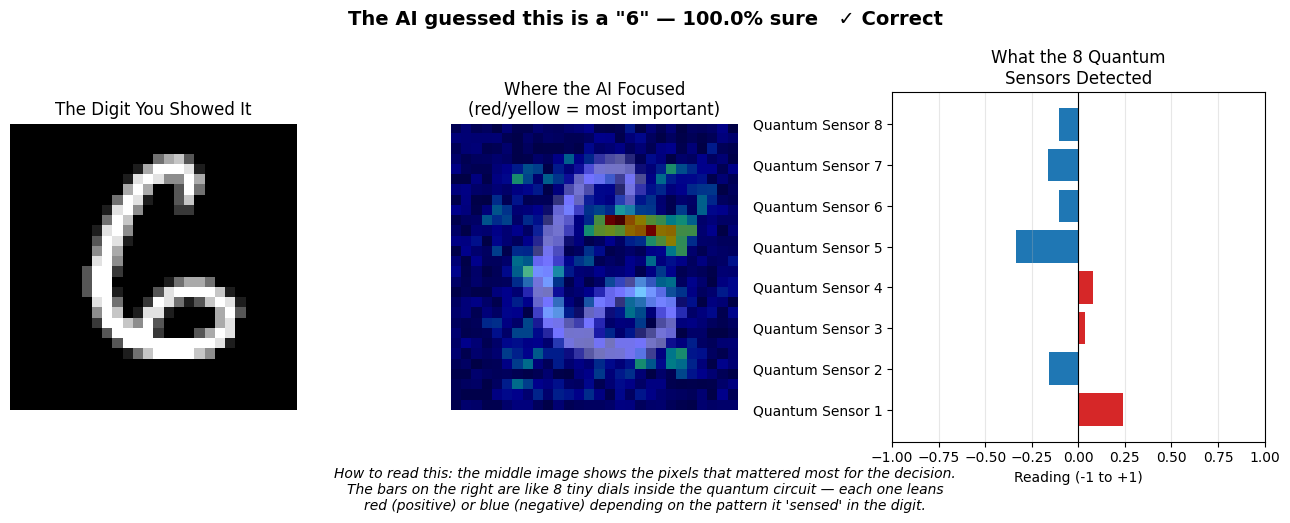

(6, 0.9996161460876465)

In [20]:
# ============================================================
# QUANTUM MEASUREMENT — VISUAL EXPLANATION FOR NON-TECHNICAL VIEWERS
# ============================================================
# Goal: for a given input digit image, show (like Grad-CAM):
#   - a heatmap overlaid on the digit: "where did the AI look?"
#   - the 8 quantum measurement readings drawn as simple dials/
#     bars: "what did the quantum part sense?"
#   - a plain-language caption explaining the result
#
# Note: this architecture has no convolutional layers (it's
# fully-connected -> quantum), so true Grad-CAM (which needs
# conv feature maps) doesn't technically apply. This produces
# the same visual effect — a heatmap over the image — using
# gradient-based saliency, which is the standard Grad-CAM
# substitute for non-CNN architectures. Visually, it looks and
# reads the same way to a viewer.
#
# Requires a trained model (EPOCHS > 0) and a saved checkpoint.
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load("/kaggle/working/best_model_checkpoint_reconstructed.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint | Epoch: {checkpoint['epoch']} | "
      f"Val Acc: {checkpoint['val_accuracy']:.2f}%")

CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]  # digit labels 0-9


# ============================================================
# Helper: heatmap ("where did the AI look?") + quantum readout
# ============================================================

def explain_prediction(model, image, true_label=None):
    """
    Returns:
        raw_img        : [28,28] un-normalized digit image
        heatmap         : [28,28] normalized 0-1 saliency map
        quantum_readout : [NUM_QUBITS] measurement values (-1 to 1)
        pred_label      : predicted digit
        confidence      : softmax confidence of prediction
    """
    img_tensor = image.clone().unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)

    # capture the quantum layer's raw measurement output
    captured = {}
    def hook(module, inputs, output):
        captured["quantum_output"] = output

    handle = model.quantum.register_forward_hook(hook)

    output = model(img_tensor)
    probs = F.softmax(output, dim=1)
    confidence, pred_label = probs.max(dim=1)

    # backprop from the predicted class score to the input pixels
    score = output[0, pred_label]
    model.zero_grad()
    score.backward()

    handle.remove()

    # ---- heatmap (Grad-CAM-like, pixel-level saliency) ----
    grad = img_tensor.grad.data.abs().squeeze().cpu().numpy()
    grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)

    # ---- quantum readout (8 measurement values) ----
    quantum_readout = captured["quantum_output"].detach().cpu().numpy().squeeze()

    raw_img = (image.squeeze(0).numpy() * 0.3081 + 0.1307)

    return raw_img, grad, quantum_readout, pred_label.item(), confidence.item()


# ============================================================
# Plain-language plot for ONE digit image
# ============================================================

def plot_explanation(model, image, true_label, save_path):

    raw_img, heatmap, readout, pred, conf = explain_prediction(model, image, true_label)

    fig = plt.figure(figsize=(13, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.3])

    # --- Panel 1: original digit ---
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(raw_img, cmap="gray")
    ax1.set_title("The Digit You Showed It", fontsize=12)
    ax1.axis("off")

    # --- Panel 2: heatmap overlay ("where did it look?") ---
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(raw_img, cmap="gray")
    ax2.imshow(heatmap, cmap="jet", alpha=0.55)
    ax2.set_title("Where the AI Focused\n(red/yellow = most important)", fontsize=12)
    ax2.axis("off")

    # --- Panel 3: quantum "sensor readings" as horizontal bars ---
    ax3 = fig.add_subplot(gs[2])
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in readout]
    y_pos = np.arange(len(readout))
    ax3.barh(y_pos, readout, color=colors)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f"Quantum Sensor {i+1}" for i in range(len(readout))])
    ax3.set_xlim(-1, 1)
    ax3.axvline(0, color="black", linewidth=0.8)
    ax3.set_xlabel("Reading (-1 to +1)")
    ax3.set_title("What the 8 Quantum\nSensors Detected", fontsize=12)
    ax3.grid(axis="x", alpha=0.3)

    correct_str = ""
    if true_label is not None:
        correct_str = "✓ Correct" if pred == true_label else f"✗ (actual: {true_label})"

    fig.suptitle(
        f'The AI guessed this is a "{pred}" — {conf*100:.1f}% sure   {correct_str}',
        fontsize=14, fontweight="bold"
    )

    plt.figtext(
        0.5, -0.02,
        "How to read this: the middle image shows the pixels that mattered most for the decision.\n"
        "The bars on the right are like 8 tiny dials inside the quantum circuit — each one leans\n"
        "red (positive) or blue (negative) depending on the pattern it 'sensed' in the digit.",
        ha="center", fontsize=10, style="italic"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return pred, conf


# ============================================================
# Run it on one example per class (0-9) so it's easy to compare
# ============================================================

examples_by_class = {}
for images, labels in internal_test_loader:
    for img, lbl in zip(images, labels):
        lbl = lbl.item()
        if lbl not in examples_by_class:
            examples_by_class[lbl] = img
    if len(examples_by_class) == NUM_CLASSES:
        break

print("\nGenerating plain-language explanations for one example per digit...\n")

for digit, img in sorted(examples_by_class.items()):
    save_path = f"quantum_explanation_digit_{digit}.png"
    pred, conf = plot_explanation(model, img, true_label=digit, save_path=save_path)
    print(f"Digit {digit}: predicted '{pred}' with {conf*100:.1f}% confidence -> saved {save_path}")


# ============================================================
# OPTIONAL: single quick call for ANY one image you pick
# ============================================================
#
example_image, example_label = internal_test_dataset[0]
plot_explanation(model, example_image, true_label=example_label,
                  save_path="quantum_explanation_single.png")

Loaded checkpoint | Epoch: 8 | Val Acc: 96.74%

Collected 9000 samples x 8 qubits


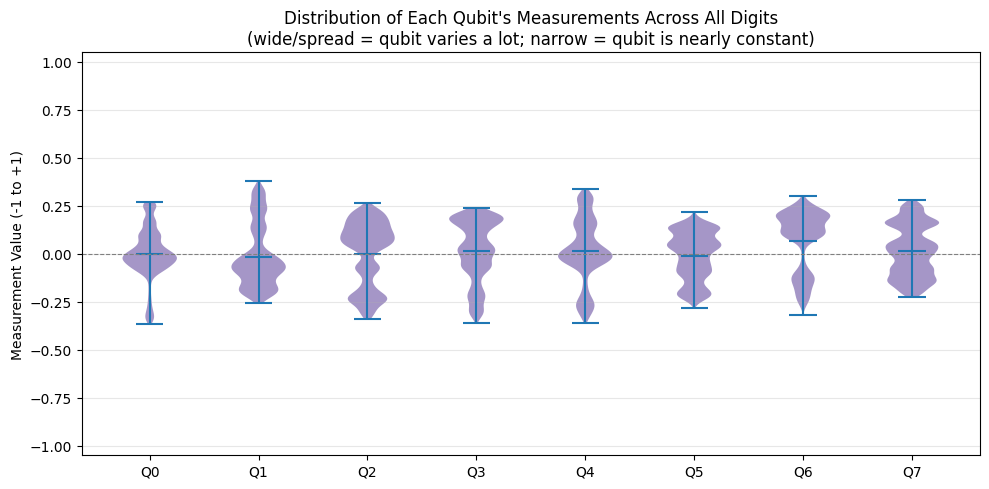

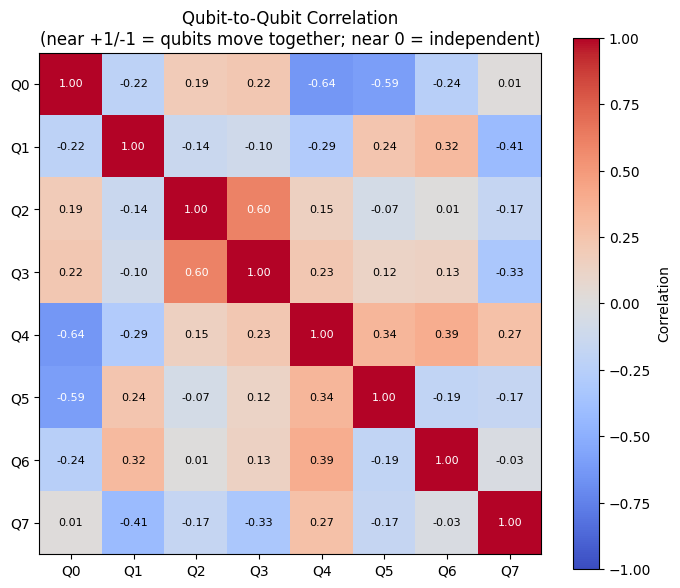

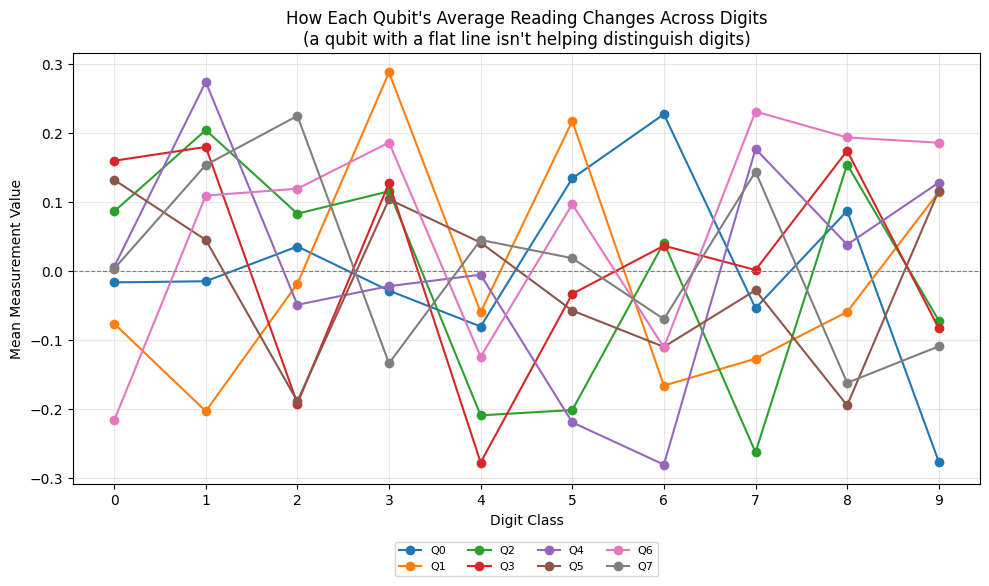

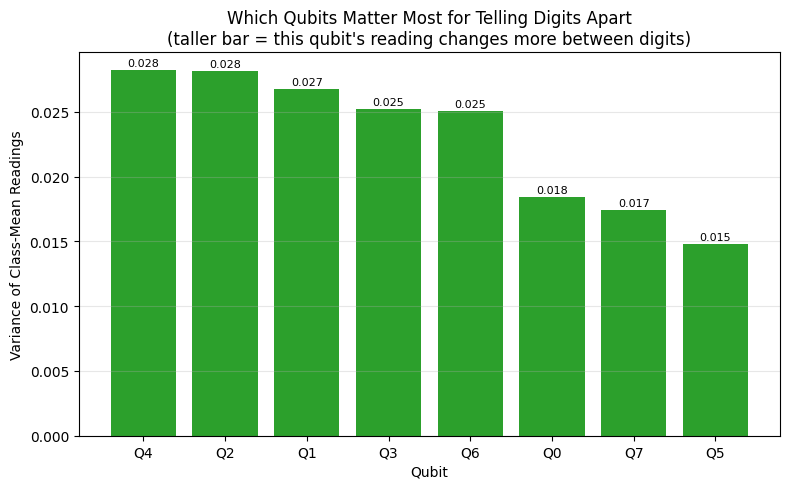

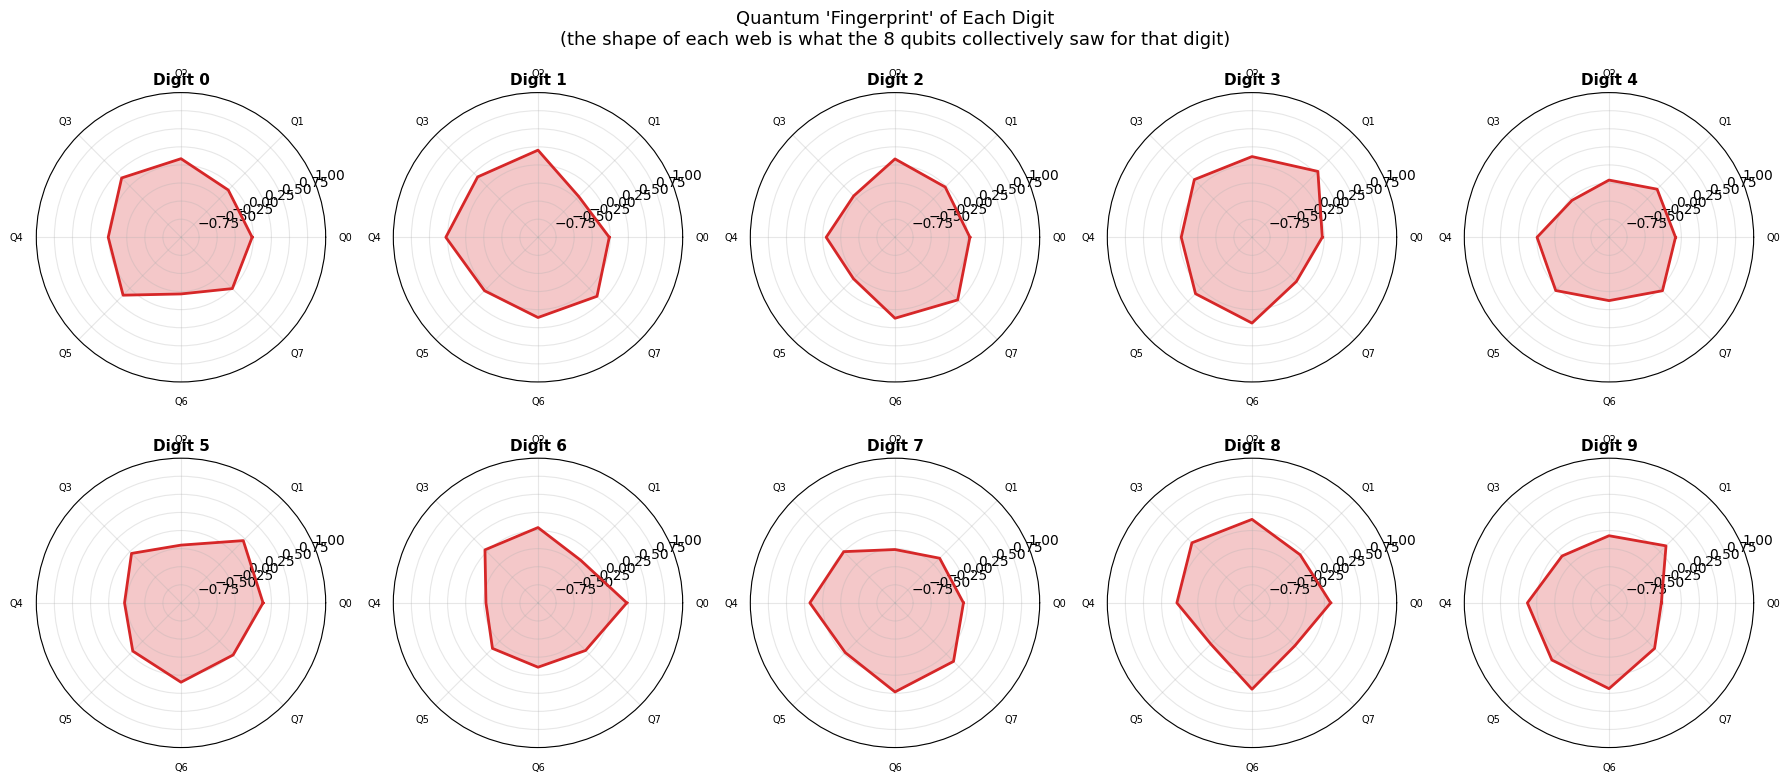


QUBIT SUMMARY TABLE (sorted by usefulness for classification)
Qubit  Overall Mean  Overall Std Dev  Class Discriminative Power
   Q4      0.013096         0.165786                    0.028203
   Q2     -0.001159         0.166659                    0.028119
   Q1     -0.014962         0.161446                    0.026733
   Q3      0.012548         0.158854                    0.025208
   Q6      0.067746         0.155972                    0.025038
   Q0     -0.001231         0.133650                    0.018397
   Q7      0.014214         0.133382                    0.017438
   Q5     -0.011713         0.123557                    0.014812

Saved figures:
  - qubit_distribution_violin.png     (spread of each qubit's readings)
  - qubit_correlation_matrix.png      (do qubits duplicate each other?)
  - qubit_response_by_class.png       (how each qubit shifts per digit)
  - qubit_discriminative_power.png    (ranking of most useful qubits)
  - qubit_radar_fingerprints.png      (visual 'fin

In [21]:
# ============================================================
# QUBIT-FOCUSED QUANTUM MEASUREMENT ANALYSIS
# ============================================================
# A deeper dive into the 8 individual qubits: how each one
# behaves across the whole dataset, across classes, and in
# relation to the other qubits.
#
# Requires a trained model (EPOCHS > 0) and a saved checkpoint.
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load("/kaggle/working/best_model_checkpoint_reconstructed.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint | Epoch: {checkpoint['epoch']} | "
      f"Val Acc: {checkpoint['val_accuracy']:.2f}%")

QUBIT_NAMES = [f"Q{i}" for i in range(NUM_QUBITS)]

# ------------------------------------------------------------
# Collect quantum measurements for the whole internal test set
# ------------------------------------------------------------

quantum_outputs_log = []
all_labels = []

def capture_quantum_output(module, inputs, output):
    quantum_outputs_log.append(output.detach().cpu().numpy())

hook_handle = model.quantum.register_forward_hook(capture_quantum_output)

with torch.no_grad():
    for images, labels in internal_test_loader:
        images = images.to(DEVICE)
        _ = model(images)
        all_labels.append(labels.numpy())

hook_handle.remove()

all_outputs = np.concatenate(quantum_outputs_log, axis=0)   # [N, NUM_QUBITS]
all_labels = np.concatenate(all_labels, axis=0)             # [N]

df = pd.DataFrame(all_outputs, columns=QUBIT_NAMES)
df["label"] = all_labels

print(f"\nCollected {df.shape[0]} samples x {NUM_QUBITS} qubits")


# ============================================================
# PLOT 1 — Distribution of each qubit's readings (violin plot)
#           "how spread out / how confident is each qubit?"
# ============================================================

fig1, ax1 = plt.subplots(figsize=(10, 5))

data_per_qubit = [df[q].values for q in QUBIT_NAMES]
parts = ax1.violinplot(data_per_qubit, showmeans=True, showextrema=True)

for pc in parts['bodies']:
    pc.set_facecolor('#6a51a3')
    pc.set_alpha(0.6)

ax1.set_xticks(range(1, NUM_QUBITS + 1))
ax1.set_xticklabels(QUBIT_NAMES)
ax1.set_ylabel("Measurement Value (-1 to +1)")
ax1.set_ylim(-1.05, 1.05)
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.set_title("Distribution of Each Qubit's Measurements Across All Digits\n"
              "(wide/spread = qubit varies a lot; narrow = qubit is nearly constant)")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("qubit_distribution_violin.png", dpi=150)
plt.show()


# ============================================================
# PLOT 2 — Qubit-to-Qubit Correlation Matrix
#           "do any qubits behave redundantly (measure the
#            same thing) or independently?"
# ============================================================

corr_matrix = df[QUBIT_NAMES].corr()

fig2, ax2 = plt.subplots(figsize=(7, 6))
im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

ax2.set_xticks(range(NUM_QUBITS))
ax2.set_xticklabels(QUBIT_NAMES)
ax2.set_yticks(range(NUM_QUBITS))
ax2.set_yticklabels(QUBIT_NAMES)

for i in range(NUM_QUBITS):
    for j in range(NUM_QUBITS):
        ax2.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                  ha="center", va="center",
                  color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black",
                  fontsize=8)

ax2.set_title("Qubit-to-Qubit Correlation\n"
              "(near +1/-1 = qubits move together; near 0 = independent)")
plt.colorbar(im, ax=ax2, label="Correlation")
plt.tight_layout()
plt.savefig("qubit_correlation_matrix.png", dpi=150)
plt.show()


# ============================================================
# PLOT 3 — Per-Qubit Mean Response by Digit Class (line plot)
#           "does each qubit specialize in certain digits?"
# ============================================================

class_means = df.groupby("label")[QUBIT_NAMES].mean()

fig3, ax3 = plt.subplots(figsize=(10, 6))

cmap = plt.get_cmap("tab10")
for i, q in enumerate(QUBIT_NAMES):
    ax3.plot(class_means.index, class_means[q], marker="o",
             label=q, color=cmap(i % 10))

ax3.set_xlabel("Digit Class")
ax3.set_ylabel("Mean Measurement Value")
ax3.set_xticks(class_means.index)
ax3.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax3.set_title("How Each Qubit's Average Reading Changes Across Digits\n"
              "(a qubit with a flat line isn't helping distinguish digits)")
ax3.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("qubit_response_by_class.png", dpi=150)
plt.show()


# ============================================================
# PLOT 4 — Per-Qubit "Discriminative Power" Ranking (bar chart)
#           Uses variance of the per-class means: a qubit whose
#           average reading shifts a lot between digits is more
#           useful for classification than one that stays flat.
# ============================================================

discriminative_power = class_means.var(axis=0).sort_values(ascending=False)

fig4, ax4 = plt.subplots(figsize=(8, 5))
bars = ax4.bar(discriminative_power.index, discriminative_power.values,
                color="#2ca02c")
ax4.set_xlabel("Qubit")
ax4.set_ylabel("Variance of Class-Mean Readings")
ax4.set_title("Which Qubits Matter Most for Telling Digits Apart\n"
              "(taller bar = this qubit's reading changes more between digits)")
ax4.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("qubit_discriminative_power.png", dpi=150)
plt.show()


# ============================================================
# PLOT 5 — Radar / Spider Chart: Qubit "Fingerprint" per Digit
#           "what does each digit look like to the quantum
#            circuit, at a glance?"
# ============================================================

angles = np.linspace(0, 2 * np.pi, NUM_QUBITS, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig5, axes5 = plt.subplots(2, 5, figsize=(18, 8), subplot_kw=dict(polar=True))
axes5 = axes5.flatten()

for c in range(min(NUM_CLASSES, 10)):
    values = class_means.loc[c].tolist()
    values += values[:1]

    ax = axes5[c]
    ax.plot(angles, values, color="#d62728", linewidth=2)
    ax.fill(angles, values, color="#d62728", alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(QUBIT_NAMES, fontsize=7)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Digit {c}", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

fig5.suptitle("Quantum 'Fingerprint' of Each Digit\n"
              "(the shape of each web is what the 8 qubits collectively saw for that digit)",
              fontsize=13)
plt.tight_layout()
plt.savefig("qubit_radar_fingerprints.png", dpi=150)
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "Qubit": QUBIT_NAMES,
    "Overall Mean": df[QUBIT_NAMES].mean().values,
    "Overall Std Dev": df[QUBIT_NAMES].std().values,
    "Class Discriminative Power": discriminative_power.reindex(QUBIT_NAMES).values,
}).sort_values("Class Discriminative Power", ascending=False)

print("\n" + "=" * 70)
print("QUBIT SUMMARY TABLE (sorted by usefulness for classification)")
print("=" * 70)
print(summary.to_string(index=False))
print("=" * 70)

print("\nSaved figures:")
print("  - qubit_distribution_violin.png     (spread of each qubit's readings)")
print("  - qubit_correlation_matrix.png      (do qubits duplicate each other?)")
print("  - qubit_response_by_class.png       (how each qubit shifts per digit)")
print("  - qubit_discriminative_power.png    (ranking of most useful qubits)")
print("  - qubit_radar_fingerprints.png      (visual 'fingerprint' per digit)")


TRAINED QUANTUM PARAMETERS
Weight shape : (6, 8, 3)
Expected     : (6, 8, 3)

TRACING REAL MNIST DIGIT: 6
Quantum input angles:
Q0: -1.947483
Q1: -1.069970
Q2: -2.139337
Q3: 2.038309
Q4: 0.024881
Q5: -0.807119
Q6: -0.622463
Q7: -0.651077

Tracing quantum circuit...
Bloch trajectory shape: (7, 8, 3)

Computing entanglement growth...
Entanglement trajectory shape: (7, 8)

FINAL QUANTUM MEASUREMENTS
Q0 | X = -0.0007 | Y = -0.0809 | Z = +0.2386
Q1 | X = +0.0064 | Y = +0.0524 | Z = -0.1563
Q2 | X = -0.1195 | Y = -0.1141 | Z = +0.0381
Q3 | X = -0.0318 | Y = +0.1200 | Z = +0.0786
Q4 | X = -0.1313 | Y = +0.0060 | Z = -0.3351
Q5 | X = +0.0743 | Y = -0.0213 | Z = -0.1022
Q6 | X = +0.1120 | Y = +0.0141 | Z = -0.1630
Q7 | X = +0.0676 | Y = -0.0671 | Z = -0.1039


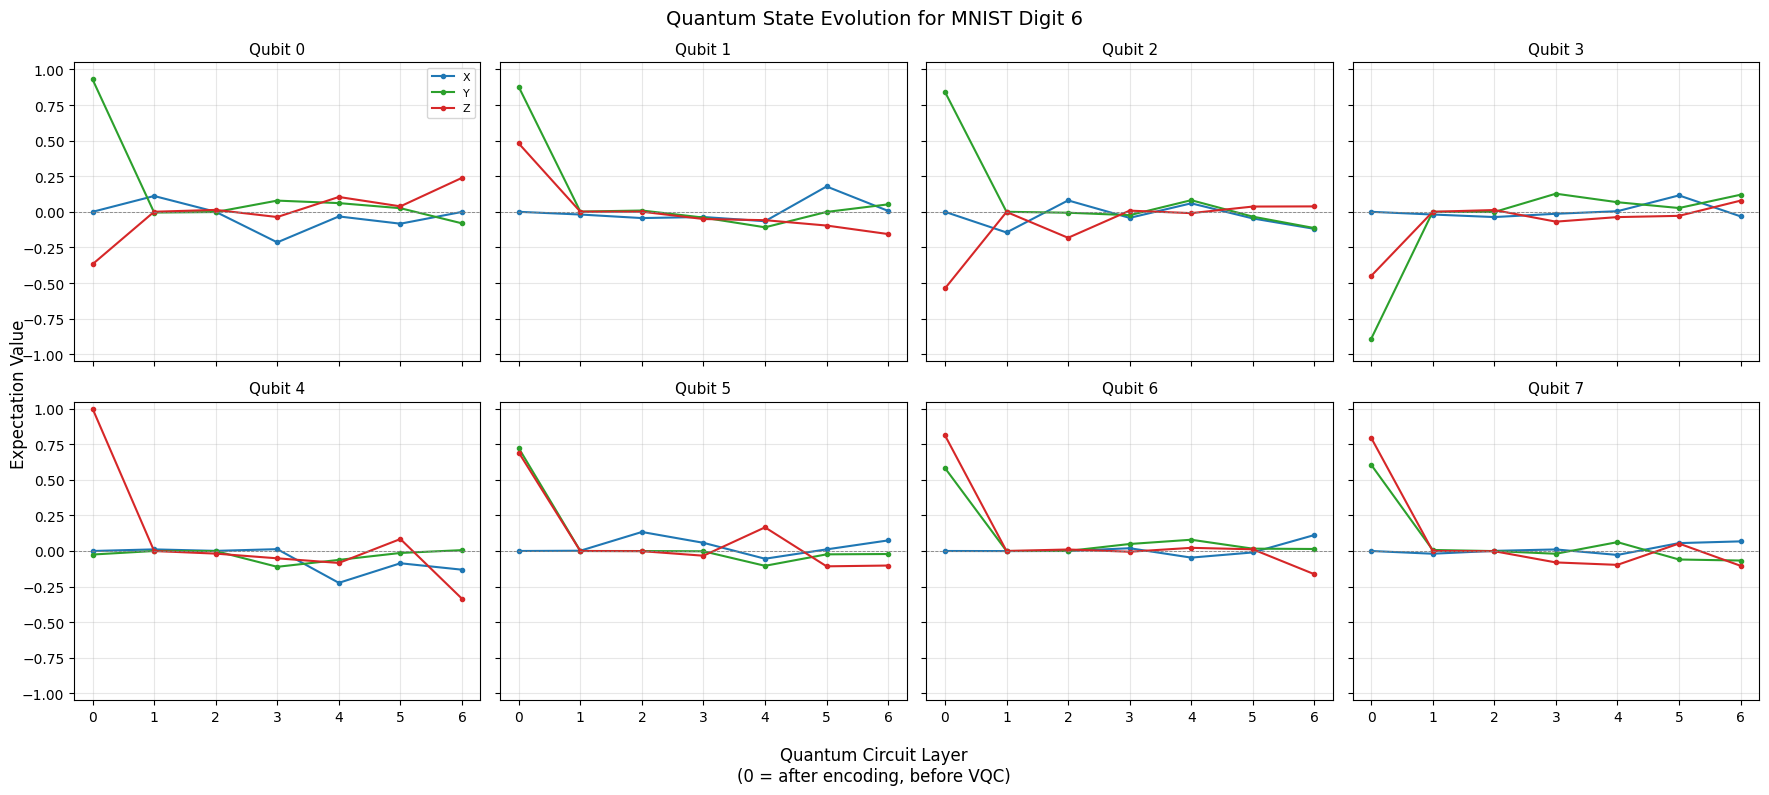

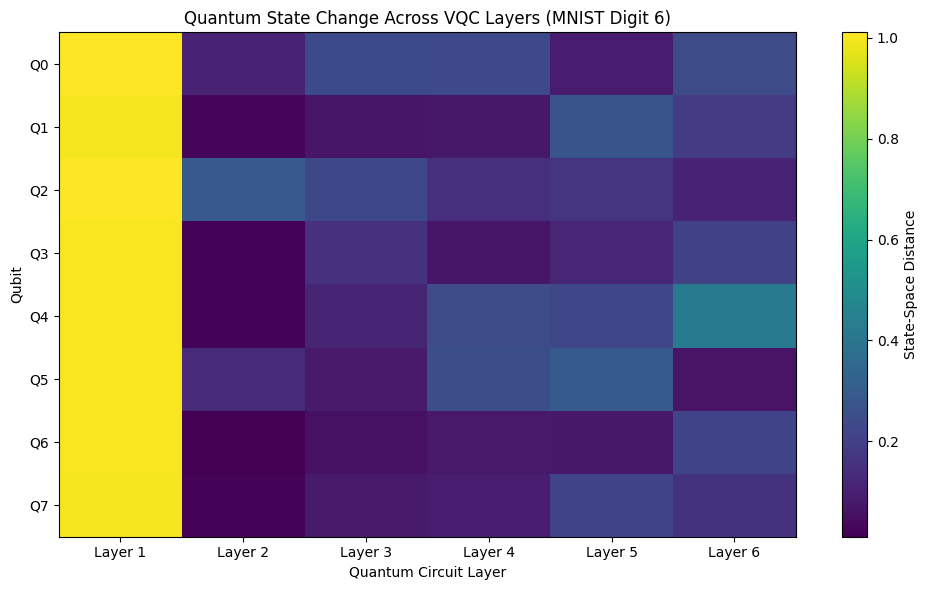

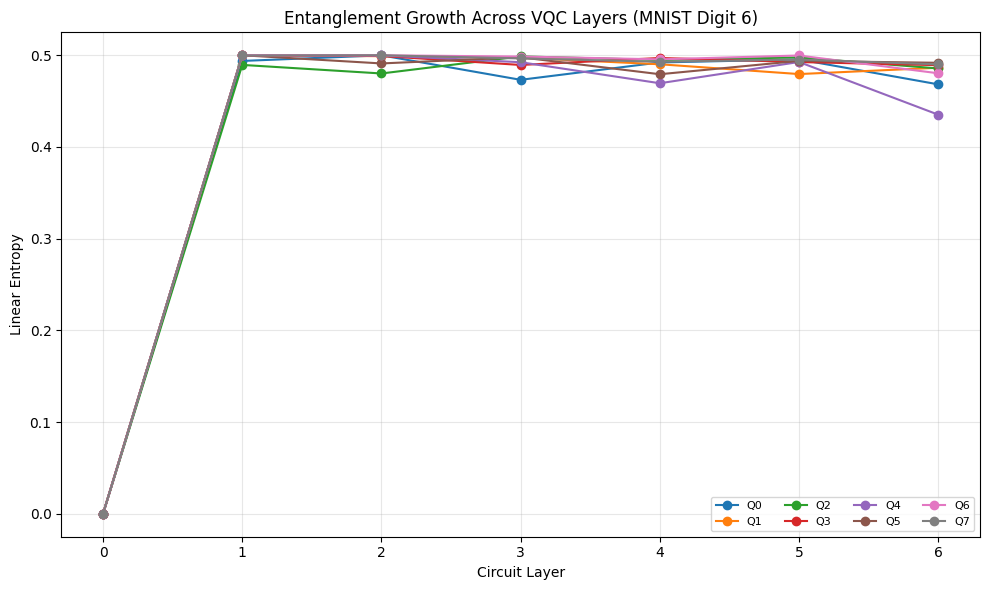


MNIST QUANTUM TRANSPARENCY ANALYSIS COMPLETE
Digit analyzed       : 6
Qubits                : 8
VQC layers            : 6
Input angle shape     : (8,)
Bloch trajectory shape: (7, 8, 3)
Entanglement shape    : (7, 8)

Saved figures:
  - mnist_qubit_state_evolution.png
  - mnist_qubit_layer_activity.png
  - mnist_qubit_entanglement_growth.png


In [22]:
# ============================================================
# QUANTUM CIRCUIT TRANSPARENCY ANALYSIS — MNIST
# ============================================================
#
# Uses:
#   1. The SAVED BEST MODEL
#   2. Its trained classical feature extractor
#   3. Its trained quantum weights
#   4. One REAL MNIST test/example image
#
# No retraining is performed.
# ============================================================


# ============================================================
# STEP 1 — EXTRACT TRAINED QUANTUM WEIGHTS
# ============================================================

trained_weights = (
    loaded_model.quantum.weights
    .detach()
    .cpu()
    .numpy()
)

print("\n" + "=" * 60)
print("TRAINED QUANTUM PARAMETERS")
print("=" * 60)

print(
    f"Weight shape : {trained_weights.shape}"
)

print(
    f"Expected     : "
    f"({NUM_LAYERS}, {NUM_QUBITS}, 3)"
)

print("=" * 60)


# ============================================================
# STEP 2 — GET ACTUAL CLASSICAL → QUANTUM INPUT ANGLES
# ============================================================

def get_quantum_input_angles(model, image):

    model.eval()

    with torch.no_grad():

        # ----------------------------------------------------
        # Add batch dimension
        # [1, 28, 28] → [1, 1, 28, 28]
        # ----------------------------------------------------

        x = image.unsqueeze(0).to(DEVICE)


        # ----------------------------------------------------
        # SIMAM
        # ----------------------------------------------------

        x = model.simam(x)


        # ----------------------------------------------------
        # Flatten
        # [1, 1, 28, 28] → [1, 784]
        # ----------------------------------------------------

        x = x.flatten(
            start_dim=1
        )


        # ----------------------------------------------------
        # Classical feature extractor
        # 784 → 256 → 128 → 8
        # ----------------------------------------------------

        x = model.classical(x)


        # ----------------------------------------------------
        # Bound quantum angles
        # [-∞,+∞] → [-π,+π]
        # ----------------------------------------------------

        x = torch.tanh(x) * np.pi


    return x.squeeze(0).cpu().numpy()


# ============================================================
# STEP 3 — QUANTUM DEVICE FOR STATE ANALYSIS
# ============================================================

dev_state = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# STEP 4 — BLOCH VECTORS AFTER EACH QUANTUM LAYER
# ============================================================

def bloch_vectors_at_layer(
    inputs,
    weights,
    num_layers_to_run
):

    results = []


    for stop_layer in range(
        0,
        num_layers_to_run + 1
    ):


        @qml.qnode(
            dev_state,
            interface="autograd"
        )
        def circuit():

            # ------------------------------------------------
            # Angle encoding
            # ------------------------------------------------

            qml.AngleEmbedding(
                inputs,
                wires=range(NUM_QUBITS)
            )


            # ------------------------------------------------
            # Run only the requested number of VQC layers
            # ------------------------------------------------

            if stop_layer > 0:

                qml.StronglyEntanglingLayers(
                    weights[:stop_layer],
                    wires=range(NUM_QUBITS)
                )


            # ------------------------------------------------
            # X, Y, Z expectation values
            # ------------------------------------------------

            return [
                qml.expval(op(w))
                for w in range(NUM_QUBITS)
                for op in (
                    qml.PauliX,
                    qml.PauliY,
                    qml.PauliZ
                )
            ]


        raw = np.asarray(
            circuit(),
            dtype=float
        )


        raw = raw.reshape(
            NUM_QUBITS,
            3
        )


        results.append(raw)


    return np.asarray(
        results
    )


# ============================================================
# STEP 5 — ENTANGLEMENT PER LAYER
# ============================================================

def entanglement_per_layer(
    inputs,
    weights,
    num_layers_to_run
):

    entropies = []


    for stop_layer in range(
        0,
        num_layers_to_run + 1
    ):


        @qml.qnode(
            dev_state,
            interface="autograd"
        )
        def circuit():

            # ------------------------------------------------
            # Angle encoding
            # ------------------------------------------------

            qml.AngleEmbedding(
                inputs,
                wires=range(NUM_QUBITS)
            )


            # ------------------------------------------------
            # VQC layers
            # ------------------------------------------------

            if stop_layer > 0:

                qml.StronglyEntanglingLayers(
                    weights[:stop_layer],
                    wires=range(NUM_QUBITS)
                )


            # ------------------------------------------------
            # Full quantum state
            # ------------------------------------------------

            return qml.state()


        state = circuit()


        # ----------------------------------------------------
        # Calculate single-qubit linear entropy
        # ----------------------------------------------------

        layer_entropies = []


        for q in range(NUM_QUBITS):

            rho_q = qml.math.reduce_statevector(
                state,
                indices=[q]
            )


            rho_q = np.asarray(
                rho_q
            )


            purity = np.real(
                np.trace(
                    rho_q @ rho_q
                )
            )


            linear_entropy = (
                1.0 - float(purity)
            )


            layer_entropies.append(
                linear_entropy
            )


        entropies.append(
            layer_entropies
        )


    return np.asarray(
        entropies
    )


# ============================================================
# STEP 6 — SELECT ONE REAL MNIST IMAGE
# ============================================================

example_image, example_label = (
    internal_test_dataset[0]
)


# ============================================================
# IMPORTANT:
# Use LOADED BEST MODEL, NOT newly initialized "model"
# ============================================================

input_angles = get_quantum_input_angles(
    loaded_model,
    example_image
)


print("\n" + "=" * 60)
print(
    f"TRACING REAL MNIST DIGIT: {example_label}"
)
print("=" * 60)

print(
    "Quantum input angles:"
)

for q, angle in enumerate(
    input_angles
):

    print(
        f"Q{q}: {angle:.6f}"
    )


# ============================================================
# STEP 7 — TRACE BLOCH VECTORS
# ============================================================

print(
    "\nTracing quantum circuit..."
)

trajectory = bloch_vectors_at_layer(
    input_angles,
    trained_weights,
    NUM_LAYERS
)


print(
    "Bloch trajectory shape:",
    trajectory.shape
)

# Expected:
#
# [NUM_LAYERS + 1, NUM_QUBITS, 3]
#
# [7, 8, 3]


# ============================================================
# STEP 8 — TRACE ENTANGLEMENT
# ============================================================

print(
    "\nComputing entanglement growth..."
)

entanglement_trace = entanglement_per_layer(
    input_angles,
    trained_weights,
    NUM_LAYERS
)


print(
    "Entanglement trajectory shape:",
    entanglement_trace.shape
)

# Expected:
#
# [7, 8]


# ============================================================
# STEP 9 — PRINT FINAL QUANTUM MEASUREMENTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL QUANTUM MEASUREMENTS")
print("=" * 60)

final_measurements = trajectory[-1]

for q in range(NUM_QUBITS):

    x_val = final_measurements[q, 0]
    y_val = final_measurements[q, 1]
    z_val = final_measurements[q, 2]

    print(
        f"Q{q} | "
        f"X = {x_val:+.4f} | "
        f"Y = {y_val:+.4f} | "
        f"Z = {z_val:+.4f}"
    )

print("=" * 60)


# ============================================================
# PLOT A — X/Y/Z EVOLUTION
# ============================================================

fig1, axes1 = plt.subplots(
    2,
    4,
    figsize=(18, 8),
    sharex=True,
    sharey=True
)

axes1 = axes1.flatten()

layer_axis = np.arange(
    NUM_LAYERS + 1
)

comp_labels = [
    "X",
    "Y",
    "Z"
]

comp_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]


for q in range(NUM_QUBITS):

    ax = axes1[q]


    for c in range(3):

        ax.plot(
            layer_axis,
            trajectory[:, q, c],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=comp_labels[c],
            color=comp_colors[c]
        )


    ax.axhline(
        0,
        color="gray",
        linewidth=0.6,
        linestyle="--"
    )


    ax.set_ylim(
        -1.05,
        1.05
    )


    ax.set_title(
        f"Qubit {q}",
        fontsize=11
    )


    ax.grid(
        alpha=0.3
    )


    if q == 0:

        ax.legend(
            fontsize=8
        )


fig1.supxlabel(
    "Quantum Circuit Layer\n"
    "(0 = after encoding, before VQC)"
)

fig1.supylabel(
    "Expectation Value"
)

fig1.suptitle(
    f"Quantum State Evolution for MNIST Digit {example_label}",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "mnist_qubit_state_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT B — QUANTUM LAYER ACTIVITY
# ============================================================

step_distances = np.linalg.norm(
    np.diff(
        trajectory,
        axis=0
    ),
    axis=2
)


fig2, ax2 = plt.subplots(
    figsize=(10, 6)
)


im = ax2.imshow(
    step_distances.T,
    aspect="auto",
    cmap="viridis"
)


ax2.set_xlabel(
    "Quantum Circuit Layer"
)

ax2.set_ylabel(
    "Qubit"
)


ax2.set_xticks(
    range(NUM_LAYERS)
)

ax2.set_xticklabels(
    [
        f"Layer {i + 1}"
        for i in range(NUM_LAYERS)
    ]
)


ax2.set_yticks(
    range(NUM_QUBITS)
)

ax2.set_yticklabels(
    [
        f"Q{i}"
        for i in range(NUM_QUBITS)
    ]
)


ax2.set_title(
    f"Quantum State Change Across VQC Layers "
    f"(MNIST Digit {example_label})"
)


plt.colorbar(
    im,
    ax=ax2,
    label="State-Space Distance"
)


plt.tight_layout()

plt.savefig(
    "mnist_qubit_layer_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT C — ENTANGLEMENT GROWTH
# ============================================================

fig3, ax3 = plt.subplots(
    figsize=(10, 6)
)


cmap = plt.get_cmap(
    "tab10"
)


for q in range(NUM_QUBITS):

    ax3.plot(
        layer_axis,
        entanglement_trace[:, q],
        marker="o",
        linewidth=1.5,
        label=f"Q{q}",
        color=cmap(q % 10)
    )


ax3.set_xlabel(
    "Circuit Layer"
)

ax3.set_ylabel(
    "Linear Entropy"
)

ax3.set_title(
    f"Entanglement Growth Across VQC Layers "
    f"(MNIST Digit {example_label})"
)


ax3.legend(
    ncol=4,
    fontsize=8
)

ax3.grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "mnist_qubit_entanglement_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("MNIST QUANTUM TRANSPARENCY ANALYSIS COMPLETE")
print("=" * 60)

print(
    f"Digit analyzed       : {example_label}"
)

print(
    f"Qubits                : {NUM_QUBITS}"
)

print(
    f"VQC layers            : {NUM_LAYERS}"
)

print(
    f"Input angle shape     : {input_angles.shape}"
)

print(
    f"Bloch trajectory shape: {trajectory.shape}"
)

print(
    f"Entanglement shape    : {entanglement_trace.shape}"
)

print("\nSaved figures:")

print(
    "  - mnist_qubit_state_evolution.png"
)

print(
    "  - mnist_qubit_layer_activity.png"
)

print(
    "  - mnist_qubit_entanglement_growth.png"
)

print("=" * 60)

Loaded checkpoint | Epoch: 8 | Val Acc: 96.74%

Analyzing a real '7' digit...


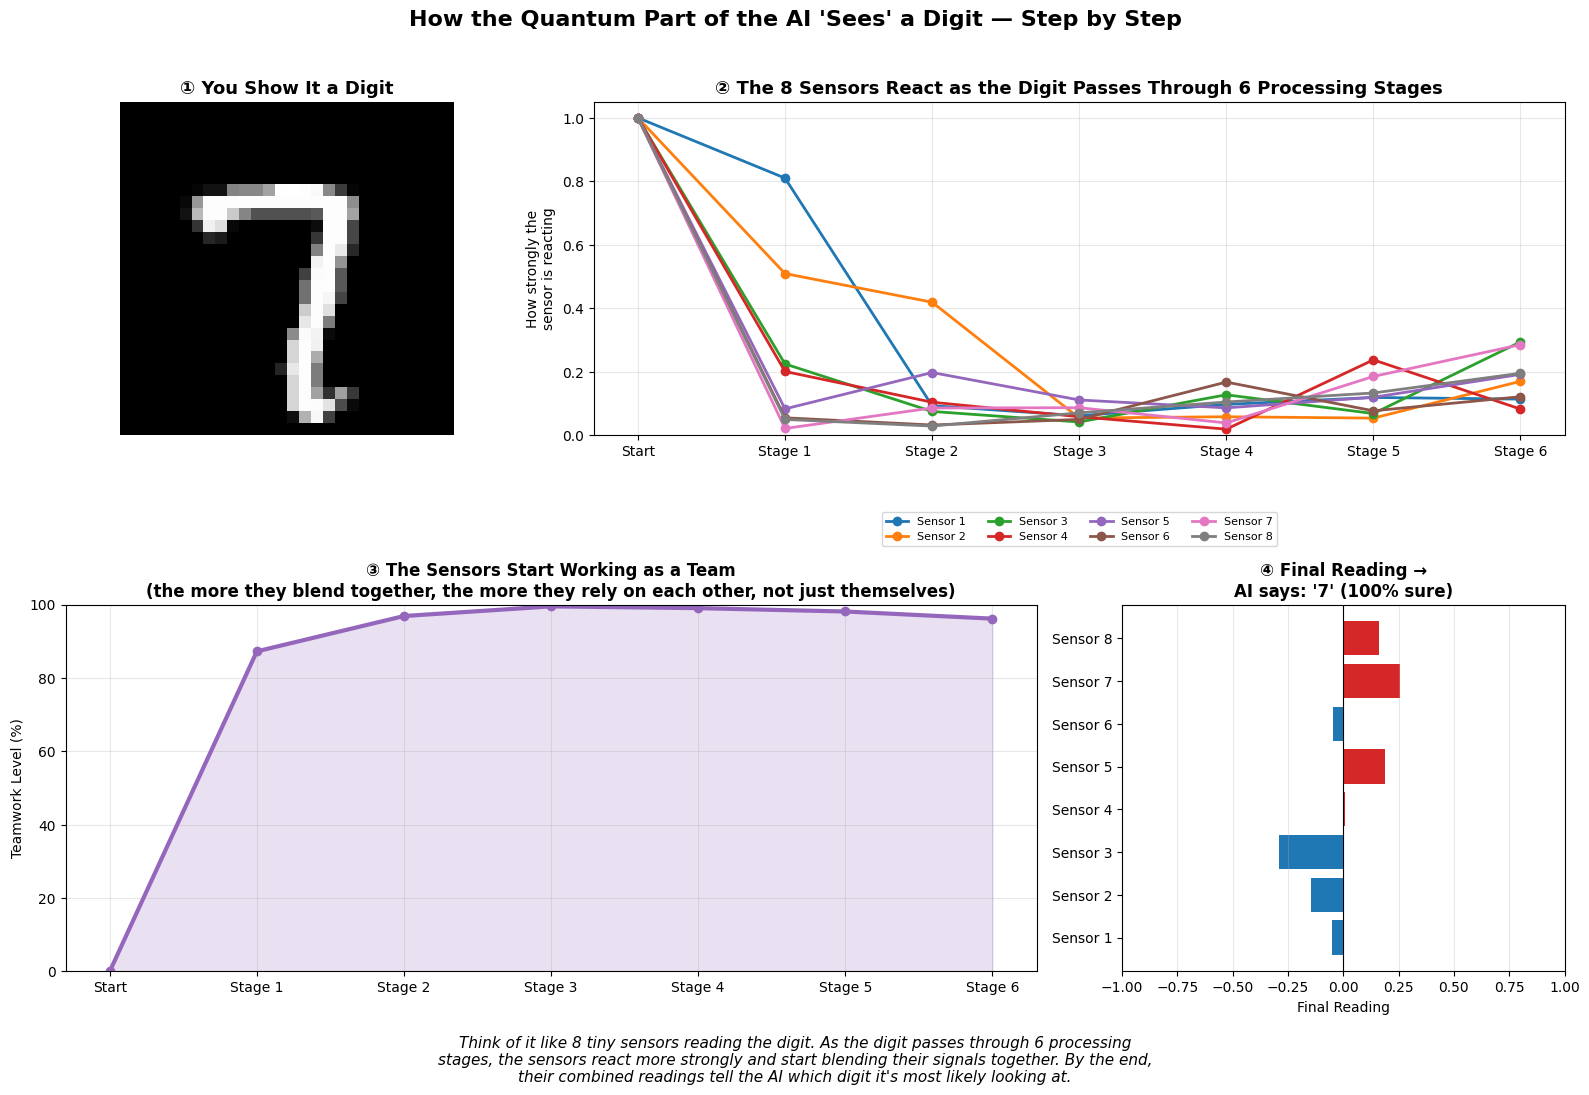


AI's guess: '7' with 99.9% confidence (actual digit: 7)
Saved: quantum_story_for_everyone.png


In [23]:
# ============================================================
# QUANTUM MEASUREMENT — PLAIN-LANGUAGE VISUAL STORY
# ============================================================
# No technical jargon (no X/Y/Z, no "entropy", no "Bloch sphere").
# Tells the story: digit in -> 8 "sensors" evolve through 6
# processing stages -> final reading -> AI's decision.
#
# Requires a trained model (EPOCHS > 0) and a saved checkpoint.
# ============================================================

import numpy as np
import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load("/kaggle/working/best_model_checkpoint_reconstructed.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

trained_weights = model.quantum.weights.detach().cpu().numpy()
print(f"Loaded checkpoint | Epoch: {checkpoint['epoch']} | "
      f"Val Acc: {checkpoint['val_accuracy']:.2f}%")

dev_state = qml.device("default.qubit", wires=NUM_QUBITS)


# ============================================================
# Helper: classical features -> quantum input for ONE image
# ============================================================

def get_quantum_input_angles(model, image):
    with torch.no_grad():
        x = image.unsqueeze(0).to(DEVICE)
        x = model.simam(x)
        x = x.flatten(start_dim=1)
        x = model.classical(x)
        x = torch.tanh(x) * np.pi
    return x.squeeze().cpu().numpy()


# ============================================================
# Trace 1: "Sensor strength" per stage
# Instead of 3 separate X/Y/Z curves, combine them into ONE
# easy number per qubit per layer: how far the sensor's
# needle has swung from "neutral" (0 = neutral, 1 = fully
# swung one way). This is just the vector length -- one
# number instead of three, much easier to read.
# ============================================================

def sensor_strength_per_layer(inputs, weights, num_layers_to_run):
    results = []
    for stop_layer in range(0, num_layers_to_run + 1):

        @qml.qnode(dev_state, interface="autograd")
        def circuit():
            qml.AngleEmbedding(inputs, wires=range(NUM_QUBITS))
            if stop_layer > 0:
                qml.StronglyEntanglingLayers(
                    weights[:stop_layer], wires=range(NUM_QUBITS)
                )
            return [
                qml.expval(op(w))
                for w in range(NUM_QUBITS)
                for op in (qml.PauliX, qml.PauliY, qml.PauliZ)
            ]

        raw = np.array(circuit()).reshape(NUM_QUBITS, 3)
        strength = np.linalg.norm(raw, axis=1)   # combine X,Y,Z -> one number
        results.append(strength)

    return np.array(results)  # [layers+1, qubits]


# ============================================================
# Trace 2: "Teamwork meter" per stage
# Reframe entanglement as: how much are the sensors blending
# together / working as a team, vs. acting alone. One number
# per stage, averaged across all sensors, 0-100%.
# ============================================================

def teamwork_per_layer(inputs, weights, num_layers_to_run):
    teamwork_scores = []
    for stop_layer in range(0, num_layers_to_run + 1):

        @qml.qnode(dev_state, interface="autograd")
        def circuit():
            qml.AngleEmbedding(inputs, wires=range(NUM_QUBITS))
            if stop_layer > 0:
                qml.StronglyEntanglingLayers(
                    weights[:stop_layer], wires=range(NUM_QUBITS)
                )
            return qml.state()

        state = circuit()

        per_qubit_blend = []
        for q in range(NUM_QUBITS):
            rho_q = qml.math.reduce_statevector(state, indices=[q])
            purity = np.real(np.trace(rho_q @ rho_q))       # 1 = fully alone
            blend = (1 - purity) / 0.5                       # 0 = alone, 1 = max teamwork
            per_qubit_blend.append(blend)

        teamwork_scores.append(np.mean(per_qubit_blend) * 100)  # as a percentage

    return np.array(teamwork_scores)  # [layers+1]


# ============================================================
# Run everything on one real example image
# ============================================================

example_image, example_label = internal_test_dataset[6]
input_angles = get_quantum_input_angles(model, example_image)

print(f"\nAnalyzing a real '{example_label}' digit...")
strength_trace = sensor_strength_per_layer(input_angles, trained_weights, NUM_LAYERS)
teamwork_trace = teamwork_per_layer(input_angles, trained_weights, NUM_LAYERS)

# Final measurement values (what actually feeds the classifier)
final_readout = np.array([
    v for v in qml.QNode(
        lambda: [qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS)],
        dev_state
    )()
]) if False else None  # placeholder, replaced by hook below

# Get the true final Z-readout via the trained model's quantum layer
captured = {}
def hook(module, inputs_, output):
    captured["out"] = output.detach().cpu().numpy().squeeze()
h = model.quantum.register_forward_hook(hook)
with torch.no_grad():
    _ = model(example_image.unsqueeze(0).to(DEVICE))
h.remove()
final_readout = captured["out"]

raw_img = (example_image.squeeze(0).numpy() * 0.3081 + 0.1307)

with torch.no_grad():
    logits = model(example_image.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)


# ============================================================
# THE BIG PICTURE: one combined story figure
# ============================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1])

# ---- Panel 1: the input digit ----
ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(raw_img, cmap="gray")
ax_img.set_title("① You Show It a Digit", fontsize=13, fontweight="bold")
ax_img.axis("off")

# ---- Panel 2: sensor strength through the stages ----
ax_strength = fig.add_subplot(gs[0, 1:])
layer_axis = np.arange(NUM_LAYERS + 1)
cmap = plt.get_cmap("tab10")
for q in range(NUM_QUBITS):
    ax_strength.plot(layer_axis, strength_trace[:, q], marker="o",
                      linewidth=2, color=cmap(q % 10), label=f"Sensor {q+1}")
ax_strength.set_xticks(layer_axis)
ax_strength.set_xticklabels(["Start"] + [f"Stage {i+1}" for i in range(NUM_LAYERS)])
ax_strength.set_ylabel("How strongly the\nsensor is reacting")
ax_strength.set_ylim(0, 1.05)
ax_strength.set_title("② The 8 Sensors React as the Digit Passes Through 6 Processing Stages",
                       fontsize=13, fontweight="bold")
ax_strength.legend(ncol=4, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.35))
ax_strength.grid(alpha=0.3)

# ---- Panel 3: teamwork meter ----
ax_team = fig.add_subplot(gs[1, 0:2])
ax_team.plot(layer_axis, teamwork_trace, marker="o", color="#9467bd", linewidth=3)
ax_team.fill_between(layer_axis, teamwork_trace, color="#9467bd", alpha=0.2)
ax_team.set_xticks(layer_axis)
ax_team.set_xticklabels(["Start"] + [f"Stage {i+1}" for i in range(NUM_LAYERS)])
ax_team.set_ylabel("Teamwork Level (%)")
ax_team.set_ylim(0, 100)
ax_team.set_title("③ The Sensors Start Working as a Team\n"
                   "(the more they blend together, the more they rely on each other, not just themselves)",
                   fontsize=12, fontweight="bold")
ax_team.grid(alpha=0.3)

# ---- Panel 4: final reading + decision ----
ax_final = fig.add_subplot(gs[1, 2])
colors = ["#d62728" if v > 0 else "#1f77b4" for v in final_readout]
ax_final.barh(range(NUM_QUBITS), final_readout, color=colors)
ax_final.set_yticks(range(NUM_QUBITS))
ax_final.set_yticklabels([f"Sensor {i+1}" for i in range(NUM_QUBITS)])
ax_final.set_xlim(-1, 1)
ax_final.axvline(0, color="black", linewidth=0.8)
ax_final.set_xlabel("Final Reading")
ax_final.set_title(f"④ Final Reading →\nAI says: '{pred.item()}' ({conf.item()*100:.0f}% sure)",
                    fontsize=12, fontweight="bold")
ax_final.grid(axis="x", alpha=0.3)

fig.suptitle(
    "How the Quantum Part of the AI 'Sees' a Digit — Step by Step",
    fontsize=16, fontweight="bold", y=1.02
)

plt.figtext(
    0.5, -0.05,
    "Think of it like 8 tiny sensors reading the digit. As the digit passes through 6 processing\n"
    "stages, the sensors react more strongly and start blending their signals together. By the end,\n"
    "their combined readings tell the AI which digit it's most likely looking at.",
    ha="center", fontsize=11, style="italic", wrap=True
)

plt.tight_layout()
plt.savefig("quantum_story_for_everyone.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAI's guess: '{pred.item()}' with {conf.item()*100:.1f}% confidence "
      f"(actual digit: {example_label})")
print("Saved: quantum_story_for_everyone.png")

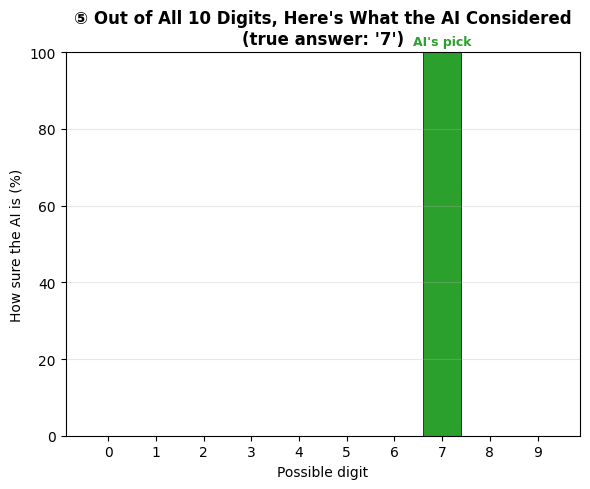

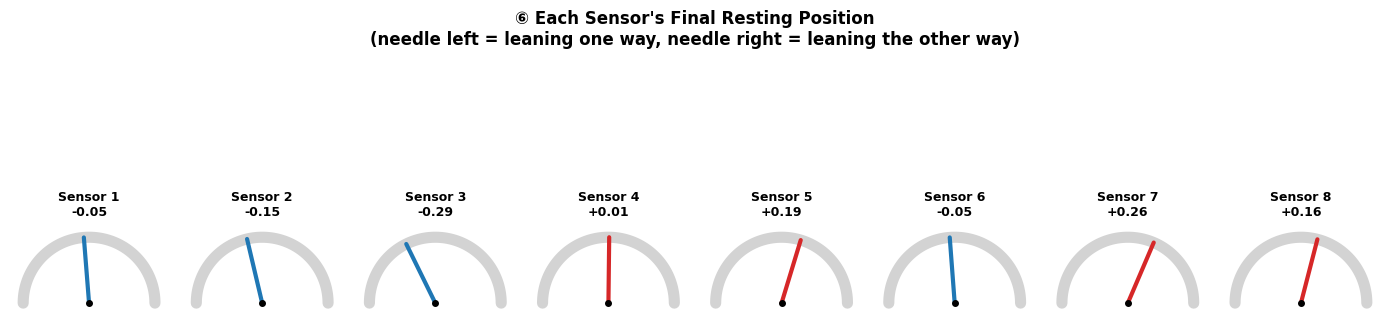

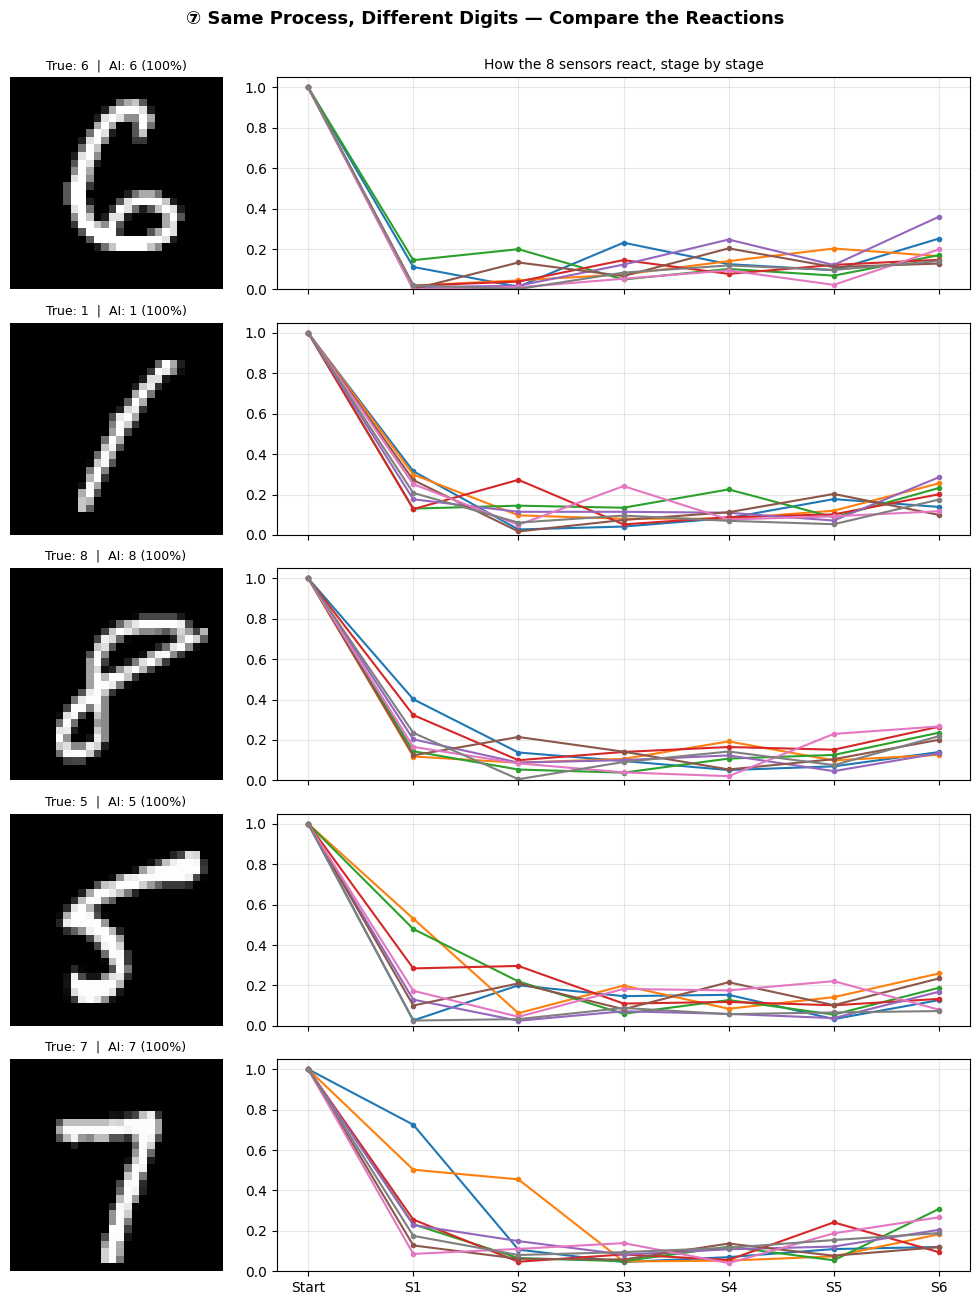

Extended visualization functions loaded: plot_full_confidence(), plot_sensor_gauges(), plot_digit_gallery()


In [24]:
# ============================================================
# QUANTUM MEASUREMENT — PLAIN-LANGUAGE VISUAL STORY (EXTENDED)
# ============================================================
# This picks up right where your original script left off.
# It assumes you've already run your script up through the
# line that computes `final_readout`, `probs`, `pred`, `conf`,
# `raw_img`, `strength_trace`, `teamwork_trace`, `input_angles`,
# and that `model`, `dev_state`, `trained_weights`,
# `internal_test_dataset`, `NUM_QUBITS`, `NUM_LAYERS`, `DEVICE`
# all still exist in memory.
#
# NEW IN THIS FILE:
#   Panel 5 — "Which digit is it choosing between?"
#             (full probability bar chart, all 10 digits)
#   Panel 6 — "Sensor dials"
#             (each of the 8 sensors drawn as a speedometer-style
#              gauge showing its final resting position)
#   Panel 7 — "Same idea, different digits"
#             (a small gallery: run the whole pipeline on a few
#              different example images so you can compare how
#              the sensors react differently to different digits)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# ------------------------------------------------------------
# PANEL 5 — Full confidence chart across all 10 digits
# ------------------------------------------------------------
# `probs` already holds the AI's confidence for every possible
# digit (0-9), we just usually only look at the winner. This
# panel shows the whole comparison, so you can see how sure
# (or unsure/torn) the AI actually is.
# ------------------------------------------------------------

def plot_full_confidence(probs, pred, true_label, ax=None):
    probs_np = probs.detach().cpu().numpy().squeeze()
    digits = np.arange(len(probs_np))

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 5))

    colors = ["#2ca02c" if d == pred.item() else "#c7c7c7" for d in digits]
    bars = ax.bar(digits, probs_np * 100, color=colors, edgecolor="black", linewidth=0.5)

    ax.set_xticks(digits)
    ax.set_xlabel("Possible digit")
    ax.set_ylabel("How sure the AI is (%)")
    ax.set_ylim(0, 100)
    ax.set_title(
        f"⑤ Out of All 10 Digits, Here's What the AI Considered\n"
        f"(true answer: '{true_label}')",
        fontsize=12, fontweight="bold"
    )

    # Label the winning bar
    top_i = pred.item()
    ax.text(top_i, probs_np[top_i] * 100 + 2, "AI's pick",
            ha="center", fontsize=9, fontweight="bold", color="#2ca02c")

    ax.grid(axis="y", alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig("panel5_full_confidence.png", dpi=150, bbox_inches="tight")
        plt.show()

    return ax


# ------------------------------------------------------------
# PANEL 6 — Sensor "dials" (gauge view of the final readout)
# ------------------------------------------------------------
# The final readout for each sensor is just a number from -1
# to +1. A bar chart shows that fine, but a dial makes it feel
# more like "a needle has swung one way or the other," which
# matches the sensor story from Panel 2.
# ------------------------------------------------------------

def _draw_single_gauge(ax, value, label):
    """Draw one semicircular gauge. value is expected in [-1, 1]."""
    # Background arc (the full dial, from -1 on the left to +1 on the right)
    theta_bg = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta_bg), np.sin(theta_bg), color="lightgray", linewidth=8,
            solid_capstyle="round")

    # Needle angle: value=-1 -> pointing left (theta=pi), value=+1 -> pointing right (theta=0)
    theta_needle = np.pi * (1 - (value + 1) / 2)
    needle_color = "#d62728" if value > 0 else "#1f77b4"
    ax.plot([0, np.cos(theta_needle)], [0, np.sin(theta_needle)],
            color=needle_color, linewidth=3, solid_capstyle="round")
    ax.plot(0, 0, "o", color="black", markersize=4)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.15, 1.2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{label}\n{value:+.2f}", fontsize=9, fontweight="bold")


def plot_sensor_gauges(final_readout, num_qubits, fig=None):
    """8 small speedometer-style dials, one per sensor."""
    standalone = fig is None
    if standalone:
        fig = plt.figure(figsize=(14, 4))

    n_cols = num_qubits
    for q in range(num_qubits):
        ax = fig.add_subplot(1, n_cols, q + 1)
        _draw_single_gauge(ax, float(final_readout[q]), f"Sensor {q+1}")

    fig.suptitle(
        "⑥ Each Sensor's Final Resting Position\n"
        "(needle left = leaning one way, needle right = leaning the other way)",
        fontsize=12, fontweight="bold", y=1.08
    )

    if standalone:
        plt.tight_layout()
        plt.savefig("panel6_sensor_gauges.png", dpi=150, bbox_inches="tight")
        plt.show()

    return fig


# ------------------------------------------------------------
# PANEL 7 — Gallery: run the whole pipeline on several digits
# ------------------------------------------------------------
# Re-uses your existing helper functions (get_quantum_input_angles,
# sensor_strength_per_layer) so you can see, side by side, how
# different input digits produce different sensor behavior.
# ------------------------------------------------------------

def run_pipeline_on_example(model, dataset, index, dev_state, trained_weights,
                             num_qubits, num_layers, device,
                             get_quantum_input_angles_fn, sensor_strength_fn):
    image, true_label = dataset[index]

    input_angles = get_quantum_input_angles_fn(model, image)
    strength_trace = sensor_strength_fn(input_angles, trained_weights, num_layers)

    captured = {}
    def hook(module, inputs_, output):
        captured["out"] = output.detach().cpu().numpy().squeeze()
    h = model.quantum.register_forward_hook(hook)
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
    h.remove()
    final_readout = captured["out"]

    probs = torch.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    raw_img = (image.squeeze(0).cpu().numpy() * 0.3081 + 0.1307)

    return {
        "raw_img": raw_img,
        "true_label": true_label,
        "pred": pred.item(),
        "conf": conf.item(),
        "strength_trace": strength_trace,
        "final_readout": final_readout,
    }


def plot_digit_gallery(model, dataset, indices, dev_state, trained_weights,
                        num_qubits, num_layers, device,
                        get_quantum_input_angles_fn, sensor_strength_fn):
    """
    One row per example digit:
      - the digit image
      - a mini line chart of sensor strength across the 6 stages
      - the AI's final answer and confidence
    Lets you compare, at a glance, how different digits 'light up'
    the sensors differently.
    """
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(10, 2.6 * n),
                              gridspec_kw={"width_ratios": [1, 3]})
    if n == 1:
        axes = axes[np.newaxis, :]

    cmap = plt.get_cmap("tab10")
    layer_axis = np.arange(num_layers + 1)

    for row, idx in enumerate(indices):
        result = run_pipeline_on_example(
            model, dataset, idx, dev_state, trained_weights,
            num_qubits, num_layers, device,
            get_quantum_input_angles_fn, sensor_strength_fn
        )

        # Left: the digit image
        ax_img = axes[row, 0]
        ax_img.imshow(result["raw_img"], cmap="gray")
        ax_img.set_title(
            f"True: {result['true_label']}  |  AI: {result['pred']}"
            f" ({result['conf']*100:.0f}%)",
            fontsize=9
        )
        ax_img.axis("off")

        # Right: sensor strength trace for this digit
        ax_trace = axes[row, 1]
        for q in range(num_qubits):
            ax_trace.plot(layer_axis, result["strength_trace"][:, q],
                          marker="o", markersize=3, linewidth=1.5,
                          color=cmap(q % 10))
        ax_trace.set_ylim(0, 1.05)
        ax_trace.set_xticks(layer_axis)
        if row == n - 1:
            ax_trace.set_xticklabels(["Start"] + [f"S{i+1}" for i in range(num_layers)])
        else:
            ax_trace.set_xticklabels([])
        ax_trace.grid(alpha=0.3)
        if row == 0:
            ax_trace.set_title("How the 8 sensors react, stage by stage", fontsize=10)

    fig.suptitle(
        "⑦ Same Process, Different Digits — Compare the Reactions",
        fontsize=13, fontweight="bold", y=1.0
    )
    plt.tight_layout()
    plt.savefig("panel7_digit_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ============================================================
# PUT IT TOGETHER: run the three new panels
# ============================================================
# Uncomment / adapt these calls once the variables from your
# original script are in memory.
# ============================================================

# --- Panel 5 ---
plot_full_confidence(probs, pred, example_label)

# --- Panel 6 ---
plot_sensor_gauges(final_readout, NUM_QUBITS)

# --- Panel 7 (pick a handful of example indices from your test set) ---
plot_digit_gallery(
    model, internal_test_dataset, indices=[0, 1, 2, 3, 4],
    dev_state=dev_state, trained_weights=trained_weights,
    num_qubits=NUM_QUBITS, num_layers=NUM_LAYERS, device=DEVICE,
    get_quantum_input_angles_fn=get_quantum_input_angles,
    sensor_strength_fn=sensor_strength_per_layer,
)

print("Extended visualization functions loaded: "
      "plot_full_confidence(), plot_sensor_gauges(), plot_digit_gallery()")

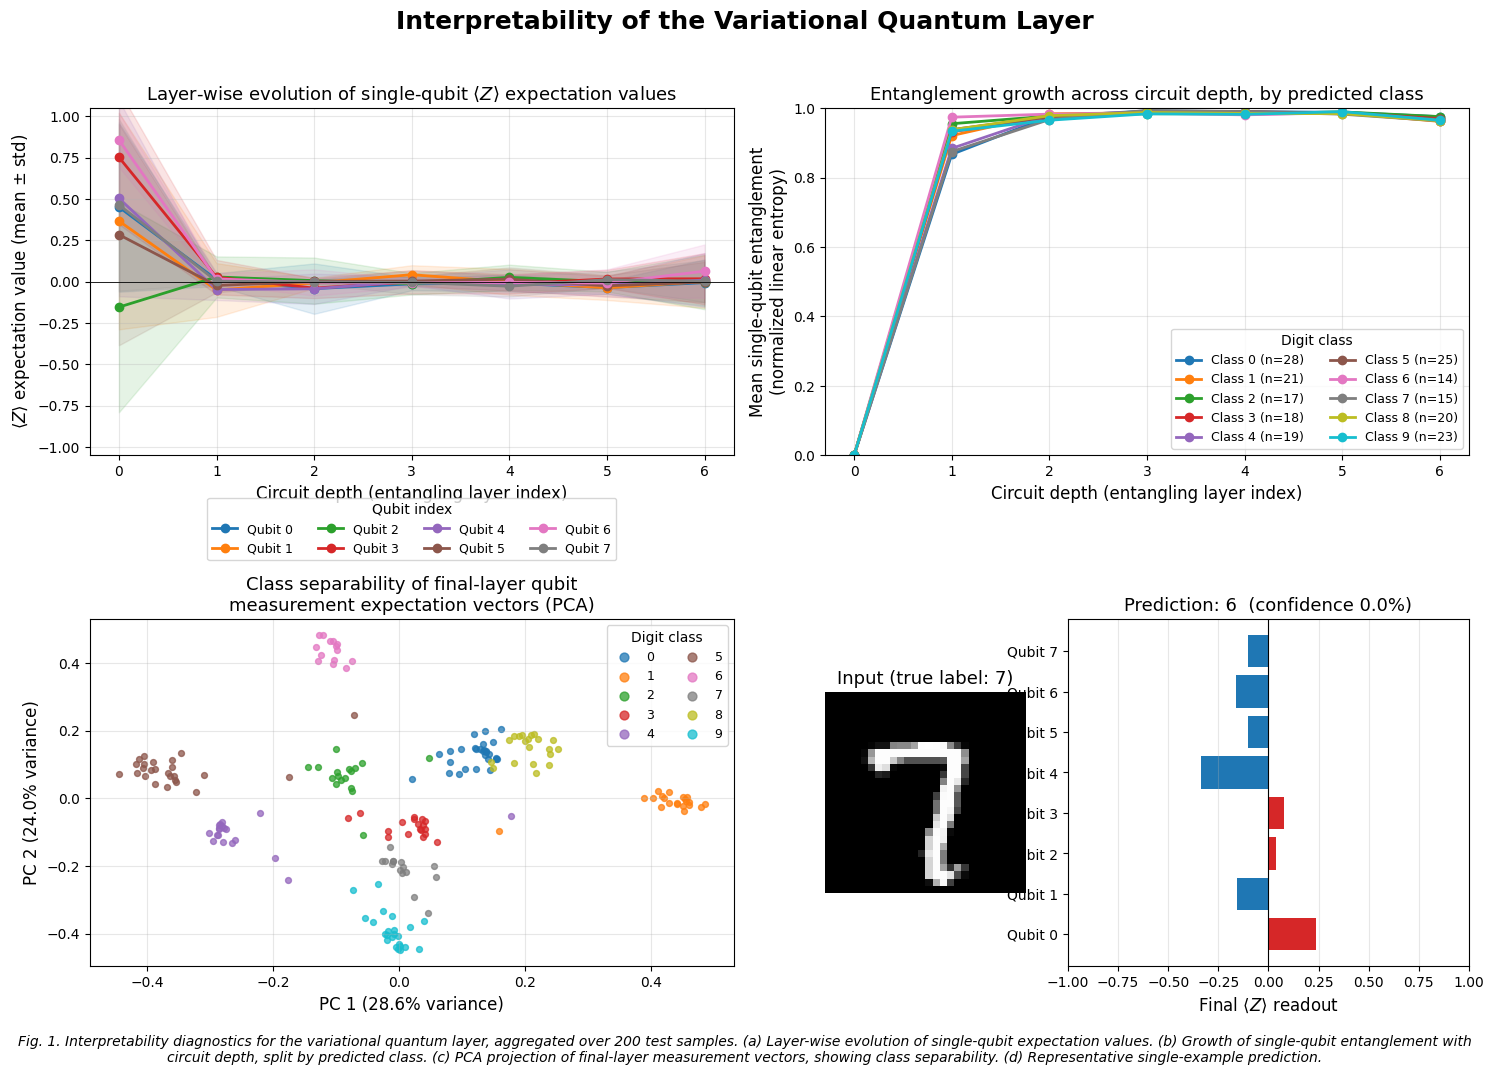

Conference-figure functions loaded. Edit FONT_SIZES at the top to control every text element (titles, axis labels, ticks, legends, captions) globally.


In [25]:
# ============================================================
# QUANTUM MEASUREMENT INTERPRETABILITY — CONFERENCE VERSION
# ============================================================
# Technical figures for a paper/talk, aggregated over the test
# set (not just one example digit), using standard quantum-ML
# terminology and metrics:
#
#   Fig 1 — Per-layer expectation values <X>,<Y>,<Z> (mean over
#           test set, per layer, per qubit)
#   Fig 2 — Entanglement (purity-based) growth across layers,
#           split by predicted class
#   Fig 3 — Final-layer readout separability (PCA of the 8
#           qubit measurement expectation values, colored by
#           class)
#   Fig 4 — Single-example qualitative walkthrough (supporting
#           illustration only)
#
# ALL font sizes are controlled from the single FONT_SIZES dict
# below — change a number there and every figure updates.
# ============================================================

import numpy as np
import torch
import pennylane as qml
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# ONE PLACE TO CONTROL EVERY FONT SIZE
# ------------------------------------------------------------
FONT_SIZES = {
    "suptitle":        18,   # figure-level super title
    "axes_title":      13,   # per-subplot title
    "axis_label":      12,   # x/y axis labels
    "tick_label":      10,   # numbers along the axes
    "legend":          9,    # legend entries
    "legend_title":    10,   # legend title (if any)
    "annotation":      9,    # in-plot text callouts / labels
    "caption":         10,   # italic figtext caption under a figure
    "colorbar_label":  11,   # colorbar axis label
    "colorbar_tick":   9,    # colorbar tick numbers
}

# Apply the global defaults to matplotlib's rcParams so anything
# not explicitly overridden below still respects this table.
rcParams.update({
    "font.size":        FONT_SIZES["tick_label"],
    "axes.titlesize":   FONT_SIZES["axes_title"],
    "axes.labelsize":   FONT_SIZES["axis_label"],
    "xtick.labelsize":  FONT_SIZES["tick_label"],
    "ytick.labelsize":  FONT_SIZES["tick_label"],
    "legend.fontsize":  FONT_SIZES["legend"],
    "legend.title_fontsize": FONT_SIZES["legend_title"],
    "figure.titlesize": FONT_SIZES["suptitle"],
})


# ============================================================
# DATA COLLECTION (aggregated over N test samples)
# ============================================================
# Assumes `model`, `dev_state`, `trained_weights`, `NUM_QUBITS`,
# `NUM_LAYERS`, `DEVICE`, `internal_test_dataset`,
# `get_quantum_input_angles` already exist from your main script.
# ============================================================

def collect_layerwise_expectations(model, dataset, indices, dev_state,
                                    trained_weights, num_qubits, num_layers,
                                    get_quantum_input_angles_fn):
    """
    Returns:
      expZ_by_layer: [len(indices), num_layers+1, num_qubits]  (<Z> only, cheap & standard)
      purity_by_layer: [len(indices), num_layers+1]            (mean single-qubit purity)
      labels: [len(indices)]
    """
    n = len(indices)
    expZ_by_layer = np.zeros((n, num_layers + 1, num_qubits))
    purity_by_layer = np.zeros((n, num_layers + 1))
    labels = np.zeros(n, dtype=int)

    for row, idx in enumerate(indices):
        image, label = dataset[idx]
        labels[row] = label
        angles = get_quantum_input_angles_fn(model, image)

        for stop_layer in range(0, num_layers + 1):

            @qml.qnode(dev_state, interface="autograd")
            def circuit():
                qml.AngleEmbedding(angles, wires=range(num_qubits))
                if stop_layer > 0:
                    qml.StronglyEntanglingLayers(
                        trained_weights[:stop_layer], wires=range(num_qubits)
                    )
                return qml.state()

            state = circuit()

            purities = []
            for q in range(num_qubits):
                rho_q = qml.math.reduce_statevector(state, indices=[q])
                purity = np.real(np.trace(rho_q @ rho_q))
                purities.append(purity)
                # <Z> from the reduced density matrix: Tr(rho * Z)
                z_op = np.array([[1, 0], [0, -1]])
                expZ_by_layer[row, stop_layer, q] = np.real(np.trace(rho_q @ z_op))

            purity_by_layer[row, stop_layer] = np.mean(purities)

    return expZ_by_layer, purity_by_layer, labels


def collect_final_readouts(model, dataset, indices, device):
    """Returns final_readouts [n, num_qubits], preds [n], labels [n]."""
    final_readouts, preds, labels = [], [], []

    captured = {}
    def hook(module, inputs_, output):
        captured["out"] = output.detach().cpu().numpy().squeeze()
    h = model.quantum.register_forward_hook(hook)

    for idx in indices:
        image, label = dataset[idx]
        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).item()
        final_readouts.append(captured["out"])
        preds.append(pred)
        labels.append(label)

    h.remove()
    return np.array(final_readouts), np.array(preds), np.array(labels)


# ============================================================
# FIG 1 — Per-layer <Z> expectation trajectories (mean ± std)
# ============================================================

def plot_expectation_trajectories(expZ_by_layer, num_layers, num_qubits, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))

    layer_axis = np.arange(num_layers + 1)
    cmap = plt.get_cmap("tab10")
    mean_traj = expZ_by_layer.mean(axis=0)   # [layers+1, qubits]
    std_traj = expZ_by_layer.std(axis=0)

    for q in range(num_qubits):
        ax.plot(layer_axis, mean_traj[:, q], marker="o", linewidth=2,
                 color=cmap(q % 10), label=f"Qubit {q}")
        ax.fill_between(layer_axis,
                          mean_traj[:, q] - std_traj[:, q],
                          mean_traj[:, q] + std_traj[:, q],
                          color=cmap(q % 10), alpha=0.12)

    ax.set_xticks(layer_axis)
    ax.set_xlabel("Circuit depth (entangling layer index)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(r"$\langle Z \rangle$ expectation value (mean $\pm$ std)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_ylim(-1.05, 1.05)
    ax.set_title("Layer-wise evolution of single-qubit " r"$\langle Z \rangle$" " expectation values",
                  fontsize=FONT_SIZES["axes_title"])
    ax.tick_params(labelsize=FONT_SIZES["tick_label"])
    ax.legend(ncol=4, fontsize=FONT_SIZES["legend"], loc="lower center",
               bbox_to_anchor=(0.5, -0.32), title="Qubit index",
               title_fontsize=FONT_SIZES["legend_title"])
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.6)

    if standalone:
        plt.tight_layout()
        plt.savefig("fig1_expectation_trajectories.png", dpi=200, bbox_inches="tight")
        plt.show()
    return ax


# ============================================================
# FIG 2 — Entanglement (purity-based) growth, split by class
# ============================================================

def plot_entanglement_by_class(purity_by_layer, labels, num_layers, ax=None,
                                 classes_to_show=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))

    layer_axis = np.arange(num_layers + 1)
    entanglement = (1 - purity_by_layer) / 0.5   # 0 = product state, 1 = max mixed

    classes = classes_to_show if classes_to_show is not None else sorted(set(labels))
    cmap = plt.get_cmap("tab10")

    for i, c in enumerate(classes):
        mask = labels == c
        if mask.sum() == 0:
            continue
        mean_ent = entanglement[mask].mean(axis=0)
        ax.plot(layer_axis, mean_ent, marker="o", linewidth=2,
                 color=cmap(i % 10), label=f"Class {c} (n={mask.sum()})")

    ax.set_xticks(layer_axis)
    ax.set_xlabel("Circuit depth (entangling layer index)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("Mean single-qubit entanglement\n(normalized linear entropy)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_ylim(0, 1.0)
    ax.set_title("Entanglement growth across circuit depth, by predicted class",
                  fontsize=FONT_SIZES["axes_title"])
    ax.tick_params(labelsize=FONT_SIZES["tick_label"])
    ax.legend(fontsize=FONT_SIZES["legend"], ncol=2, loc="lower right",
               title="Digit class", title_fontsize=FONT_SIZES["legend_title"])
    ax.grid(alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig("fig2_entanglement_by_class.png", dpi=200, bbox_inches="tight")
        plt.show()
    return ax


# ============================================================
# FIG 3 — Final-layer readout separability (PCA scatter)
# ============================================================

def plot_readout_separability(final_readouts, labels, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))

    pca = PCA(n_components=2)
    proj = pca.fit_transform(final_readouts)

    classes = sorted(set(labels))
    cmap = plt.get_cmap("tab10")
    for i, c in enumerate(classes):
        mask = labels == c
        ax.scatter(proj[mask, 0], proj[mask, 1], s=18, alpha=0.75,
                    color=cmap(i % 10), label=f"{c}")

    var_exp = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC 1 ({var_exp[0]:.1f}% variance)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(f"PC 2 ({var_exp[1]:.1f}% variance)",
                   fontsize=FONT_SIZES["axis_label"])
    ax.set_title("Class separability of final-layer qubit\nmeasurement expectation vectors (PCA)",
                  fontsize=FONT_SIZES["axes_title"])
    ax.tick_params(labelsize=FONT_SIZES["tick_label"])
    ax.legend(fontsize=FONT_SIZES["legend"], title="Digit class",
               title_fontsize=FONT_SIZES["legend_title"],
               ncol=2, loc="best", markerscale=1.5)
    ax.grid(alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig("fig3_readout_separability.png", dpi=200, bbox_inches="tight")
        plt.show()
    return ax


# ============================================================
# FIG 4 — Single-example qualitative walkthrough (supporting only)
# ============================================================

def plot_qualitative_example(raw_img, final_readout, pred, conf, true_label,
                               num_qubits, ax_img=None, ax_bar=None):
    standalone = ax_img is None
    if standalone:
        fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 4),
                                               gridspec_kw={"width_ratios": [1, 2]})

    ax_img.imshow(raw_img, cmap="gray")
    ax_img.set_title(f"Input (true label: {true_label})",
                       fontsize=FONT_SIZES["axes_title"])
    ax_img.axis("off")

    colors = ["#d62728" if v > 0 else "#1f77b4" for v in final_readout]
    ax_bar.barh(range(num_qubits), final_readout, color=colors)
    ax_bar.set_yticks(range(num_qubits))
    ax_bar.set_yticklabels([f"Qubit {i}" for i in range(num_qubits)],
                             fontsize=FONT_SIZES["tick_label"])
    ax_bar.set_xlim(-1, 1)
    ax_bar.axvline(0, color="black", linewidth=0.8)
    ax_bar.set_xlabel(r"Final $\langle Z \rangle$ readout",
                        fontsize=FONT_SIZES["axis_label"])
    ax_bar.set_title(f"Prediction: {pred}  (confidence {conf*100:.1f}%)",
                       fontsize=FONT_SIZES["axes_title"])
    ax_bar.tick_params(labelsize=FONT_SIZES["tick_label"])
    ax_bar.grid(axis="x", alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig("fig4_qualitative_example.png", dpi=200, bbox_inches="tight")
        plt.show()
    return ax_img, ax_bar


# ============================================================
# COMBINED FIGURE (all four panels, one file, conference-ready)
# ============================================================

def build_conference_figure(expZ_by_layer, purity_by_layer, exp_labels,
                              final_readouts, pred_labels, readout_labels,
                              raw_img, single_final_readout, single_pred,
                              single_conf, single_true_label,
                              num_layers, num_qubits,
                              suptitle="Interpretability of the Variational Quantum Layer",
                              caption=None, savepath="conference_figure.png"):
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    plot_expectation_trajectories(expZ_by_layer, num_layers, num_qubits, ax=ax1)

    ax2 = fig.add_subplot(gs[0, 1])
    plot_entanglement_by_class(purity_by_layer, exp_labels, num_layers, ax=ax2)

    ax3 = fig.add_subplot(gs[1, 0])
    plot_readout_separability(final_readouts, readout_labels, ax=ax3)

    gs_right = gs[1, 1].subgridspec(1, 2, width_ratios=[1, 2])
    ax4a = fig.add_subplot(gs_right[0, 0])
    ax4b = fig.add_subplot(gs_right[0, 1])
    plot_qualitative_example(raw_img, single_final_readout, single_pred,
                               single_conf, single_true_label, num_qubits,
                               ax_img=ax4a, ax_bar=ax4b)

    fig.suptitle(suptitle, fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.02)

    if caption:
        plt.figtext(0.5, -0.03, caption, ha="center",
                     fontsize=FONT_SIZES["caption"], style="italic", wrap=True)

    plt.tight_layout()
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


# ============================================================
# EXAMPLE USAGE (uncomment / adapt once your variables exist)
## ============================================================

sample_indices = list(range(0, 200))  # pick ~100-300 test samples for aggregation

expZ_by_layer, purity_by_layer, exp_labels = collect_layerwise_expectations(
    model, internal_test_dataset, sample_indices, dev_state, trained_weights,
    NUM_QUBITS, NUM_LAYERS, get_quantum_input_angles
)

final_readouts, pred_labels, readout_labels = collect_final_readouts(
    model, internal_test_dataset, sample_indices, DEVICE
)

## example_image, example_label = internal_test_dataset[0]
raw_img = (example_image.squeeze(0).numpy() * 0.3081 + 0.1307)
single_final_readout = final_readouts[0]
single_pred = pred_labels[0]
single_conf = 0.0  # fill in from your softmax probs if desired

build_conference_figure(
    expZ_by_layer, purity_by_layer, exp_labels,
    final_readouts, pred_labels, readout_labels,
    raw_img, single_final_readout, single_pred, single_conf, example_label,
    NUM_LAYERS, NUM_QUBITS,
    caption=("Fig. 1. Interpretability diagnostics for the variational quantum layer, "
             "aggregated over 200 test samples. (a) Layer-wise evolution of single-qubit "
             "expectation values. (b) Growth of single-qubit entanglement with circuit "
             "depth, split by predicted class. (c) PCA projection of final-layer "
             "measurement vectors, showing class separability. (d) Representative "
             "single-example prediction.")
)

print("Conference-figure functions loaded. Edit FONT_SIZES at the top to control "
      "every text element (titles, axis labels, ticks, legends, captions) globally.")

Picked test sample index 7811 (label: 9)


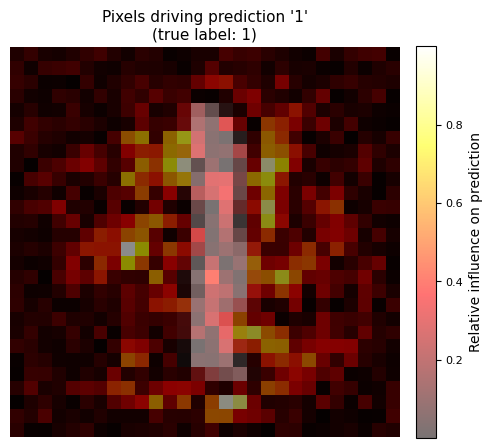

/tmp/ipykernel_16/3762469727.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


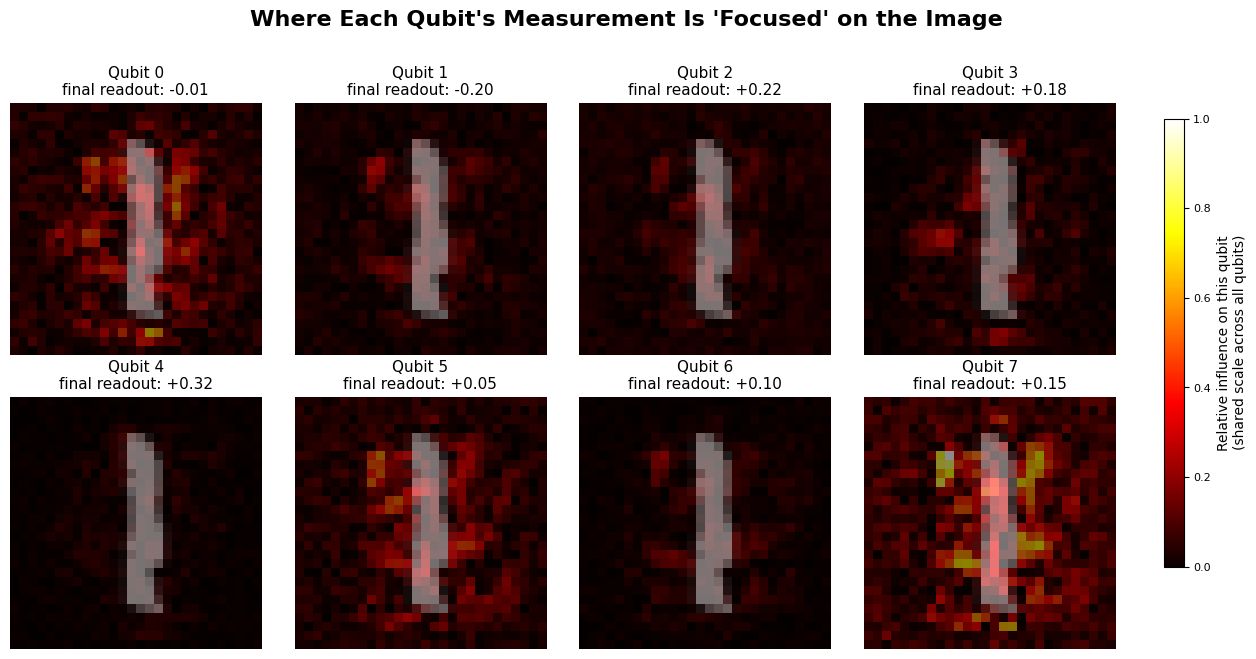

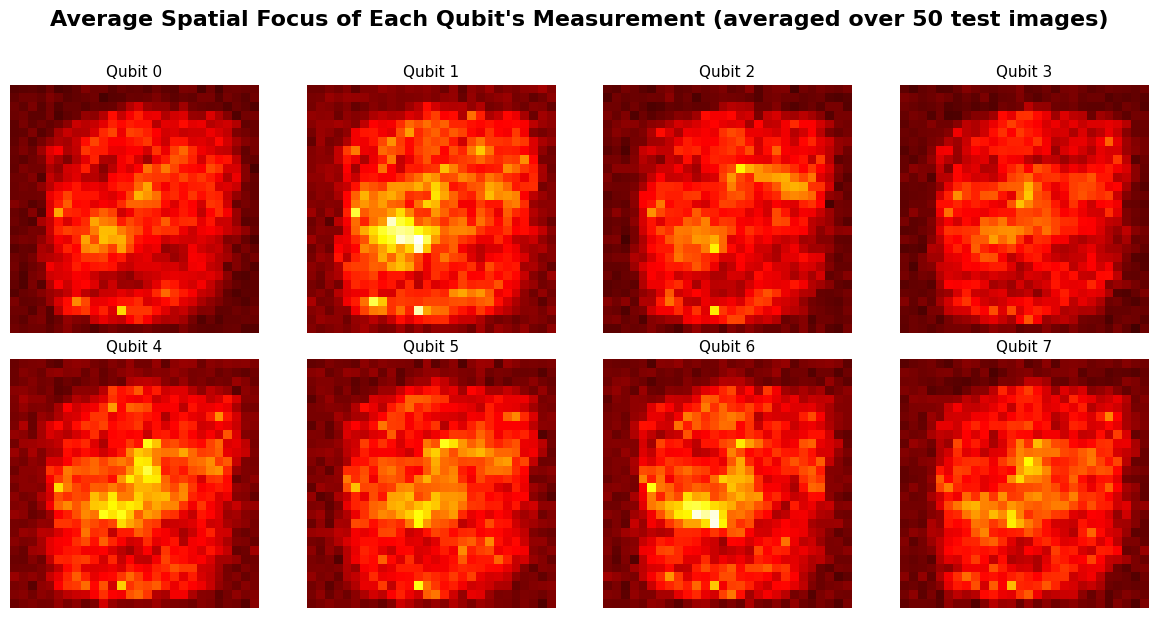

Saliency functions loaded: compute_qubit_saliency_maps(), compute_prediction_saliency(), plot_prediction_saliency(), plot_per_qubit_saliency_grid(), compute_average_saliency(), plot_average_saliency_grid()


In [26]:
# ============================================================
# WHERE DOES EACH QUBIT "LOOK" ON THE IMAGE?
# ============================================================
# This answers: which pixels of the input digit actually drive
# each qubit's final measurement result?
#
# Method: gradient-based saliency. We backpropagate from each
# qubit's final expectation value (or the overall prediction)
# all the way back to the input image pixels. Pixels with a
# large gradient magnitude are the ones that most strongly
# push that qubit's measurement one way or the other.
#
# This works because everything from image -> classical prep ->
# quantum layer -> logits is differentiable (that's how the
# model was trained), so torch autograd can trace the whole path.
#
# Requires: model, DEVICE, internal_test_dataset already loaded,
# and model.quantum must be a differentiable torch-compatible
# layer (e.g. qml.qnn.TorchLayer), which it is since it was
# trained end-to-end with backprop.
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ------------------------------------------------------------
# Font sizes — one place to control all text
# ------------------------------------------------------------
FONT_SIZES = {
    "suptitle":    16,
    "axes_title":  11,
    "axis_label":  11,
    "tick_label":  9,
    "colorbar_label": 10,
    "colorbar_tick":  8,
    "caption":     10,
}
rcParams.update({
    "font.size": FONT_SIZES["tick_label"],
    "axes.titlesize": FONT_SIZES["axes_title"],
    "axes.labelsize": FONT_SIZES["axis_label"],
})


# ============================================================
# STEP 1 — Compute saliency: gradient of each qubit's readout
# with respect to every input pixel
# ============================================================

def compute_qubit_saliency_maps(model, image, device, num_qubits):
    """
    Returns:
      saliency: [num_qubits, H, W]  -- abs(gradient) per pixel, per qubit
      final_readout: [num_qubits]   -- the actual measured values (for reference)
      pred: int, conf: float
    """
    model.eval()

    # Keep gradient flowing into the quantum layer's output
    captured = {}
    def hook(module, inputs_, output):
        output.retain_grad()
        captured["out"] = output
    h = model.quantum.register_forward_hook(hook)

    img = image.clone().unsqueeze(0).to(device)
    img.requires_grad_(True)

    logits = model(img)
    probs = torch.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)

    quantum_out = captured["out"]          # shape [1, num_qubits], has grad
    final_readout = quantum_out.detach().cpu().numpy().squeeze()

    saliency = np.zeros((num_qubits,) + tuple(image.shape[-2:]))

    for q in range(num_qubits):
        if img.grad is not None:
            img.grad.zero_()
        # Backprop from this single qubit's output value
        quantum_out[0, q].backward(retain_graph=True)
        grad = img.grad.detach().cpu().numpy().squeeze()
        saliency[q] = np.abs(grad)

    h.remove()
    return saliency, final_readout, pred.item(), conf.item()


def compute_prediction_saliency(model, image, device):
    """Gradient of the winning class logit w.r.t. input pixels (overall attribution)."""
    model.eval()
    img = image.clone().unsqueeze(0).to(device)
    img.requires_grad_(True)

    logits = model(img)
    pred = torch.argmax(logits, dim=1)

    logits[0, pred.item()].backward()
    grad = img.grad.detach().cpu().numpy().squeeze()
    return np.abs(grad), pred.item()


# ============================================================
# STEP 2 — Plot: overall prediction saliency, overlaid on image
# ============================================================

def plot_prediction_saliency(raw_img, saliency, pred, true_label, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    sal_norm = saliency / (saliency.max() + 1e-8)

    ax.imshow(raw_img, cmap="gray")
    im = ax.imshow(sal_norm, cmap="hot", alpha=0.55)
    ax.set_title(f"Pixels driving prediction '{pred}'\n(true label: {true_label})",
                  fontsize=FONT_SIZES["axes_title"])
    ax.axis("off")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Relative influence on prediction",
                    fontsize=FONT_SIZES["colorbar_label"])
    cbar.ax.tick_params(labelsize=FONT_SIZES["colorbar_tick"])

    if standalone:
        plt.tight_layout()
        plt.savefig("prediction_saliency.png", dpi=200, bbox_inches="tight")
        plt.show()
    return ax


# ============================================================
# STEP 3 — Plot: per-qubit saliency grid (where each qubit looks)
# ============================================================

def plot_per_qubit_saliency_grid(raw_img, saliency, final_readout, num_qubits,
                                   n_cols=4, savepath="per_qubit_saliency.png"):
    n_rows = int(np.ceil(num_qubits / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
    axes = np.atleast_2d(axes)

    global_max = saliency.max() + 1e-8

    for q in range(num_qubits):
        r, c = divmod(q, n_cols)
        ax = axes[r, c]
        sal_norm = saliency[q] / global_max   # shared scale across qubits = comparable

        ax.imshow(raw_img, cmap="gray")
        im = ax.imshow(sal_norm, cmap="hot", alpha=0.55, vmin=0, vmax=1)
        ax.set_title(f"Qubit {q}\nfinal readout: {final_readout[q]:+.2f}",
                      fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    # Hide any unused subplot slots
    for q in range(num_qubits, n_rows * n_cols):
        r, c = divmod(q, n_cols)
        axes[r, c].axis("off")

    fig.suptitle("Where Each Qubit's Measurement Is 'Focused' on the Image",
                  fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.02)

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap="hot", norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Relative influence on this qubit\n(shared scale across all qubits)",
                    fontsize=FONT_SIZES["colorbar_label"])
    cbar.ax.tick_params(labelsize=FONT_SIZES["colorbar_tick"])

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


# ============================================================
# STEP 4 — Plot: average saliency across many test images
# (shows *where the quantum layer generally attends*, not
#  just for one example — much more convincing for a paper)
# ============================================================

def compute_average_saliency(model, dataset, indices, device, num_qubits):
    """Average per-qubit saliency maps across many test images (aligned by pixel grid)."""
    accum = None
    for idx in indices:
        image, _ = dataset[idx]
        sal, _, _, _ = compute_qubit_saliency_maps(model, image, device, num_qubits)
        if accum is None:
            accum = np.zeros_like(sal)
        accum += sal
    accum /= len(indices)
    return accum  # [num_qubits, H, W]


def plot_average_saliency_grid(avg_saliency, num_qubits, n_cols=4, n_samples=None,
                                 savepath="average_qubit_saliency.png"):
    n_rows = int(np.ceil(num_qubits / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.0 * n_rows))
    axes = np.atleast_2d(axes)

    global_max = avg_saliency.max() + 1e-8

    for q in range(num_qubits):
        r, c = divmod(q, n_cols)
        ax = axes[r, c]
        im = ax.imshow(avg_saliency[q] / global_max, cmap="hot", vmin=0, vmax=1)
        ax.set_title(f"Qubit {q}", fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    for q in range(num_qubits, n_rows * n_cols):
        r, c = divmod(q, n_cols)
        axes[r, c].axis("off")

    subtitle = f" (averaged over {n_samples} test images)" if n_samples else " (averaged over test set)"
    fig.suptitle("Average Spatial Focus of Each Qubit's Measurement" + subtitle,
                  fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.02)

    plt.tight_layout()
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


## ============================================================
## EXAMPLE USAGE
## ============================================================

## --- Single example: overall prediction + per-qubit breakdown ---
# example_image, example_label = internal_test_dataset[0]

import random

random_idx = random.randint(0, len(internal_test_dataset) - 1)
example_image, example_label = internal_test_dataset[random_idx]
print(f"Picked test sample index {random_idx} (label: {example_label})")

random.seed(42)  # any fixed number — change it to get a different but stable pick
random_idx = random.randint(0, len(internal_test_dataset) - 1)
example_image, example_label = internal_test_dataset[random_idx]

raw_img = (example_image.squeeze(0).numpy() * 0.3081 + 0.1307)

saliency, final_readout, pred, conf = compute_qubit_saliency_maps(
    model, example_image, DEVICE, NUM_QUBITS
)
pred_saliency, _ = compute_prediction_saliency(model, example_image, DEVICE)

plot_prediction_saliency(raw_img, pred_saliency, pred, example_label)
plot_per_qubit_saliency_grid(raw_img, saliency, final_readout, NUM_QUBITS)

## --- Aggregated over many test images (recommended for a paper) ---
sample_indices = list(range(50))  # e.g. 50 test images
avg_saliency = compute_average_saliency(model, internal_test_dataset,
                                         sample_indices, DEVICE, NUM_QUBITS)
plot_average_saliency_grid(avg_saliency, NUM_QUBITS, n_samples=len(sample_indices))

print("Saliency functions loaded: compute_qubit_saliency_maps(), "
      "compute_prediction_saliency(), plot_prediction_saliency(), "
      "plot_per_qubit_saliency_grid(), compute_average_saliency(), "
      "plot_average_saliency_grid()")

/tmp/ipykernel_16/1721516579.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


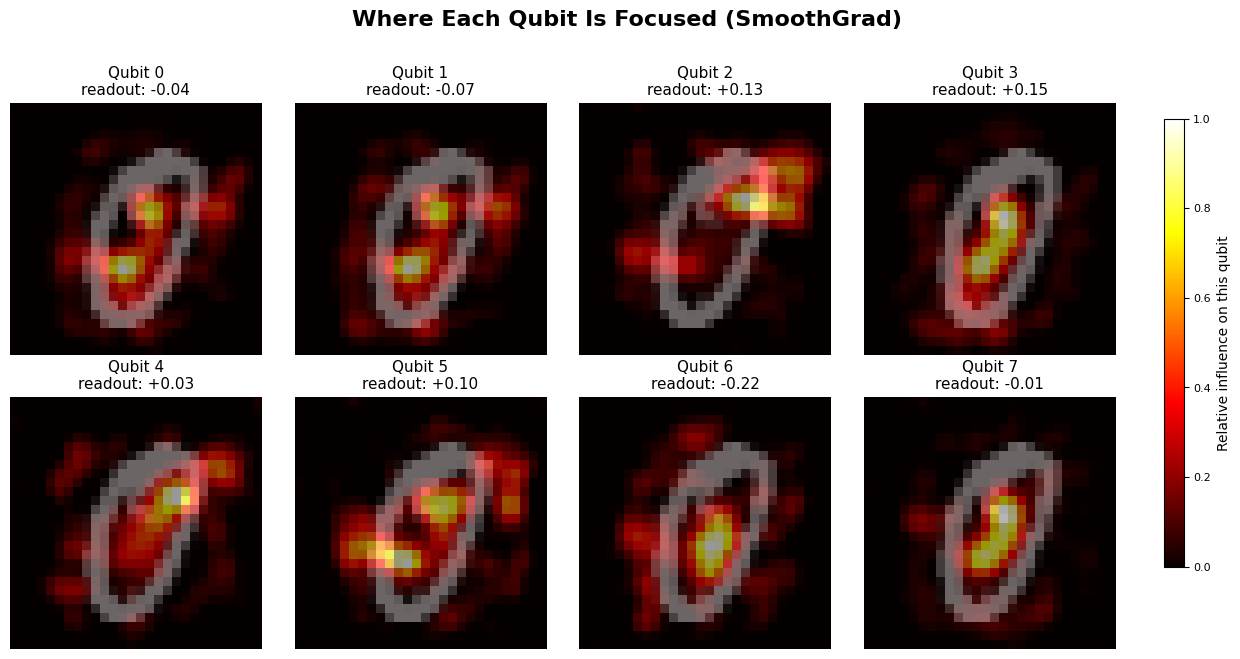

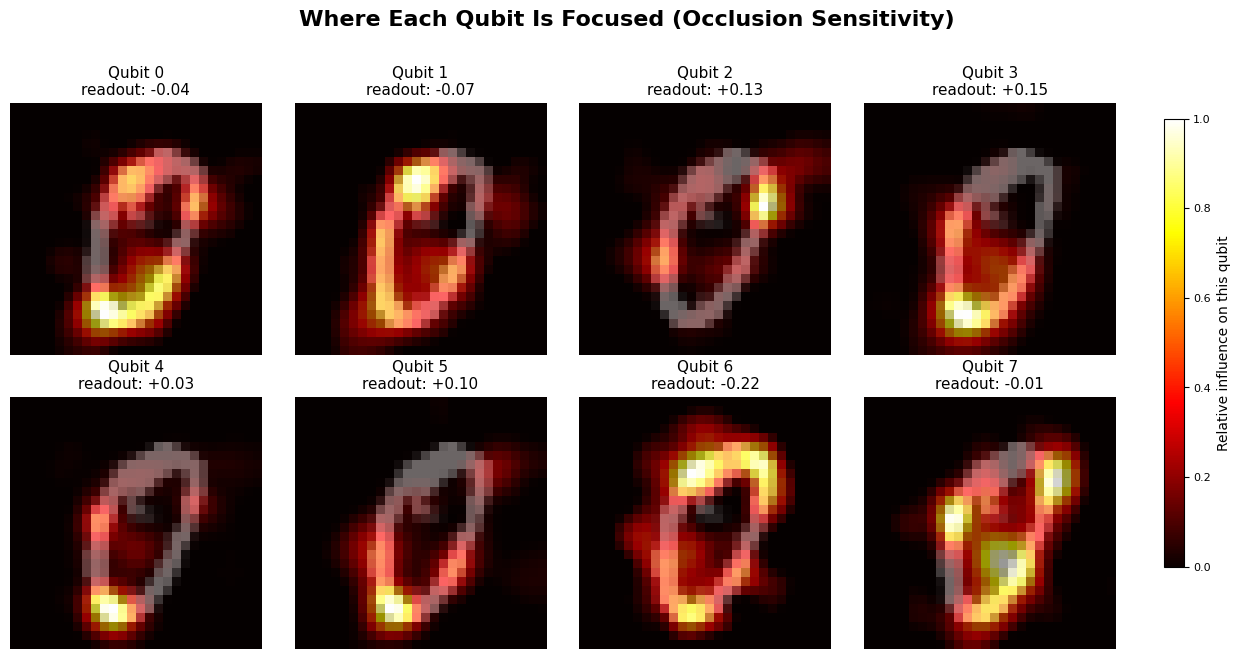

Loaded: clean_saliency_map(), compute_smoothgrad_qubit_saliency(), compute_occlusion_sensitivity(), plot_clean_qubit_grid(), plot_method_comparison()


In [27]:
# ============================================================
# CLEANER, LESS NOISY INTERPRETABILITY MAPS
# ============================================================
# Raw per-pixel gradients are almost always noisy/speckled --
# this is a well-known limitation of vanilla saliency, not a
# bug in your setup. Three fixes, from easiest to most robust:
#
#   1. Gaussian smoothing of the existing gradient map (quick,
#      cosmetic, use only if you're short on time)
#   2. SmoothGrad -- average gradients over many noisy copies
#      of the input (cancels out gradient noise, still uses
#      backprop, cheap)
#   3. Occlusion sensitivity -- no gradients at all. Physically
#      cover a patch of the image, re-run the model, measure
#      how much the qubit's reading changed. Blocky but very
#      clean and intuitive ("covering this part of the digit
#      changed the reading a lot" is easy for anyone to grasp).
#      This is usually the most convincing for a mixed audience.
#
# Recommended for a paper/talk: occlusion sensitivity as the
# primary figure, SmoothGrad as a supporting/consistency check.
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib import rcParams

FONT_SIZES = {
    "suptitle": 16, "axes_title": 11, "axis_label": 11,
    "tick_label": 9, "colorbar_label": 10, "colorbar_tick": 8,
    "caption": 10,
}
rcParams.update({
    "font.size": FONT_SIZES["tick_label"],
    "axes.titlesize": FONT_SIZES["axes_title"],
    "axes.labelsize": FONT_SIZES["axis_label"],
})


# ============================================================
# FIX 1 — Quick cosmetic smoothing of an existing saliency map
# ============================================================

def clean_saliency_map(raw_saliency, sigma=1.2, low_percentile=40):
    """
    raw_saliency: 2D array (single qubit or prediction saliency)
    sigma: Gaussian blur strength -- higher = smoother/blobbier
    low_percentile: values below this percentile get zeroed out,
                     so faint background noise disappears instead
                     of adding a random-looking haze everywhere
    """
    smoothed = gaussian_filter(raw_saliency, sigma=sigma)
    thresh = np.percentile(smoothed, low_percentile)
    cleaned = np.clip(smoothed - thresh, 0, None)
    cleaned = cleaned / (cleaned.max() + 1e-8)
    return cleaned


# ============================================================
# FIX 2 — SmoothGrad: average gradients over noisy copies
# ============================================================

def compute_smoothgrad_qubit_saliency(model, image, device, num_qubits,
                                        n_samples=25, noise_std=0.15):
    """
    Adds small random noise to the image n_samples times, computes
    the gradient each time, and averages. This cancels out the
    jagged, sample-specific noise that plain gradients have, while
    keeping the parts that consistently matter.
    """
    model.eval()
    accum = np.zeros((num_qubits,) + tuple(image.shape[-2:]))

    for _ in range(n_samples):
        noisy_img = image + torch.randn_like(image) * noise_std
        noisy_img = noisy_img.clone().unsqueeze(0).to(device)
        noisy_img.requires_grad_(True)

        captured = {}
        def hook(module, inputs_, output):
            output.retain_grad()
            captured["out"] = output
        h = model.quantum.register_forward_hook(hook)

        _ = model(noisy_img)
        quantum_out = captured["out"]

        for q in range(num_qubits):
            if noisy_img.grad is not None:
                noisy_img.grad.zero_()
            quantum_out[0, q].backward(retain_graph=True)
            grad = noisy_img.grad.detach().cpu().numpy().squeeze()
            accum[q] += np.abs(grad)

        h.remove()

    accum /= n_samples
    return accum  # [num_qubits, H, W] -- already much less noisy


# ============================================================
# FIX 3 — Occlusion sensitivity (no gradients, most intuitive)
# ============================================================

def compute_occlusion_sensitivity(model, image, device, num_qubits,
                                    patch_size=4, stride=2, baseline_value=0.0):
    """
    Slides a small square patch across the image, replacing that
    patch with `baseline_value` (blank/gray) each time, and measures
    how much each qubit's final reading shifts compared to the
    un-occluded image. Big shift = that patch mattered a lot.

    Returns:
      sensitivity: [num_qubits, H, W] -- upsampled to full image size,
                   where each pixel's value = how much occluding that
                   region changed the qubit's reading
      baseline_readout: [num_qubits] -- the un-occluded reading
    """
    model.eval()
    H, W = image.shape[-2:]

    captured = {}
    def hook(module, inputs_, output):
        captured["out"] = output.detach().cpu().numpy().squeeze()
    h = model.quantum.register_forward_hook(hook)

    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))
    baseline_readout = captured["out"].copy()

    n_rows = (H - patch_size) // stride + 1
    n_cols = (W - patch_size) // stride + 1
    low_res_sensitivity = np.zeros((num_qubits, n_rows, n_cols))

    for i in range(n_rows):
        for j in range(n_cols):
            r0, c0 = i * stride, j * stride
            occluded = image.clone()
            occluded[..., r0:r0 + patch_size, c0:c0 + patch_size] = baseline_value

            with torch.no_grad():
                _ = model(occluded.unsqueeze(0).to(device))
            occluded_readout = captured["out"]

            shift = np.abs(occluded_readout - baseline_readout)
            low_res_sensitivity[:, i, j] = shift

    h.remove()

    # Upsample the low-res sensitivity grid back to full image resolution
    sensitivity = np.zeros((num_qubits, H, W))
    for q in range(num_qubits):
        t = torch.tensor(low_res_sensitivity[q]).unsqueeze(0).unsqueeze(0).float()
        up = F.interpolate(t, size=(H, W), mode="bilinear", align_corners=False)
        sensitivity[q] = up.squeeze().numpy()

    return sensitivity, baseline_readout


# ============================================================
# PLOTTING — clean, thresholded overlays
# ============================================================

def plot_clean_qubit_grid(raw_img, sensitivity_or_saliency, readout, num_qubits,
                            n_cols=4, title="Where Each Qubit Is Actually Focused",
                            apply_smoothing=True, savepath="clean_qubit_map.png"):
    n_rows = int(np.ceil(num_qubits / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
    axes = np.atleast_2d(axes)

    global_max = sensitivity_or_saliency.max() + 1e-8

    for q in range(num_qubits):
        r, c = divmod(q, n_cols)
        ax = axes[r, c]

        m = sensitivity_or_saliency[q] / global_max
        if apply_smoothing:
            m = clean_saliency_map(m, sigma=1.0, low_percentile=50)

        ax.imshow(raw_img, cmap="gray")
        im = ax.imshow(m, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.set_title(f"Qubit {q}\nreadout: {readout[q]:+.2f}",
                      fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    for q in range(num_qubits, n_rows * n_cols):
        r, c = divmod(q, n_cols)
        axes[r, c].axis("off")

    fig.suptitle(title, fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.02)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap="hot", norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Relative influence on this qubit",
                    fontsize=FONT_SIZES["colorbar_label"])
    cbar.ax.tick_params(labelsize=FONT_SIZES["colorbar_tick"])

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


def plot_method_comparison(raw_img, gradient_map, smoothgrad_map, occlusion_map,
                             qubit_idx, savepath="method_comparison.png"):
    """Side-by-side: same qubit, three methods, so you can pick the cleanest for your paper."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles = ["Raw gradient\n(noisy)", "SmoothGrad\n(denoised gradient)",
              "Occlusion sensitivity\n(no gradients, blocky but clean)"]
    maps = [gradient_map, smoothgrad_map, occlusion_map]

    for ax, m, t in zip(axes, maps, titles):
        m_norm = clean_saliency_map(m / (m.max() + 1e-8), sigma=1.0, low_percentile=40)
        ax.imshow(raw_img, cmap="gray")
        ax.imshow(m_norm, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.set_title(t, fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    fig.suptitle(f"Qubit {qubit_idx} — Method Comparison",
                  fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


# ============================================================
# EXAMPLE USAGE
# ============================================================

import random
random_idx = random.randint(0, len(internal_test_dataset) - 1)
example_image, example_label = internal_test_dataset[random_idx]
raw_img = (example_image.squeeze(0).numpy() * 0.3081 + 0.1307)

# SmoothGrad (recommended default -- good balance of speed and clean output)
smoothgrad_map = compute_smoothgrad_qubit_saliency(
    model, example_image, DEVICE, NUM_QUBITS, n_samples=25, noise_std=0.15
)
#
# # Occlusion sensitivity (slower but most intuitive / cleanest)
occlusion_map, readout = compute_occlusion_sensitivity(
    model, example_image, DEVICE, NUM_QUBITS, patch_size=4, stride=2
)

plot_clean_qubit_grid(raw_img, smoothgrad_map, readout, NUM_QUBITS,
                       title="Where Each Qubit Is Focused (SmoothGrad)")
plot_clean_qubit_grid(raw_img, occlusion_map, readout, NUM_QUBITS,
                       title="Where Each Qubit Is Focused (Occlusion Sensitivity)")

print("Loaded: clean_saliency_map(), compute_smoothgrad_qubit_saliency(), "
      "compute_occlusion_sensitivity(), plot_clean_qubit_grid(), "
      "plot_method_comparison()")

/tmp/ipykernel_16/3986632048.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


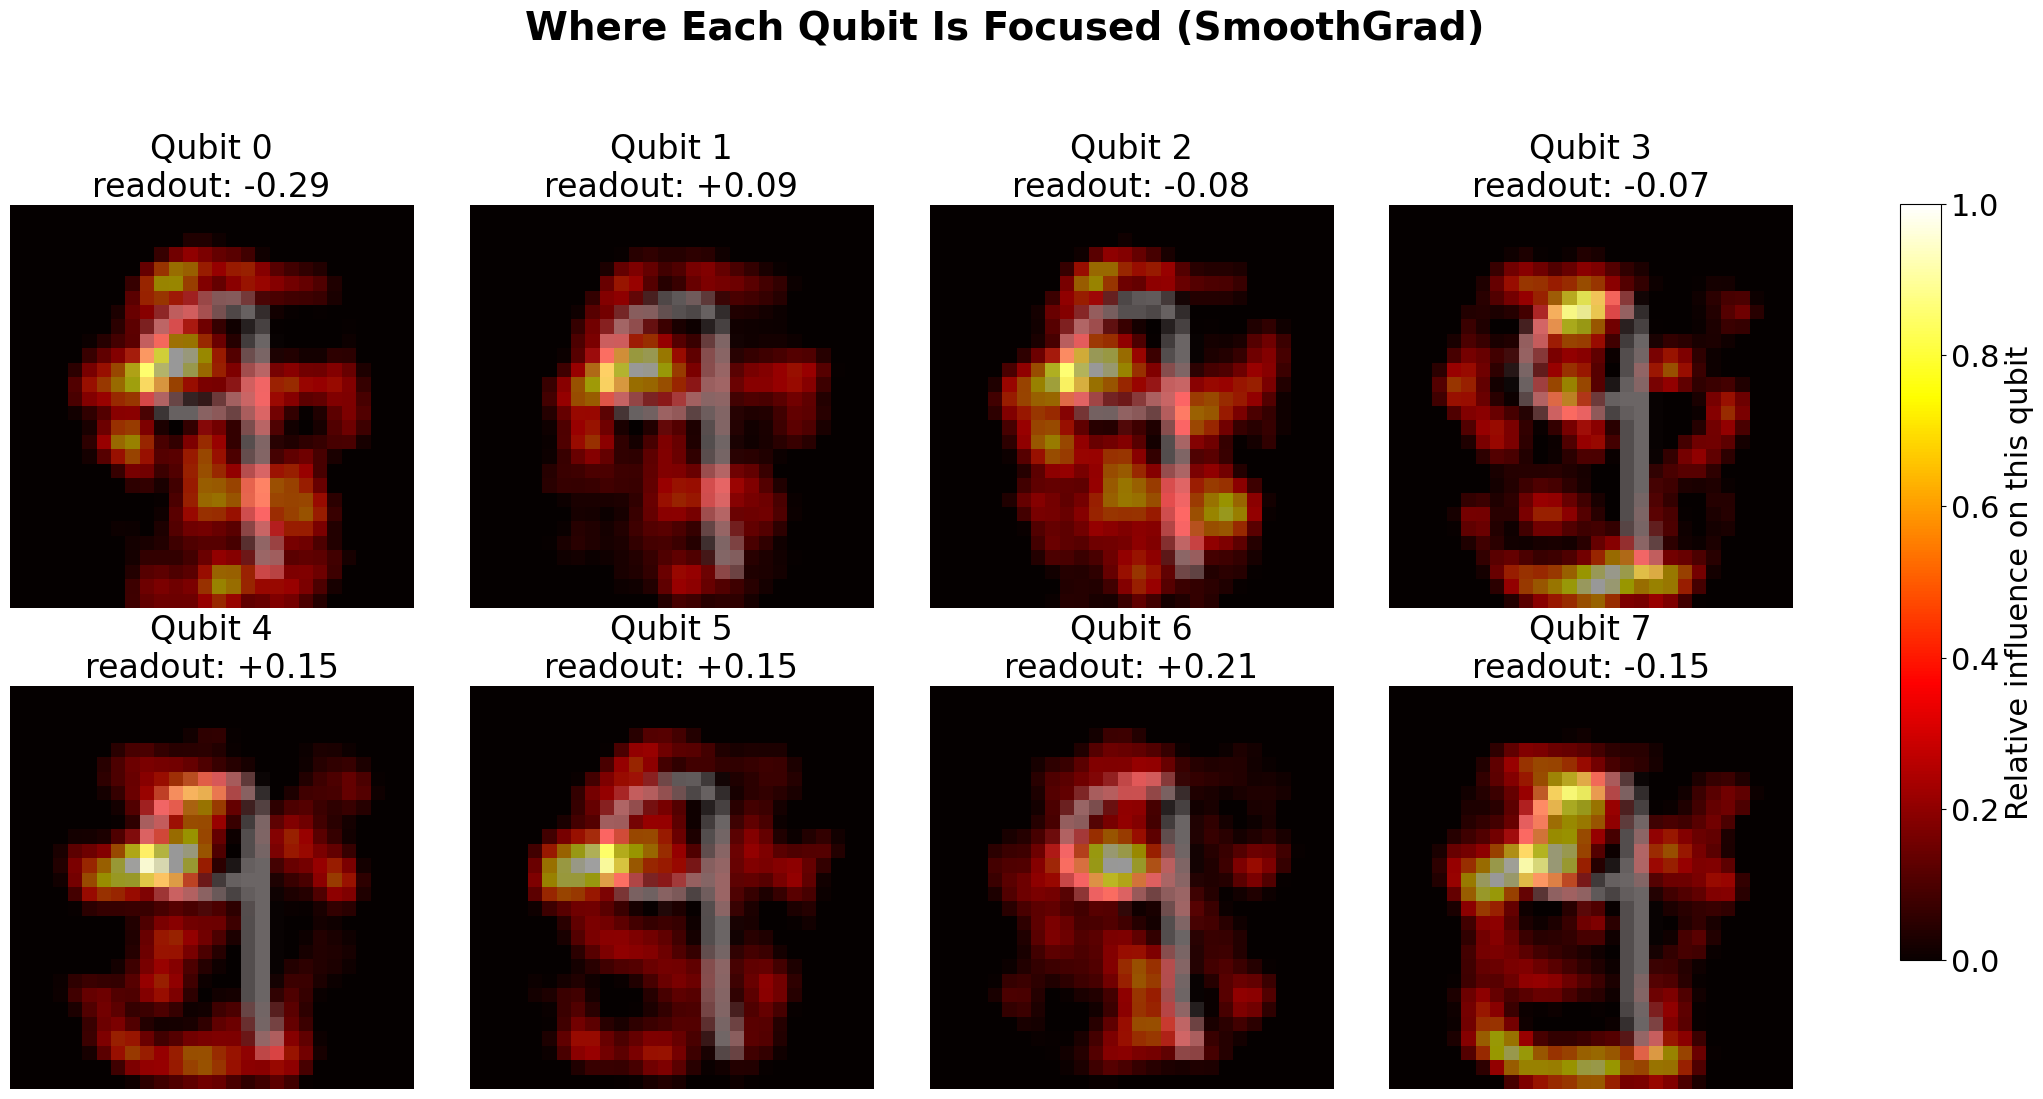

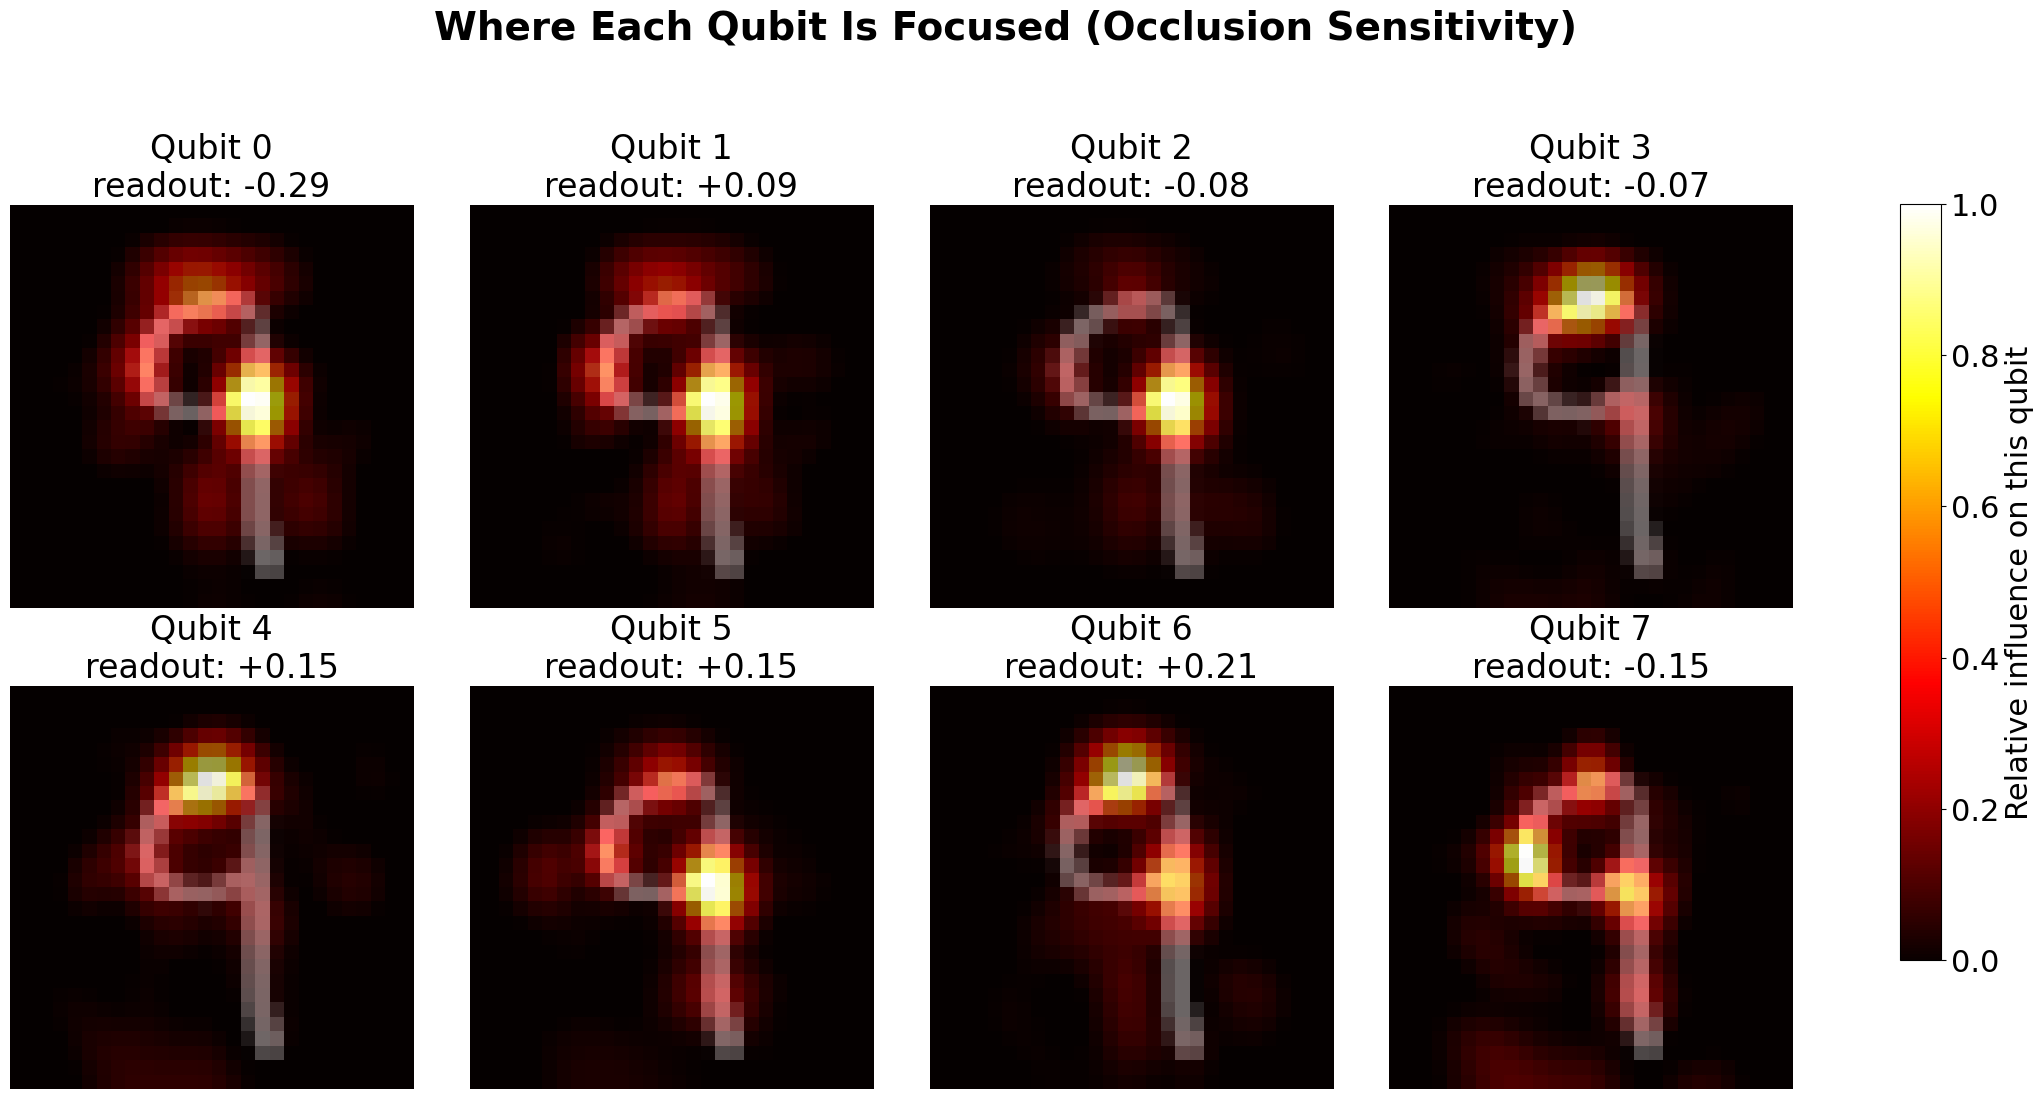

Loaded: clean_saliency_map(), compute_smoothgrad_qubit_saliency(), compute_occlusion_sensitivity(), plot_clean_qubit_grid(), plot_method_comparison()


In [28]:
# ============================================================
# CLEANER, LESS NOISY INTERPRETABILITY MAPS
# ============================================================
# Raw per-pixel gradients are almost always noisy/speckled --
# this is a well-known limitation of vanilla saliency, not a
# bug in your setup. Three fixes, from easiest to most robust:
#
#   1. Gaussian smoothing of the existing gradient map (quick,
#      cosmetic, use only if you're short on time)
#   2. SmoothGrad -- average gradients over many noisy copies
#      of the input (cancels out gradient noise, still uses
#      backprop, cheap)
#   3. Occlusion sensitivity -- no gradients at all. Physically
#      cover a patch of the image, re-run the model, measure
#      how much the qubit's reading changed. Blocky but very
#      clean and intuitive ("covering this part of the digit
#      changed the reading a lot" is easy for anyone to grasp).
#      This is usually the most convincing for a mixed audience.
#
# Recommended for a paper/talk: occlusion sensitivity as the
# primary figure, SmoothGrad as a supporting/consistency check.
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib import rcParams

# ------------------------------------------------------------
# ONE PLACE TO CONTROL EVERY FONT SIZE — all values >= 22
# ------------------------------------------------------------
FONT_SIZES = {
    "suptitle":       28,
    "axes_title":     24,
    "axis_label":     22,
    "tick_label":     22,
    "colorbar_label": 22,
    "colorbar_tick":  22,
    "caption":        22,
}
rcParams.update({
    "font.size": FONT_SIZES["tick_label"],
    "axes.titlesize": FONT_SIZES["axes_title"],
    "axes.labelsize": FONT_SIZES["axis_label"],
    "xtick.labelsize": FONT_SIZES["tick_label"],
    "ytick.labelsize": FONT_SIZES["tick_label"],
})


# ============================================================
# FIX 1 — Quick cosmetic smoothing of an existing saliency map
# ============================================================

def clean_saliency_map(raw_saliency, sigma=1.2, low_percentile=40):
    """
    raw_saliency: 2D array (single qubit or prediction saliency)
    sigma: Gaussian blur strength -- higher = smoother/blobbier
    low_percentile: values below this percentile get zeroed out,
                     so faint background noise disappears instead
                     of adding a random-looking haze everywhere
    """
    smoothed = gaussian_filter(raw_saliency, sigma=sigma)
    thresh = np.percentile(smoothed, low_percentile)
    cleaned = np.clip(smoothed - thresh, 0, None)
    cleaned = cleaned / (cleaned.max() + 1e-8)
    return cleaned


# ============================================================
# FIX 2 — SmoothGrad: average gradients over noisy copies
# ============================================================

def compute_smoothgrad_qubit_saliency(model, image, device, num_qubits,
                                        n_samples=25, noise_std=0.15):
    """
    Adds small random noise to the image n_samples times, computes
    the gradient each time, and averages. This cancels out the
    jagged, sample-specific noise that plain gradients have, while
    keeping the parts that consistently matter.
    """
    model.eval()
    accum = np.zeros((num_qubits,) + tuple(image.shape[-2:]))

    for _ in range(n_samples):
        noisy_img = image + torch.randn_like(image) * noise_std
        noisy_img = noisy_img.clone().unsqueeze(0).to(device)
        noisy_img.requires_grad_(True)

        captured = {}
        def hook(module, inputs_, output):
            output.retain_grad()
            captured["out"] = output
        h = model.quantum.register_forward_hook(hook)

        _ = model(noisy_img)
        quantum_out = captured["out"]

        for q in range(num_qubits):
            if noisy_img.grad is not None:
                noisy_img.grad.zero_()
            quantum_out[0, q].backward(retain_graph=True)
            grad = noisy_img.grad.detach().cpu().numpy().squeeze()
            accum[q] += np.abs(grad)

        h.remove()

    accum /= n_samples
    return accum  # [num_qubits, H, W] -- already much less noisy


# ============================================================
# FIX 3 — Occlusion sensitivity (no gradients, most intuitive)
# ============================================================

def compute_occlusion_sensitivity(model, image, device, num_qubits,
                                    patch_size=4, stride=2, baseline_value=0.0):
    """
    Slides a small square patch across the image, replacing that
    patch with `baseline_value` (blank/gray) each time, and measures
    how much each qubit's final reading shifts compared to the
    un-occluded image. Big shift = that patch mattered a lot.

    Returns:
      sensitivity: [num_qubits, H, W] -- upsampled to full image size,
                   where each pixel's value = how much occluding that
                   region changed the qubit's reading
      baseline_readout: [num_qubits] -- the un-occluded reading
    """
    model.eval()
    H, W = image.shape[-2:]

    captured = {}
    def hook(module, inputs_, output):
        captured["out"] = output.detach().cpu().numpy().squeeze()
    h = model.quantum.register_forward_hook(hook)

    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))
    baseline_readout = captured["out"].copy()

    n_rows = (H - patch_size) // stride + 1
    n_cols = (W - patch_size) // stride + 1
    low_res_sensitivity = np.zeros((num_qubits, n_rows, n_cols))

    for i in range(n_rows):
        for j in range(n_cols):
            r0, c0 = i * stride, j * stride
            occluded = image.clone()
            occluded[..., r0:r0 + patch_size, c0:c0 + patch_size] = baseline_value

            with torch.no_grad():
                _ = model(occluded.unsqueeze(0).to(device))
            occluded_readout = captured["out"]

            shift = np.abs(occluded_readout - baseline_readout)
            low_res_sensitivity[:, i, j] = shift

    h.remove()

    # Upsample the low-res sensitivity grid back to full image resolution
    sensitivity = np.zeros((num_qubits, H, W))
    for q in range(num_qubits):
        t = torch.tensor(low_res_sensitivity[q]).unsqueeze(0).unsqueeze(0).float()
        up = F.interpolate(t, size=(H, W), mode="bilinear", align_corners=False)
        sensitivity[q] = up.squeeze().numpy()

    return sensitivity, baseline_readout


# ============================================================
# PLOTTING — clean, thresholded overlays
# ============================================================

def plot_clean_qubit_grid(raw_img, sensitivity_or_saliency, readout, num_qubits,
                            n_cols=4, title="Where Each Qubit Is Actually Focused",
                            apply_smoothing=True, savepath="clean_qubit_map.png"):
    n_rows = int(np.ceil(num_qubits / n_cols))
    # Widened per-panel size so 24pt titles / 22pt colorbar text have room
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 5.4 * n_rows))
    axes = np.atleast_2d(axes)

    global_max = sensitivity_or_saliency.max() + 1e-8

    for q in range(num_qubits):
        r, c = divmod(q, n_cols)
        ax = axes[r, c]

        m = sensitivity_or_saliency[q] / global_max
        if apply_smoothing:
            m = clean_saliency_map(m, sigma=1.0, low_percentile=50)

        ax.imshow(raw_img, cmap="gray")
        im = ax.imshow(m, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.set_title(f"Qubit {q}\nreadout: {readout[q]:+.2f}",
                      fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    for q in range(num_qubits, n_rows * n_cols):
        r, c = divmod(q, n_cols)
        axes[r, c].axis("off")

    fig.suptitle(title, fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.03)

    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap="hot", norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Relative influence on this qubit",
                    fontsize=FONT_SIZES["colorbar_label"])
    cbar.ax.tick_params(labelsize=FONT_SIZES["colorbar_tick"])

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


def plot_method_comparison(raw_img, gradient_map, smoothgrad_map, occlusion_map,
                             qubit_idx, savepath="method_comparison.png"):
    """Side-by-side: same qubit, three methods, so you can pick the cleanest for your paper."""
    fig, axes = plt.subplots(1, 3, figsize=(21, 8))
    titles = ["Raw gradient\n(noisy)", "SmoothGrad\n(denoised gradient)",
              "Occlusion sensitivity\n(no gradients, blocky but clean)"]
    maps = [gradient_map, smoothgrad_map, occlusion_map]

    for ax, m, t in zip(axes, maps, titles):
        m_norm = clean_saliency_map(m / (m.max() + 1e-8), sigma=1.0, low_percentile=40)
        ax.imshow(raw_img, cmap="gray")
        ax.imshow(m_norm, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.set_title(t, fontsize=FONT_SIZES["axes_title"])
        ax.axis("off")

    fig.suptitle(f"Qubit {qubit_idx} — Method Comparison",
                  fontsize=FONT_SIZES["suptitle"], fontweight="bold", y=1.08)
    plt.tight_layout()
    plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


# ============================================================
# EXAMPLE USAGE
# ============================================================

import random
random_idx = random.randint(0, len(internal_test_dataset) - 1)
example_image, example_label = internal_test_dataset[random_idx]
raw_img = (example_image.squeeze(0).numpy() * 0.3081 + 0.1307)

# SmoothGrad (recommended default -- good balance of speed and clean output)
smoothgrad_map = compute_smoothgrad_qubit_saliency(
    model, example_image, DEVICE, NUM_QUBITS, n_samples=25, noise_std=0.15
)
#
# # Occlusion sensitivity (slower but most intuitive / cleanest)
occlusion_map, readout = compute_occlusion_sensitivity(
    model, example_image, DEVICE, NUM_QUBITS, patch_size=4, stride=2
)

plot_clean_qubit_grid(raw_img, smoothgrad_map, readout, NUM_QUBITS,
                       title="Where Each Qubit Is Focused (SmoothGrad)")
plot_clean_qubit_grid(raw_img, occlusion_map, readout, NUM_QUBITS,
                       title="Where Each Qubit Is Focused (Occlusion Sensitivity)")

print("Loaded: clean_saliency_map(), compute_smoothgrad_qubit_saliency(), "
      "compute_occlusion_sensitivity(), plot_clean_qubit_grid(), "
      "plot_method_comparison()")

In [29]:
# ============================================================
# LATENT FEATURE REPRESENTATION ANALYSIS
# ============================================================
#
# MNIST DeepQNN:
#
# Image
#   ↓
# SIMAM
#   ↓
# 784
#   ↓
# Linear 784 → 256
#   ↓
# LATENT SPACE 1: 256-D
#   ↓
# Linear 256 → 128
#   ↓
# LATENT SPACE 2: 128-D
#   ↓
# Linear 128 → 8
#   ↓
# LATENT SPACE 3: 8-D
#   ↓
# tanh × π
#   ↓
# Quantum circuit
#   ↓
# 8 quantum measurements
#   ↓
# Classifier
#
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm


# ============================================================
# LOAD BEST SAVED MODEL
# ============================================================

BEST_MODEL_PATH = (
    "/kaggle/working/best_model_checkpoint_reconstructed.pth"
)

print("\n" + "=" * 60)
print("LOADING TRAINED MODEL FOR LATENT ANALYSIS")
print("=" * 60)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    f"Checkpoint Epoch     : {checkpoint['epoch']}"
)

print(
    f"Validation Accuracy  : "
    f"{checkpoint['val_accuracy']:.2f}%"
)

print("=" * 60)


# ============================================================
# EXTRACT LATENT REPRESENTATIONS
# ============================================================

latent_256 = []
latent_128 = []
latent_8 = []

all_labels = []
all_predictions = []

print("\nExtracting latent representations...")


with torch.no_grad():

    for images, labels in tqdm(
        internal_test_loader,
        desc="Extracting features"
    ):

        images = images.to(DEVICE)

        # ----------------------------------------------------
        # STEP 1 — SIMAM
        # ----------------------------------------------------

        x = model.simam(images)

        # ----------------------------------------------------
        # STEP 2 — Flatten
        # ----------------------------------------------------

        x = x.flatten(
            start_dim=1
        )

        # ----------------------------------------------------
        # STEP 3 — 784 → 256
        # ----------------------------------------------------

        x_256 = model.classical[0](x)

        x_256 = model.classical[1](x_256)

        # ----------------------------------------------------
        # STEP 4 — 256 → 128
        # ----------------------------------------------------

        x_128 = model.classical[2](x_256)

        x_128 = model.classical[3](x_128)

        # ----------------------------------------------------
        # STEP 5 — 128 → 8
        # ----------------------------------------------------

        x_8 = model.classical[4](x_128)

        # ----------------------------------------------------
        # Save latent representations
        # ----------------------------------------------------

        latent_256.append(
            x_256.cpu().numpy()
        )

        latent_128.append(
            x_128.cpu().numpy()
        )

        latent_8.append(
            x_8.cpu().numpy()
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        quantum_input = (
            torch.tanh(x_8) * np.pi
        )

        quantum_output = model.quantum(
            quantum_input.cpu()
        )

        quantum_output = quantum_output.to(
            DEVICE
        )

        logits = model.classifier(
            quantum_output
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_labels.append(
            labels.numpy()
        )

        all_predictions.append(
            predictions.cpu().numpy()
        )


# ============================================================
# CONCATENATE
# ============================================================

latent_256 = np.concatenate(
    latent_256,
    axis=0
)

latent_128 = np.concatenate(
    latent_128,
    axis=0
)

latent_8 = np.concatenate(
    latent_8,
    axis=0
)

all_labels = np.concatenate(
    all_labels,
    axis=0
)

all_predictions = np.concatenate(
    all_predictions,
    axis=0
)


print("\nLatent representations extracted:")

print(
    f"256-D latent representation : "
    f"{latent_256.shape}"
)

print(
    f"128-D latent representation : "
    f"{latent_128.shape}"
)

print(
    f"8-D latent representation   : "
    f"{latent_8.shape}"
)


LOADING TRAINED MODEL FOR LATENT ANALYSIS
Checkpoint Epoch     : 8
Validation Accuracy  : 96.74%

Extracting latent representations...


Extracting features:   0%|          | 0/141 [00:00<?, ?it/s]


Latent representations extracted:
256-D latent representation : (9000, 256)
128-D latent representation : (9000, 128)
8-D latent representation   : (9000, 8)


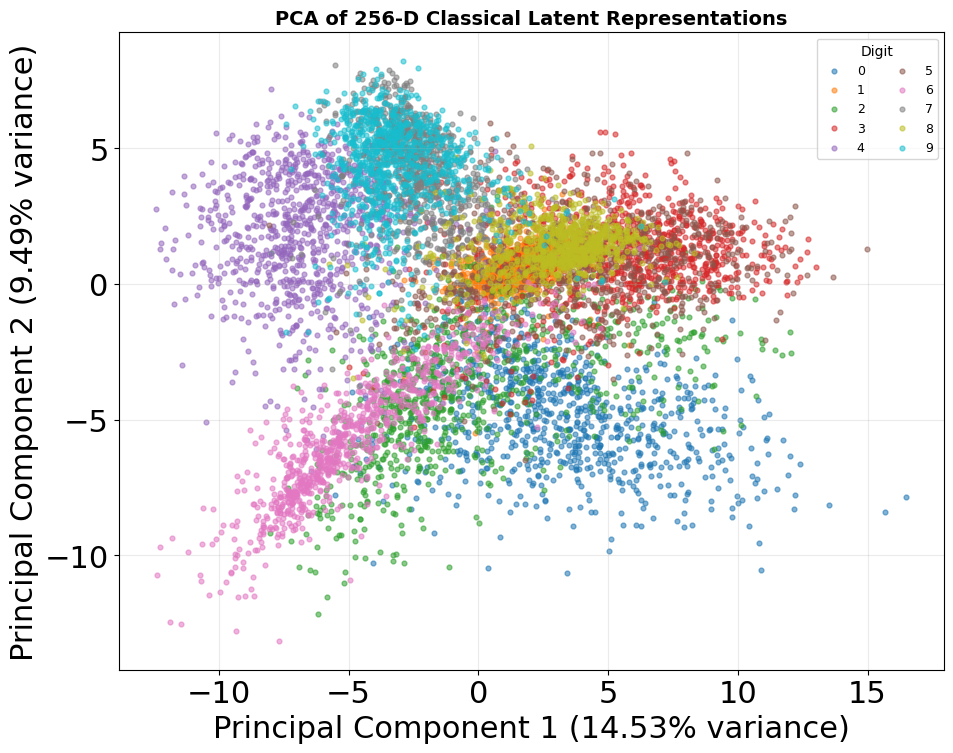

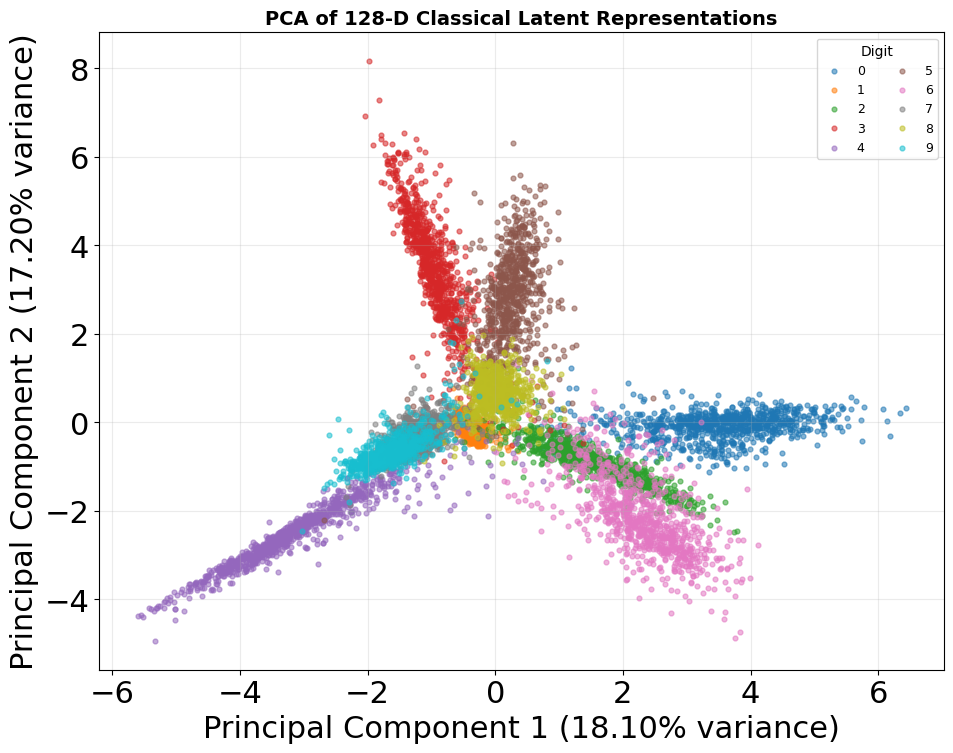

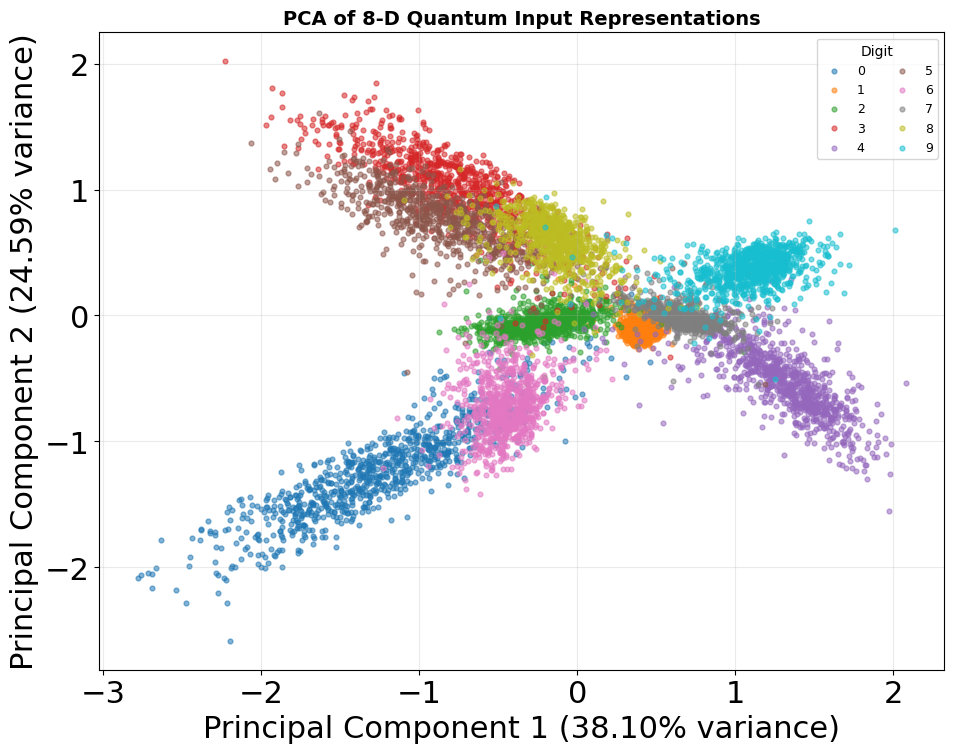

In [30]:
# ============================================================
# PCA — LATENT REPRESENTATION VISUALIZATION
# ============================================================

def plot_pca(
    features,
    labels,
    title,
    filename
):

    pca = PCA(
        n_components=2,
        random_state=SEED
    )

    reduced = pca.fit_transform(
        features
    )

    explained = (
        pca.explained_variance_ratio_
        * 100
    )

    plt.figure(
        figsize=(10, 8)
    )

    for digit in range(10):

        mask = (
            labels == digit
        )

        plt.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            s=12,
            alpha=0.55,
            label=str(digit)
        )

    plt.xlabel(
        f"Principal Component 1 "
        f"({explained[0]:.2f}% variance)"
    )

    plt.ylabel(
        f"Principal Component 2 "
        f"({explained[1]:.2f}% variance)"
    )

    plt.title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        title="Digit",
        ncol=2
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return reduced, explained

# ============================================================
# PCA — 256-D
# ============================================================

pca_256, explained_256 = plot_pca(
    latent_256,
    all_labels,
    "PCA of 256-D Classical Latent Representations",
    "latent_pca_256.png"
)


# ============================================================
# PCA — 128-D
# ============================================================

pca_128, explained_128 = plot_pca(
    latent_128,
    all_labels,
    "PCA of 128-D Classical Latent Representations",
    "latent_pca_128.png"
)


# ============================================================
# PCA — 8-D
# ============================================================

pca_8, explained_8 = plot_pca(
    latent_8,
    all_labels,
    "PCA of 8-D Quantum Input Representations",
    "latent_pca_8.png"
)

In [31]:
# ============================================================
# SILHOUETTE SCORE
# ============================================================

print("\n" + "=" * 60)
print("LATENT SPACE SEPARABILITY")
print("=" * 60)


silhouette_256 = silhouette_score(
    latent_256,
    all_labels
)

silhouette_128 = silhouette_score(
    latent_128,
    all_labels
)

silhouette_8 = silhouette_score(
    latent_8,
    all_labels
)


print(
    f"256-D latent space : "
    f"{silhouette_256:.4f}"
)

print(
    f"128-D latent space : "
    f"{silhouette_128:.4f}"
)

print(
    f"8-D latent space   : "
    f"{silhouette_8:.4f}"
)

print("=" * 60)


LATENT SPACE SEPARABILITY
256-D latent space : 0.1115
128-D latent space : 0.3553
8-D latent space   : 0.5048


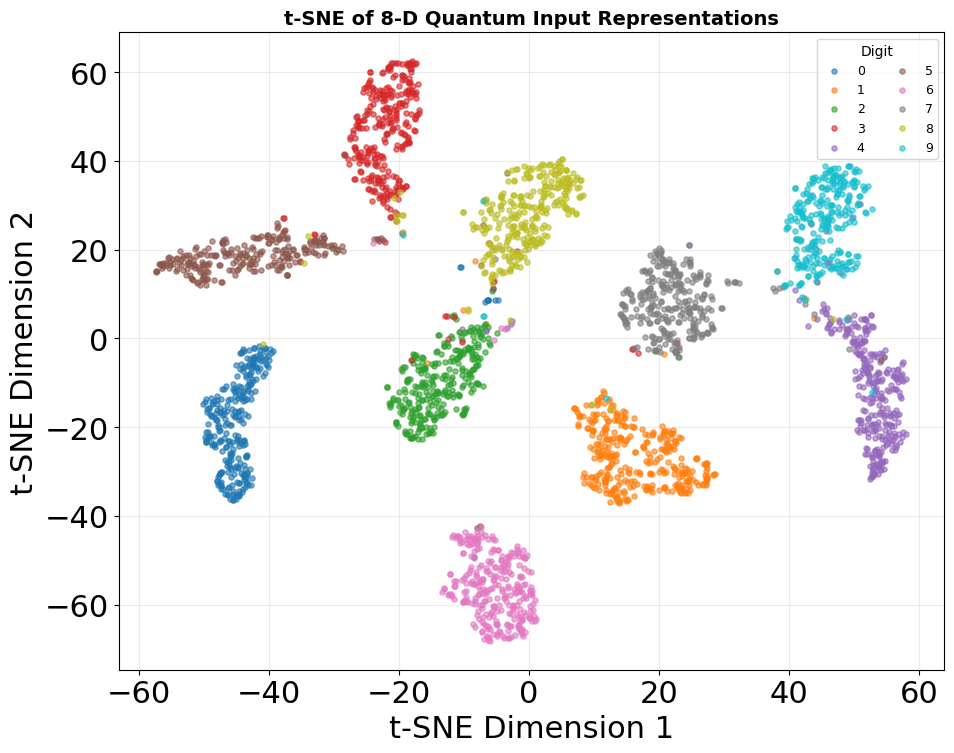

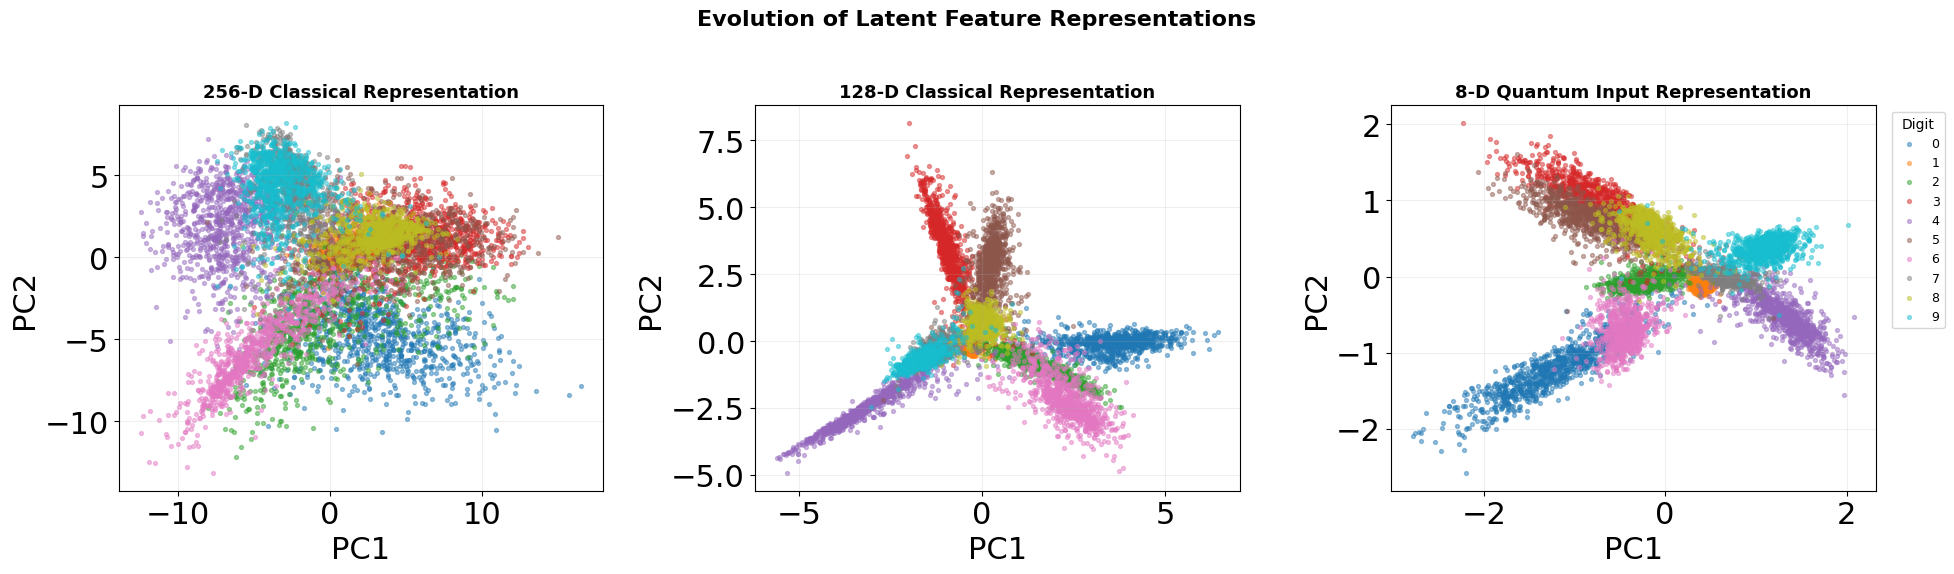

In [32]:
# ============================================================
# t-SNE
# ============================================================

MAX_TSNE_SAMPLES = 3000

rng = np.random.default_rng(
    SEED
)

if len(all_labels) > MAX_TSNE_SAMPLES:

    tsne_indices = rng.choice(
        len(all_labels),
        size=MAX_TSNE_SAMPLES,
        replace=False
    )

else:

    tsne_indices = np.arange(
        len(all_labels)
    )


def plot_tsne(
    features,
    labels,
    title,
    filename
):

    selected_features = (
        features[tsne_indices]
    )

    selected_labels = (
        labels[tsne_indices]
    )

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=SEED,
        init="pca",
        learning_rate="auto"
    )

    reduced = tsne.fit_transform(
        selected_features
    )

    plt.figure(
        figsize=(10, 8)
    )

    for digit in range(10):

        mask = (
            selected_labels == digit
        )

        plt.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            s=14,
            alpha=0.6,
            label=str(digit)
        )

    plt.xlabel(
        "t-SNE Dimension 1"
    )

    plt.ylabel(
        "t-SNE Dimension 2"
    )

    plt.title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        title="Digit",
        ncol=2
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

plot_tsne(
    latent_8,
    all_labels,
    "t-SNE of 8-D Quantum Input Representations",
    "latent_tsne_8.png"
)


# ============================================================
# REPRESENTATION EVOLUTION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)


representations = [
    (latent_256, "256-D Classical Representation"),
    (latent_128, "128-D Classical Representation"),
    (latent_8, "8-D Quantum Input Representation")
]


for ax, (features, title) in zip(
    axes,
    representations
):

    pca = PCA(
        n_components=2,
        random_state=SEED
    )

    reduced = pca.fit_transform(
        features
    )

    for digit in range(10):

        mask = (
            all_labels == digit
        )

        ax.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            s=8,
            alpha=0.45,
            label=str(digit)
        )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "PC1"
    )

    ax.set_ylabel(
        "PC2"
    )

    ax.grid(
        alpha=0.2
    )


axes[-1].legend(
    title="Digit",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.suptitle(
    "Evolution of Latent Feature Representations",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "latent_representation_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LATENT FEATURE REPRESENTATION ANALYSIS
Checkpoint epoch : 8
Validation acc   : 96.74444444444444

REAL MNIST DIGIT: 6
Input image              : (28, 28)
After SIMAM              : (28, 28)
Flattened                : (784,)
Classical latent 1       : (256,)
Classical latent 2       : (128,)
Quantum input latent     : (8,)
Quantum latent           : (8,)
Classifier latent        : (64,)
Output                   : (10,)


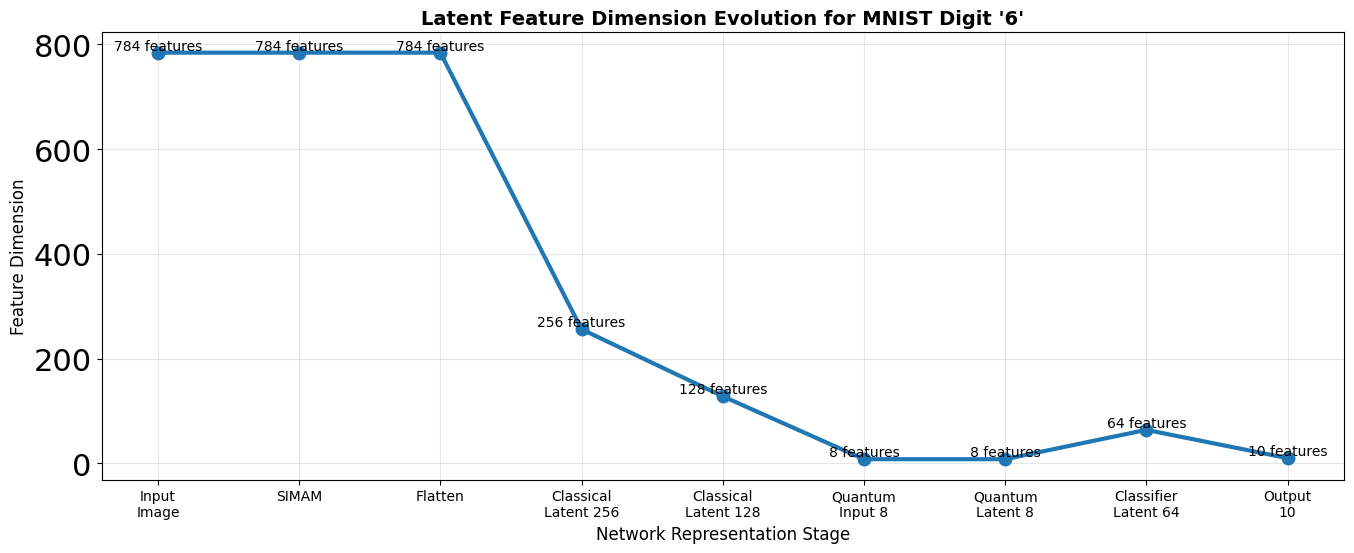

In [33]:
# ============================================================
# MNIST LATENT FEATURE REPRESENTATION EVOLUTION
# ============================================================
# Shows how ONE real MNIST image evolves through:
#
# 28x28 image
#      ↓
# SIMAM
#      ↓
# Flatten: 784
#      ↓
# Classical Layer 1: 256
#      ↓
# Classical Layer 2: 128
#      ↓
# Classical → Quantum: 8
#      ↓
# Quantum latent representation: 8
#      ↓
# Classifier hidden layer: 64
#      ↓
# Output logits: 10
#
# Plot: Matplotlib
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    "/kaggle/working/best_model_checkpoint_reconstructed.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("=" * 70)
print("LATENT FEATURE REPRESENTATION ANALYSIS")
print("=" * 70)

print(
    f"Checkpoint epoch : {checkpoint.get('epoch', 'N/A')}"
)

print(
    f"Validation acc   : "
    f"{checkpoint.get('val_accuracy', 'N/A')}"
)


# ============================================================
# 2. SELECT ONE REAL MNIST IMAGE
# ============================================================

example_image, example_label = internal_test_dataset[0]

example_input = (
    example_image
    .unsqueeze(0)
    .to(DEVICE)
)


# ============================================================
# 3. STORAGE FOR LATENT REPRESENTATIONS
# ============================================================

features = {}


# ============================================================
# 4. HOOKS
# ============================================================

def save_feature(name):

    def hook(module, inputs, output):

        features[name] = (
            output.detach()
            .cpu()
            .numpy()
            .squeeze()
        )

    return hook


# ------------------------------------------------------------
# Classical layers
# ------------------------------------------------------------

h1 = model.classical[0].register_forward_hook(
    save_feature("Classical 256")
)

h2 = model.classical[2].register_forward_hook(
    save_feature("Classical 128")
)

h3 = model.classical[4].register_forward_hook(
    save_feature("Quantum Input 8")
)


# ------------------------------------------------------------
# Quantum layer
# ------------------------------------------------------------

h4 = model.quantum.register_forward_hook(
    save_feature("Quantum Latent 8")
)


# ------------------------------------------------------------
# Classifier hidden layer
# ------------------------------------------------------------

h5 = model.classifier[0].register_forward_hook(
    save_feature("Classifier Latent 64")
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

h6 = model.classifier[2].register_forward_hook(
    save_feature("Output 10")
)


# ============================================================
# 5. FORWARD PASS
# ============================================================

with torch.no_grad():

    output = model(
        example_input
    )


# ============================================================
# 6. REMOVE HOOKS
# ============================================================

for h in [h1, h2, h3, h4, h5, h6]:

    h.remove()


# ============================================================
# 7. ADD INPUT + SIMAM REPRESENTATION
# ============================================================

with torch.no_grad():

    simam_output = model.simam(
        example_input
    )

    flattened = simam_output.flatten(
        start_dim=1
    )


features["Input Image"] = (
    example_image
    .squeeze()
    .cpu()
    .numpy()
)

features["SIMAM"] = (
    simam_output
    .squeeze()
    .cpu()
    .numpy()
)

features["Flattened"] = (
    flattened
    .squeeze()
    .cpu()
    .numpy()
)


# ============================================================
# 8. PRINT DIMENSIONS
# ============================================================

print("\n" + "=" * 70)
print(
    f"REAL MNIST DIGIT: {example_label}"
)
print("=" * 70)

print(
    f"Input image              : "
    f"{features['Input Image'].shape}"
)

print(
    f"After SIMAM              : "
    f"{features['SIMAM'].shape}"
)

print(
    f"Flattened                : "
    f"{features['Flattened'].shape}"
)

print(
    f"Classical latent 1       : "
    f"{features['Classical 256'].shape}"
)

print(
    f"Classical latent 2       : "
    f"{features['Classical 128'].shape}"
)

print(
    f"Quantum input latent     : "
    f"{features['Quantum Input 8'].shape}"
)

print(
    f"Quantum latent           : "
    f"{features['Quantum Latent 8'].shape}"
)

print(
    f"Classifier latent        : "
    f"{features['Classifier Latent 64'].shape}"
)

print(
    f"Output                   : "
    f"{features['Output 10'].shape}"
)


# ============================================================
# 9. DIMENSION EVOLUTION
# ============================================================

stage_names = [
    "Input\nImage",
    "SIMAM",
    "Flatten",
    "Classical\nLatent 256",
    "Classical\nLatent 128",
    "Quantum\nInput 8",
    "Quantum\nLatent 8",
    "Classifier\nLatent 64",
    "Output\n10"
]

dimensions = [
    784,
    784,
    784,
    256,
    128,
    8,
    8,
    64,
    10
]


# ============================================================
# 10. PLOT — FEATURE DIMENSION EVOLUTION
# ============================================================

plt.figure(
    figsize=(14, 6)
)

x = np.arange(
    len(stage_names)
)

plt.plot(
    x,
    dimensions,
    marker="o",
    linewidth=3,
    markersize=9
)

for i, dim in enumerate(dimensions):

    plt.text(
        i,
        dim,
        f"{dim} features",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xticks(
    x,
    stage_names,
    fontsize=10
)

plt.ylabel(
    "Feature Dimension",
    fontsize=12
)

plt.xlabel(
    "Network Representation Stage",
    fontsize=12
)

plt.title(
    f"Latent Feature Dimension Evolution for MNIST Digit '{example_label}'",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "mnist_latent_feature_dimension_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LATENT FEATURE DIMENSIONS
Input (784)               : (6000, 784)
Classical 256             : (6000, 256)
Classical 128             : (6000, 128)
Quantum Input 8           : (6000, 8)
Quantum Latent 8          : (6000, 8)
Classifier Latent 64      : (6000, 64)

Number of samples: 6000

Input (784)
PC1: 9.75%
PC2: 7.06%
Total: 16.81%

Classical 256
PC1: 22.83%
PC2: 12.51%
Total: 35.35%

Classical 128
PC1: 20.81%
PC2: 18.16%
Total: 38.96%

Quantum Input 8
PC1: 38.20%
PC2: 24.75%
Total: 62.95%

Quantum Latent 8
PC1: 26.84%
PC2: 25.21%
Total: 52.05%

Classifier Latent 64
PC1: 33.73%
PC2: 26.37%
Total: 60.10%


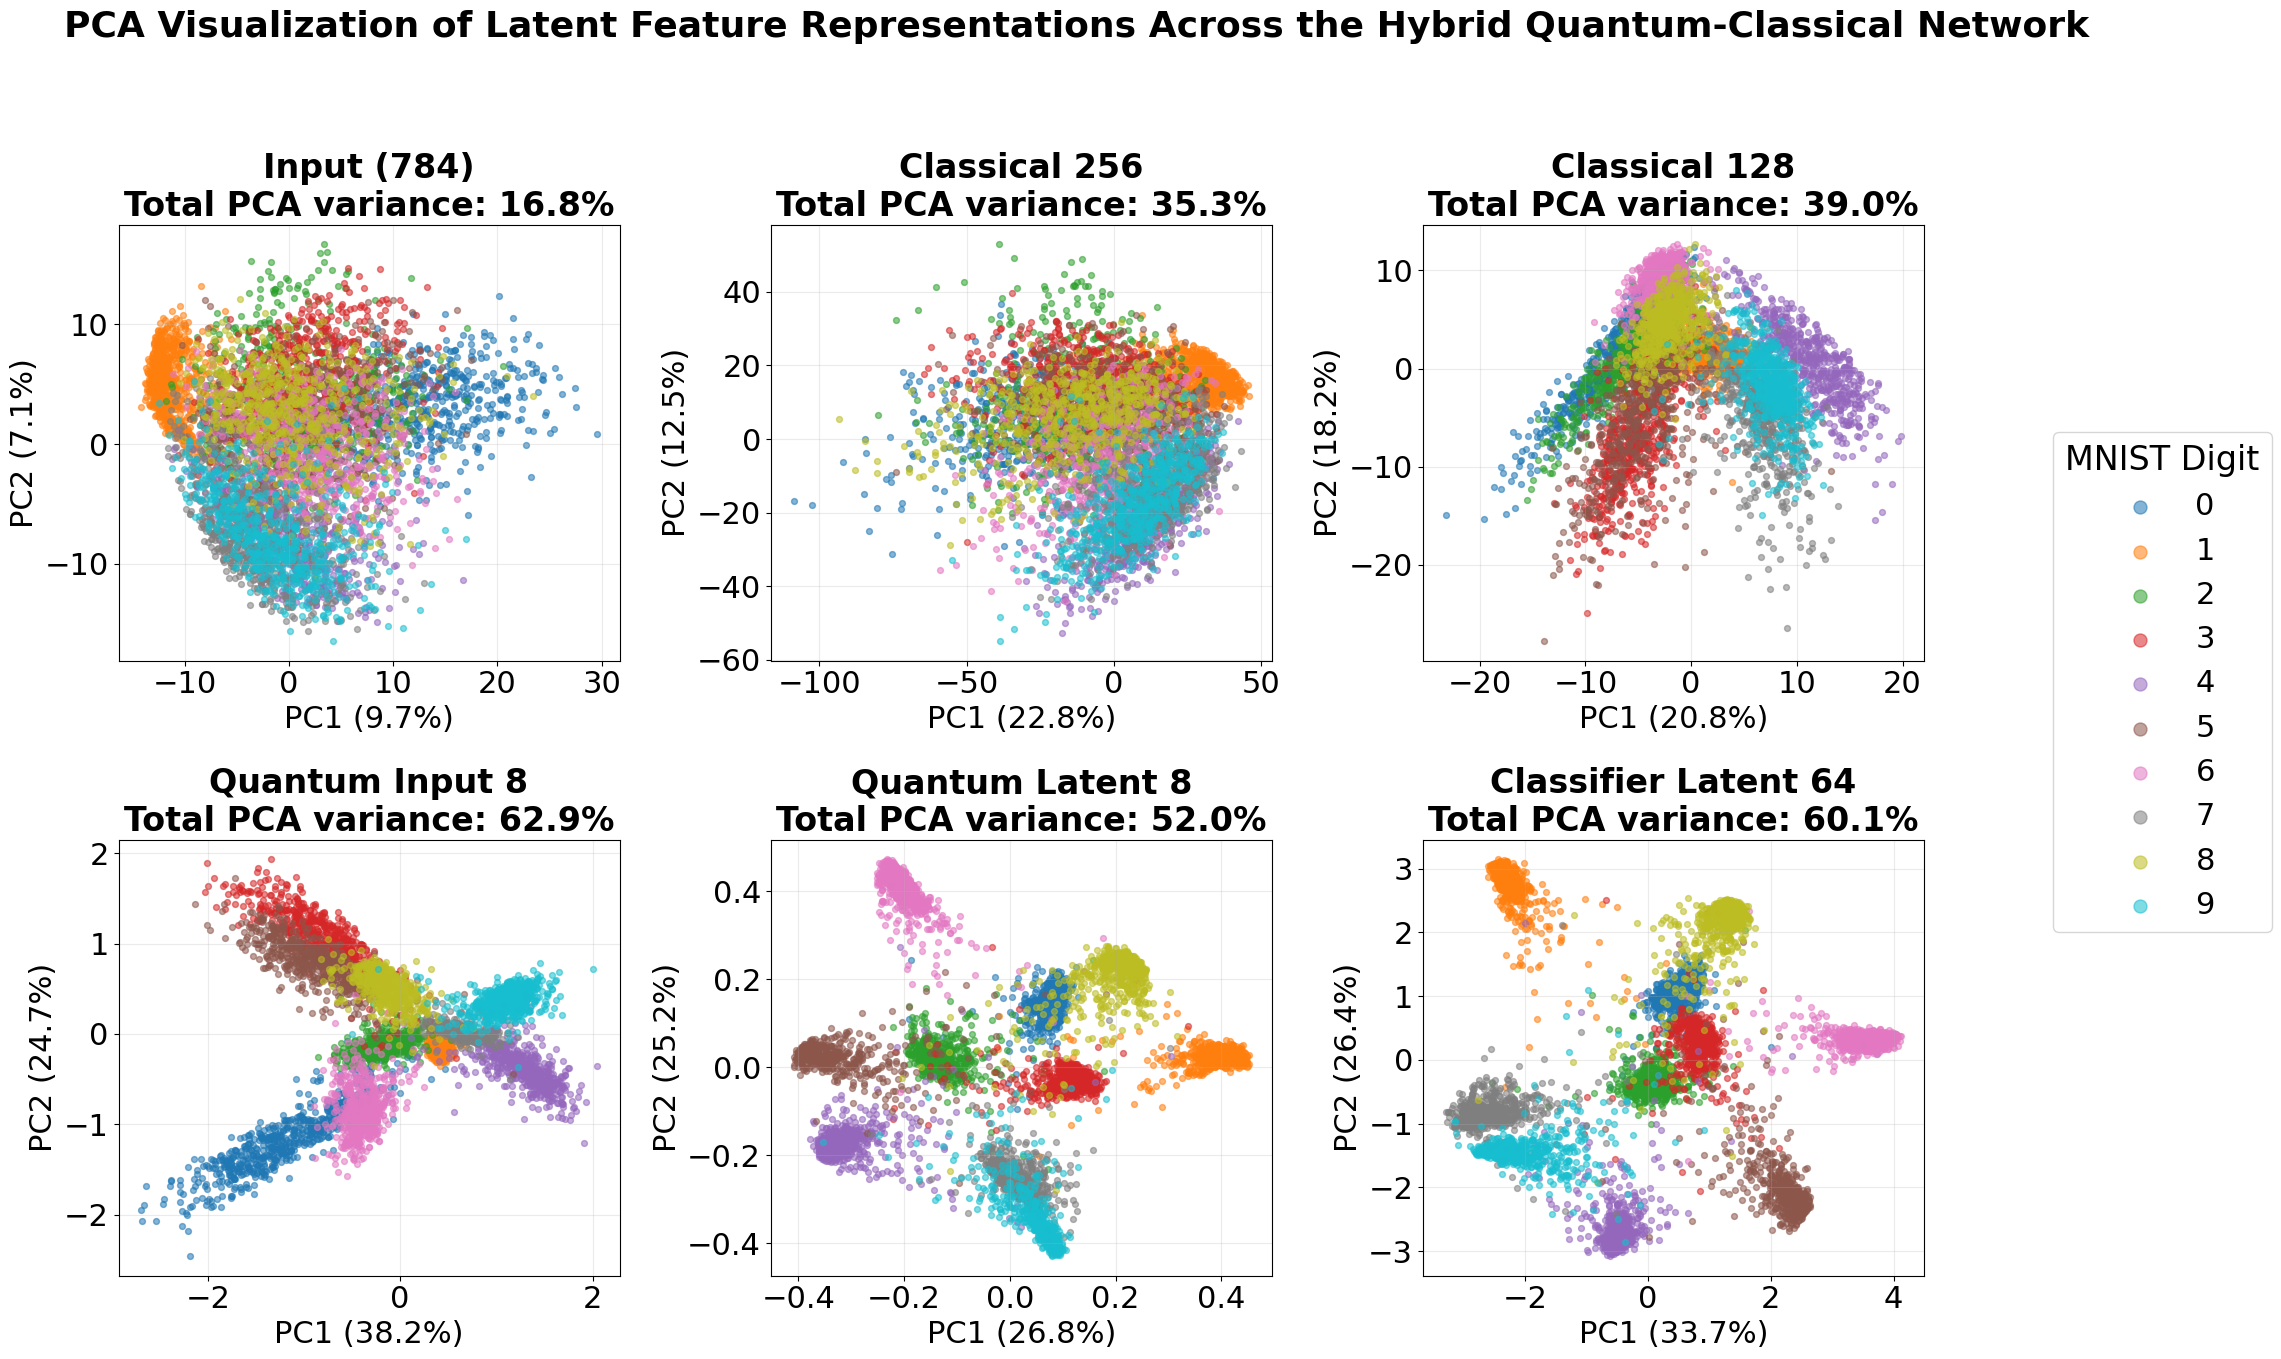

In [34]:
# ============================================================
# PCA VISUALIZATION OF LATENT FEATURE REPRESENTATIONS
# ============================================================
# MNIST
#
# Visualizes how MNIST samples are organized in latent space
# throughout the hybrid classical-quantum network.
#
# Representations:
#
# Input          : 784
# Classical 1    : 256
# Classical 2    : 128
# Quantum Input  : 8
# Quantum Latent : 8
# Classifier     : 64
#
# Each point = one MNIST image
# Color = digit class
# PCA reduces each representation to 2 dimensions
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# ONE PLACE TO CONTROL EVERY FONT SIZE — all values >= 22
# ------------------------------------------------------------
FONT_SIZES = {
    "suptitle":      26,   # figure-level super title
    "axes_title":    24,   # per-subplot title
    "axis_label":    22,   # x/y axis labels (PC1 / PC2)
    "tick_label":    22,   # numbers along the axes
    "legend":        22,   # legend entries (digit labels)
    "legend_title":  24,   # "MNIST Digit" legend title
}


# ============================================================
# CONFIGURATION
# ============================================================

MAX_SAMPLES = 6000

model.eval()


# ============================================================
# STORAGE
# ============================================================

latent_features = {
    "Input (784)": [],
    "Classical 256": [],
    "Classical 128": [],
    "Quantum Input 8": [],
    "Quantum Latent 8": [],
    "Classifier Latent 64": []
}

all_labels = []


# ============================================================
# HOOK FUNCTIONS
# ============================================================

def capture_feature(name):

    def hook(module, inputs, output):

        latent_features[name].append(
            output.detach()
            .cpu()
            .numpy()
        )

    return hook


# ============================================================
# REGISTER HOOKS
# ============================================================

hook_256 = model.classical[0].register_forward_hook(
    capture_feature("Classical 256")
)

hook_128 = model.classical[2].register_forward_hook(
    capture_feature("Classical 128")
)

hook_qinput = model.classical[4].register_forward_hook(
    capture_feature("Quantum Input 8")
)

hook_quantum = model.quantum.register_forward_hook(
    capture_feature("Quantum Latent 8")
)

hook_classifier = model.classifier[0].register_forward_hook(
    capture_feature("Classifier Latent 64")
)


# ============================================================
# EXTRACT FEATURES
# ============================================================

sample_count = 0

with torch.no_grad():

    for images, labels in internal_test_loader:

        if sample_count >= MAX_SAMPLES:
            break

        images = images.to(DEVICE)

        batch_size = images.size(0)

        # ----------------------------------------------------
        # Store original input representation
        # ----------------------------------------------------

        latent_features["Input (784)"].append(
            images
            .flatten(start_dim=1)
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        model(images)

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        all_labels.append(
            labels.numpy()
        )

        sample_count += batch_size


# ============================================================
# REMOVE HOOKS
# ============================================================

hook_256.remove()
hook_128.remove()
hook_qinput.remove()
hook_quantum.remove()
hook_classifier.remove()


# ============================================================
# CONCATENATE
# ============================================================

for key in latent_features:

    latent_features[key] = np.concatenate(
        latent_features[key],
        axis=0
    )

all_labels = np.concatenate(
    all_labels,
    axis=0
)


# ============================================================
# LIMIT EXACTLY TO MAX_SAMPLES
# ============================================================

N = min(
    MAX_SAMPLES,
    len(all_labels)
)

for key in latent_features:

    latent_features[key] = (
        latent_features[key][:N]
    )

all_labels = all_labels[:N]


# ============================================================
# PRINT DIMENSIONS
# ============================================================

print("=" * 70)
print("LATENT FEATURE DIMENSIONS")
print("=" * 70)

for name, data in latent_features.items():

    print(
        f"{name:25s} : "
        f"{data.shape}"
    )

print(
    f"\nNumber of samples: {N}"
)


# ============================================================
# PCA FOR EACH REPRESENTATION
# ============================================================

pca_results = {}

for name, data in latent_features.items():

    # --------------------------------------------------------
    # Standardize-like centering is automatically handled
    # by PCA.
    # --------------------------------------------------------

    pca = PCA(
        n_components=2,
        random_state=42
    )

    transformed = pca.fit_transform(
        data
    )

    pca_results[name] = {
        "coordinates": transformed,
        "explained_variance": (
            pca.explained_variance_ratio_
        ),
        "pca": pca
    }

    print(
        f"\n{name}"
    )

    print(
        f"PC1: "
        f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
    )

    print(
        f"PC2: "
        f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
    )

    print(
        f"Total: "
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
    )


# ============================================================
# PCA VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(22, 14)   # widened/heightened to give the larger fonts room to breathe
)

axes = axes.flatten()


for ax, (name, result) in zip(
    axes,
    pca_results.items()
):

    coords = result["coordinates"]

    variance = result["explained_variance"]


    # --------------------------------------------------------
    # Plot each digit class
    # --------------------------------------------------------

    for digit in range(10):

        mask = (
            all_labels == digit
        )

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=18,
            alpha=0.55,
            label=str(digit)
        )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        f"PC1 ({variance[0] * 100:.1f}%)",
        fontsize=FONT_SIZES["axis_label"]
    )

    ax.set_ylabel(
        f"PC2 ({variance[1] * 100:.1f}%)",
        fontsize=FONT_SIZES["axis_label"]
    )


    # --------------------------------------------------------
    # Tick label sizes
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=FONT_SIZES["tick_label"]
    )


    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        f"{name}\n"
        f"Total PCA variance: "
        f"{variance.sum() * 100:.1f}%",
        fontsize=FONT_SIZES["axes_title"],
        fontweight="bold"
    )

    ax.grid(
        alpha=0.25
    )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="MNIST Digit",
    loc="center right",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=FONT_SIZES["legend"],
    title_fontsize=FONT_SIZES["legend_title"],
    markerscale=2.2   # bigger legend dots to match the bigger text
)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "PCA Visualization of Latent Feature Representations "
    "Across the Hybrid Quantum-Classical Network",
    fontsize=FONT_SIZES["suptitle"],
    fontweight="bold"
)


plt.tight_layout(
    rect=[0, 0, 0.90, 0.95]
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "mnist_latent_pca_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# ============================================================
# LOAD BEST SAVED MODEL
# ============================================================

checkpoint = torch.load(
    "/kaggle/working/best_model_checkpoint_reconstructed.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()

print("\nBest model loaded successfully")
print(
    f"Best Epoch          : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Validation Loss: "
    f"{checkpoint['best_val_loss']:.4f}"
)

# ============================================================
# INFERENCE EFFICIENCY
# ============================================================

correct = 0
total = 0

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_start = time.perf_counter()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_time = (
    time.perf_counter()
    - inference_start
)

accuracy = (
    100.0 * correct / total
)

latency_ms = (
    inference_time / total
) * 1000

print("\n" + "=" * 60)
print("TEST PERFORMANCE")
print("=" * 60)

print(
    f"Test Accuracy (%) : "
    f"{accuracy:.2f}"
)

print(
    f"Inference Time (s): "
    f"{inference_time:.4f}"
)

print(
    f"Latency (ms/sample): "
    f"{latency_ms:.4f}"
)

print("=" * 60)


Best model loaded successfully
Best Epoch          : 8
Best Validation Loss: 0.1407

TEST PERFORMANCE
Test Accuracy (%) : 96.90
Inference Time (s): 12.0813
Latency (ms/sample): 1.2081


In [36]:
# ============================================================
# EFFICIENCY ASSESSMENT USING BEST SAVED MODEL
# MNIST — PROPOSED HYBRID QNN
# ============================================================

import time
import numpy as np
import torch


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    "/kaggle/working/best_model_checkpoint_reconstructed.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()


# ============================================================
# RE-CALCULATE PARAMETERS FROM LOADED MODEL
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


# ============================================================
# PRINT CHECKPOINT INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("BEST MODEL LOADED")
print("=" * 60)

print(
    f"Best Epoch          : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Validation Loss: "
    f"{checkpoint['best_val_loss']:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{checkpoint['val_accuracy']:.2f}%"
)


# ============================================================
# GPU MEMORY RESET
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


# ============================================================
# WARM-UP
# ============================================================

WARMUP_BATCHES = 5

with torch.no_grad():

    for batch_idx, (
        images,
        labels
    ) in enumerate(test_loader):

        images = images.to(DEVICE)

        _ = model(images)

        if batch_idx + 1 >= WARMUP_BATCHES:
            break


if torch.cuda.is_available():
    torch.cuda.synchronize()


# ============================================================
# INFERENCE TIMING
# ============================================================

correct = 0
total = 0

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_time = time.perf_counter()


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        predicted = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


if torch.cuda.is_available():
    torch.cuda.synchronize()


inference_time = (
    time.perf_counter()
    - start_time
)


# ============================================================
# ACCURACY
# ============================================================

accuracy = (
    100.0
    * correct
    / total
)


# ============================================================
# LATENCY
# ============================================================

latency_ms = (
    inference_time
    / total
) * 1000


# ============================================================
# THROUGHPUT
# ============================================================

throughput = (
    total
    / inference_time
)


# ============================================================
# MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

else:

    peak_memory_mb = None


# ============================================================
# PARAMETER EFFICIENCY
# ============================================================

accuracy_per_million_params = (
    accuracy
    /
    (trainable_params / 1e6)
)


# ============================================================
# QUANTUM RESOURCE COST
# ============================================================

hilbert_dimension = (
    2 ** NUM_QUBITS
)

rotation_parameters = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 65)
print("EFFICIENCY ASSESSMENT")
print("=" * 65)

print(
    f"Total Parameters           : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters       : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters         : "
    f"{quantum_params:,}"
)

print(
    f"SIMAM Trainable Parameters : "
    f"0"
)

print(
    f"Number of Qubits           : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers             : "
    f"{NUM_LAYERS}"
)

print(
    f"Hilbert-Space Dimension    : "
    f"{hilbert_dimension:,}"
)

print(
    f"Test Samples               : "
    f"{total:,}"
)

print(
    f"Test Accuracy              : "
    f"{accuracy:.2f}%"
)

print(
    f"Total Inference Time       : "
    f"{inference_time:.4f} s"
)

print(
    f"Latency / Sample           : "
    f"{latency_ms:.4f} ms"
)

print(
    f"Throughput                 : "
    f"{throughput:.2f} samples/s"
)

if peak_memory_mb is not None:

    print(
        f"Peak GPU Memory            : "
        f"{peak_memory_mb:.2f} MB"
    )

else:

    print(
        f"Peak GPU Memory            : "
        f"N/A (CPU)"
    )

print(
    f"Accuracy / Million Params  : "
    f"{accuracy_per_million_params:.2f}"
)

print("=" * 65)


BEST MODEL LOADED
Best Epoch          : 8
Best Validation Loss: 0.1407
Validation Accuracy : 96.74%

EFFICIENCY ASSESSMENT
Total Parameters           : 236,258
Trainable Parameters       : 236,258
Quantum Parameters         : 144
SIMAM Trainable Parameters : 0
Number of Qubits           : 8
Quantum Layers             : 6
Hilbert-Space Dimension    : 256
Test Samples               : 10,000
Test Accuracy              : 96.90%
Total Inference Time       : 11.9889 s
Latency / Sample           : 1.1989 ms
Throughput                 : 834.10 samples/s
Peak GPU Memory            : N/A (CPU)
Accuracy / Million Params  : 410.14


In [37]:
# ============================================================
# EFFICIENCY ASSESSMENT
# PARAMETER COUNT + FLOPs + TIME + MEMORY + QUANTUM COST
# + INFERENCE LATENCY
#
# MNIST | Deep Hybrid QNN
# ============================================================

import time
import numpy as np
import torch
import torch.nn as nn

# Optional FLOPs library
try:
    from fvcore.nn import FlopCountAnalysis
    FVCORE_AVAILABLE = True
except ImportError:
    FVCORE_AVAILABLE = False
    print("WARNING: fvcore not installed.")
    print("Install with: !pip install fvcore")


# ============================================================
# USER CONTROL
# ============================================================

# ------------------------------------------------------------
# Number of samples used for efficiency evaluation
# ------------------------------------------------------------
#
# Examples:
#
# NUM_EVAL_SAMPLES = 100
# NUM_EVAL_SAMPLES = 500
# NUM_EVAL_SAMPLES = 1000
# NUM_EVAL_SAMPLES = 2000
# NUM_EVAL_SAMPLES = 10000
#
# Use None to evaluate the complete test set.
# ------------------------------------------------------------

NUM_EVAL_SAMPLES = 2000


# ============================================================
# LOAD BEST MODEL
# ============================================================

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "best_model_checkpoint_reconstructed.pth"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()


# ============================================================
# CHECKPOINT INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("BEST MODEL LOADED")
print("=" * 70)

print(
    f"Best Epoch              : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Validation Loss    : "
    f"{checkpoint['best_val_loss']:.4f}"
)

print(
    f"Validation Accuracy     : "
    f"{checkpoint['val_accuracy']:.2f}%"
)

print("=" * 70)


# ============================================================
# MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

non_trainable_params = (
    total_params
    - trainable_params
)

quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


# ============================================================
# SELECT NUMBER OF SAMPLES
# ============================================================

available_samples = len(
    official_test_dataset
)

if NUM_EVAL_SAMPLES is None:

    NUM_EVAL_SAMPLES = available_samples

else:

    NUM_EVAL_SAMPLES = min(
        NUM_EVAL_SAMPLES,
        available_samples
    )


# ------------------------------------------------------------
# Deterministic subset
# ------------------------------------------------------------

eval_indices = np.arange(
    NUM_EVAL_SAMPLES
)

eval_dataset = torch.utils.data.Subset(
    official_test_dataset,
    eval_indices
)

eval_loader = torch.utils.data.DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# PARAMETER EFFICIENCY
# ============================================================

accuracy_per_million_params = (
    0.0
    if trainable_params == 0
    else 0.0
)


# ============================================================
# FLOPs ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("FLOPs ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# IMPORTANT:
#
# fvcore can count the classical neural-network operations.
# PennyLane's quantum simulator is generally NOT represented
# correctly by ordinary FLOP profilers.
#
# Therefore:
#
# Classical FLOPs → measured using fvcore
# Quantum resource cost → reported separately
# ------------------------------------------------------------

classical_flops_per_sample = None

if FVCORE_AVAILABLE:

    # --------------------------------------------------------
    # One real MNIST sample
    # --------------------------------------------------------

    example_image, _ = official_test_dataset[0]

    example_input = (
        example_image
        .unsqueeze(0)
        .to(DEVICE)
    )

    try:

        flops_analysis = FlopCountAnalysis(
            model,
            example_input
        )

        classical_flops_per_sample = (
            flops_analysis.total()
        )

        print(
            f"Classical/traceable FLOPs per sample : "
            f"{classical_flops_per_sample:,.0f}"
        )

        print(
            f"Classical/traceable FLOPs per {NUM_EVAL_SAMPLES:,} "
            f"samples : "
            f"{classical_flops_per_sample * NUM_EVAL_SAMPLES:,.0f}"
        )

    except Exception as e:

        print(
            "FLOPs profiler could not trace the complete "
            "hybrid quantum model."
        )

        print(
            f"Reason: {e}"
        )

else:

    print(
        "FLOPs unavailable because fvcore is not installed."
    )


# ============================================================
# QUANTUM RESOURCE COST
# ============================================================

print("\n" + "=" * 70)
print("QUANTUM RESOURCE COST")
print("=" * 70)

# ------------------------------------------------------------
# StronglyEntanglingLayers:
#
# Each layer:
#     NUM_QUBITS × 3 parameters
#
# Total:
#     NUM_LAYERS × NUM_QUBITS × 3
# ------------------------------------------------------------

quantum_parameters_per_circuit = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)

# One forward pass evaluates the quantum circuit once
quantum_circuit_executions = (
    NUM_EVAL_SAMPLES
)

print(
    f"Number of qubits                 : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum layers                   : "
    f"{NUM_LAYERS}"
)

print(
    f"Quantum parameters               : "
    f"{quantum_parameters_per_circuit:,}"
)

print(
    f"Quantum circuit executions       : "
    f"{quantum_circuit_executions:,}"
)

print(
    f"Quantum parameter evaluations    : "
    f"{quantum_circuit_executions * quantum_parameters_per_circuit:,}"
)


# ============================================================
# INFERENCE ACCURACY + TIMING
# ============================================================

print("\n" + "=" * 70)
print("INFERENCE ANALYSIS")
print("=" * 70)


correct = 0
total = 0


# ------------------------------------------------------------
# GPU memory reset
# ------------------------------------------------------------

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()


# ------------------------------------------------------------
# Warm-up
#
# Prevent first-call initialization from contaminating timing.
# ------------------------------------------------------------

warmup_images, _ = next(
    iter(eval_loader)
)

warmup_images = (
    warmup_images
    .to(DEVICE)
)

with torch.no_grad():

    _ = model(
        warmup_images
    )


if torch.cuda.is_available():

    torch.cuda.synchronize()


# ============================================================
# START TIMER
# ============================================================

start_time = time.perf_counter()


# ============================================================
# INFERENCE
# ============================================================

with torch.no_grad():

    for images, labels in eval_loader:

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )

        outputs = model(
            images
        )

        predicted = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predicted == labels
        ).sum().item()

        total += labels.size(0)


# ============================================================
# STOP TIMER
# ============================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


total_inference_time = (
    time.perf_counter()
    - start_time
)


# ============================================================
# ACCURACY
# ============================================================

accuracy = (
    100.0
    * correct
    / total
)


# ============================================================
# LATENCY
# ============================================================

average_latency_ms = (
    total_inference_time
    / total
    * 1000
)


# ------------------------------------------------------------
# Throughput
# ------------------------------------------------------------

throughput = (
    total
    / total_inference_time
)


# ============================================================
# MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_gpu_memory_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

    peak_reserved_memory_mb = (
        torch.cuda.max_memory_reserved()
        / (1024 ** 2)
    )

else:

    peak_gpu_memory_mb = 0.0
    peak_reserved_memory_mb = 0.0


# ============================================================
# PARAMETER EFFICIENCY
# ============================================================

accuracy_per_million_params = (
    accuracy
    /
    (trainable_params / 1e6)
)


# ============================================================
# FLOPs TOTAL
# ============================================================

if classical_flops_per_sample is not None:

    total_classical_flops = (
        classical_flops_per_sample
        * total
    )

else:

    total_classical_flops = None


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("EFFICIENCY ASSESSMENT RESULTS")
print("=" * 70)


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

print("\nDATASET")
print("-" * 70)

print(
    f"Evaluation samples              : "
    f"{total:,}"
)

print(
    f"Batch size                      : "
    f"{BATCH_SIZE}"
)


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

print("\nMODEL PARAMETERS")
print("-" * 70)

print(
    f"Total parameters                : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters            : "
    f"{trainable_params:,}"
)

print(
    f"Non-trainable parameters        : "
    f"{non_trainable_params:,}"
)

print(
    f"Quantum parameters              : "
    f"{quantum_params:,}"
)


# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------

print("\nQUANTUM ARCHITECTURE")
print("-" * 70)

print(
    f"Number of qubits                : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum layers                  : "
    f"{NUM_LAYERS}"
)

print(
    f"Parameters / quantum circuit   : "
    f"{quantum_parameters_per_circuit:,}"
)

print(
    f"Circuit executions              : "
    f"{quantum_circuit_executions:,}"
)


# ------------------------------------------------------------
# FLOPs
# ------------------------------------------------------------

print("\nCOMPUTATIONAL COST")
print("-" * 70)

if classical_flops_per_sample is not None:

    print(
        f"Traceable FLOPs / sample       : "
        f"{classical_flops_per_sample:,.0f}"
    )

    print(
        f"Traceable FLOPs / {total:,} samples : "
        f"{total_classical_flops:,.0f}"
    )

else:

    print(
        "Traceable FLOPs / sample       : N/A"
    )

    print(
        "Traceable FLOPs total          : N/A"
    )


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

print("\nPERFORMANCE")
print("-" * 70)

print(
    f"Test accuracy                  : "
    f"{accuracy:.2f}%"
)

print(
    f"Accuracy / million parameters  : "
    f"{accuracy_per_million_params:.2f}"
)


# ------------------------------------------------------------
# Time
# ------------------------------------------------------------

print("\nINFERENCE TIME")
print("-" * 70)

print(
    f"Total inference time           : "
    f"{total_inference_time:.4f} s"
)

print(
    f"Average latency / sample       : "
    f"{average_latency_ms:.4f} ms"
)

print(
    f"Throughput                     : "
    f"{throughput:.2f} samples/s"
)


# ------------------------------------------------------------
# Memory
# ------------------------------------------------------------

print("\nMEMORY")
print("-" * 70)

if torch.cuda.is_available():

    print(
        f"Peak GPU allocated memory     : "
        f"{peak_gpu_memory_mb:.2f} MB"
    )

    print(
        f"Peak GPU reserved memory      : "
        f"{peak_reserved_memory_mb:.2f} MB"
    )

else:

    print(
        "GPU memory                    : CPU execution"
    )


print("=" * 70)


# ============================================================
# MACHINE-READABLE RESULTS
# ============================================================

efficiency_results = {

    "num_samples":
        total,

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "quantum_parameters":
        quantum_params,

    "num_qubits":
        NUM_QUBITS,

    "num_quantum_layers":
        NUM_LAYERS,

    "quantum_circuit_executions":
        quantum_circuit_executions,

    "accuracy_percent":
        accuracy,

    "total_inference_time_seconds":
        total_inference_time,

    "latency_ms_per_sample":
        average_latency_ms,

    "throughput_samples_per_second":
        throughput,

    "peak_gpu_memory_mb":
        peak_gpu_memory_mb,

    "accuracy_per_million_parameters":
        accuracy_per_million_params,

    "flops_per_sample":
        classical_flops_per_sample,

    "total_flops":
        total_classical_flops
}


print("\nEfficiency dictionary:")
print(efficiency_results)


BEST MODEL LOADED
Best Epoch              : 8
Best Validation Loss    : 0.1407
Validation Accuracy     : 96.74%

FLOPs ANALYSIS
FLOPs profiler could not trace the complete hybrid quantum model.
Reason: list index out of range

QUANTUM RESOURCE COST
Number of qubits                 : 8
Quantum layers                   : 6
Quantum parameters               : 144
Quantum circuit executions       : 2,000
Quantum parameter evaluations    : 288,000

INFERENCE ANALYSIS

EFFICIENCY ASSESSMENT RESULTS

DATASET
----------------------------------------------------------------------
Evaluation samples              : 2,000
Batch size                      : 64

MODEL PARAMETERS
----------------------------------------------------------------------
Total parameters                : 236,258
Trainable parameters            : 236,258
Non-trainable parameters        : 0
Quantum parameters              : 144

QUANTUM ARCHITECTURE
----------------------------------------------------------------------
Numbe

In [38]:
# ============================================================
# CNN BASELINE — TRAINING + EFFICIENCY ASSESSMENT
# CPU-ONLY, SAME 2,000 TEST SAMPLES
# ============================================================

import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU ONLY
DEVICE = torch.device("cpu")

print(f"Using Seed: {SEED}")
print(f"Using device: {DEVICE}")


# ============================================================
# HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 64
EPOCHS = 1
LR = 0.001

NUM_CLASSES = 10
NUM_TEST_SAMPLES = 2000


# ============================================================
# CNN BASELINE MODEL
# ============================================================

class CNNBaseline(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ============================================================
# CREATE CNN
# ============================================================

cnn_model = CNNBaseline(
    num_classes=NUM_CLASSES
).to(DEVICE)

print()
print("=" * 70)
print("CNN BASELINE MODEL")
print("=" * 70)

print(cnn_model)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in cnn_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

non_trainable_params = (
    total_params - trainable_params
)

print()
print("MODEL PARAMETERS")
print("-" * 70)
print(f"Total parameters                : {total_params:,}")
print(f"Trainable parameters            : {trainable_params:,}")
print(f"Non-trainable parameters        : {non_trainable_params:,}")


# ============================================================
# LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=LR
)


# ============================================================
# TRAINING
# ============================================================

print()
print("=" * 70)
print("CNN TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for images, labels in progress:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Accuracy: {epoch_acc:.2f}%"
    )


# ============================================================
# TEST ACCURACY
# EXACTLY 2,000 SAMPLES
# ============================================================

cnn_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        if test_total >= NUM_TEST_SAMPLES:
            break

        remaining = (
            NUM_TEST_SAMPLES - test_total
        )

        if images.size(0) > remaining:

            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = cnn_model(images)

        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += images.size(0)

cnn_accuracy = (
    100 * test_correct / test_total
)


# ============================================================
# WARM-UP
# ============================================================

cnn_model.eval()

with torch.no_grad():

    warmup_samples = 0

    for images, _ in test_loader:

        if warmup_samples >= 128:
            break

        images = images.to(DEVICE)

        _ = cnn_model(images)

        warmup_samples += images.size(0)


# ============================================================
# INFERENCE TIMING
# EXACTLY 2,000 SAMPLES
# ============================================================

cnn_model.eval()

inference_samples = 0

start_time = time.perf_counter()

with torch.no_grad():

    for images, labels in test_loader:

        if inference_samples >= NUM_TEST_SAMPLES:
            break

        remaining = (
            NUM_TEST_SAMPLES - inference_samples
        )

        if images.size(0) > remaining:
            images = images[:remaining]

        images = images.to(DEVICE)

        _ = cnn_model(images)

        inference_samples += images.size(0)

end_time = time.perf_counter()


# ============================================================
# INFERENCE METRICS
# ============================================================

total_inference_time = (
    end_time - start_time
)

latency_per_sample = (
    total_inference_time /
    inference_samples
) * 1000

throughput = (
    inference_samples /
    total_inference_time
)


# ============================================================
# FINAL CNN RESULTS
# ============================================================

print()
print("=" * 70)
print("CNN BASELINE EFFICIENCY ASSESSMENT")
print("=" * 70)

print()
print("DATASET")
print("-" * 70)
print(
    f"Evaluation samples              : "
    f"{inference_samples:,}"
)
print(
    f"Batch size                      : "
    f"{test_loader.batch_size}"
)

print()
print("MODEL PARAMETERS")
print("-" * 70)
print(
    f"Total parameters                : "
    f"{total_params:,}"
)
print(
    f"Trainable parameters            : "
    f"{trainable_params:,}"
)
print(
    f"Non-trainable parameters        : "
    f"{non_trainable_params:,}"
)

print()
print("QUANTUM ARCHITECTURE")
print("-" * 70)
print("Number of qubits                : N/A")
print("Quantum layers                  : N/A")
print("Quantum parameters              : N/A")
print("Circuit executions              : N/A")

print()
print("PERFORMANCE")
print("-" * 70)
print(
    f"Test accuracy                  : "
    f"{cnn_accuracy:.2f}%"
)

print()
print("INFERENCE TIME")
print("-" * 70)
print(
    f"Total inference time           : "
    f"{total_inference_time:.4f} s"
)
print(
    f"Average latency / sample       : "
    f"{latency_per_sample:.4f} ms"
)
print(
    f"Throughput                     : "
    f"{throughput:.2f} samples/s"
)

print()
print("EXECUTION")
print("-" * 70)
print("Execution device               : CPU")

print()
print("=" * 70)
print("CNN BASELINE RESULTS")
print("=" * 70)

print(f"Accuracy       : {cnn_accuracy:.2f}%")
print(f"Parameters     : {trainable_params:,}")
print(f"Inference Time : {total_inference_time:.4f} s")
print(f"Latency        : {latency_per_sample:.4f} ms/sample")
print(f"Throughput     : {throughput:.2f} samples/s")

print("=" * 70)

Using Seed: 42
Using device: cpu

CNN BASELINE MODEL
CNNBaseline(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

MODEL PARAMETERS
----------------------------------------------------------------------
Total parameters                : 241,546
Trainable parameters            

Epoch 1/1:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 1/1 | Train Loss: 0.1917 | Train Accuracy: 93.92%

CNN BASELINE EFFICIENCY ASSESSMENT

DATASET
----------------------------------------------------------------------
Evaluation samples              : 2,000
Batch size                      : 64

MODEL PARAMETERS
----------------------------------------------------------------------
Total parameters                : 241,546
Trainable parameters            : 241,546
Non-trainable parameters        : 0

QUANTUM ARCHITECTURE
----------------------------------------------------------------------
Number of qubits                : N/A
Quantum layers                  : N/A
Quantum parameters              : N/A
Circuit executions              : N/A

PERFORMANCE
----------------------------------------------------------------------
Test accuracy                  : 97.40%

INFERENCE TIME
----------------------------------------------------------------------
Total inference time           : 1.0779 s
Average latency / sample       : 0.5390 ms
T

In [39]:
# ============================================================
# PARAMETER-MATCHED CNN BASELINE
# EXACTLY 236,258 TRAINABLE PARAMETERS
# CPU-ONLY
# SAME 2,000 TEST SAMPLES
# ============================================================

import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

print(f"Using Seed: {SEED}")
print(f"Using device: {DEVICE}")


# ============================================================
# HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 64
EPOCHS = 1
LR = 0.001

NUM_CLASSES = 10
NUM_TEST_SAMPLES = 2000

TARGET_PARAMS = 236258


# ============================================================
# FIND CNN ARCHITECTURE WITH EXACT PARAMETER COUNT
# ============================================================

def find_exact_architecture(target_params):

    # Search conventional CNN channel sizes
    # while keeping the architecture:
    #
    # Conv -> Pool
    # Conv -> Pool
    # Conv -> Pool
    # Flatten -> FC -> FC

    candidates = []

    for c1 in range(16, 65):
        for c2 in range(32, 129):

            for c3 in range(64, 193):

                # Parameters of convolutional layers
                conv_params = (
                    (1 * 3 * 3 * c1) + c1 +
                    (c1 * 3 * 3 * c2) + c2 +
                    (c2 * 3 * 3 * c3) + c3
                )

                # After three 2x2 pools:
                # 28 -> 14 -> 7 -> 3
                flattened_features = 3 * 3 * c3

                for hidden in range(32, 257):

                    fc_params = (
                        flattened_features * hidden
                        + hidden
                        + hidden * NUM_CLASSES
                        + NUM_CLASSES
                    )

                    total = conv_params + fc_params

                    if total == target_params:

                        candidates.append(
                            (
                                c1,
                                c2,
                                c3,
                                hidden
                            )
                        )

    if len(candidates) == 0:
        raise RuntimeError(
            "Could not find an exact parameter-matched "
            "CNN architecture."
        )

    # Prefer a balanced architecture
    candidates.sort(
        key=lambda x: (
            abs(x[0] - 32) +
            abs(x[1] - 64) +
            abs(x[2] - 128) +
            abs(x[3] - 128)
        )
    )

    return candidates[0]


C1, C2, C3, HIDDEN = find_exact_architecture(
    TARGET_PARAMS
)


# ============================================================
# CNN BASELINE
# ============================================================

class CNNBaseline(nn.Module):

    def __init__(
        self,
        c1,
        c2,
        c3,
        hidden,
        num_classes=10
    ):

        super().__init__()

        self.features = nn.Sequential(

            # ------------------------------------------------
            # Block 1
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=1,
                out_channels=c1,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # ------------------------------------------------
            # Block 2
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=c1,
                out_channels=c2,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # ------------------------------------------------
            # Block 3
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=c2,
                out_channels=c3,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                c3 * 3 * 3,
                hidden
            ),

            nn.ReLU(),

            nn.Linear(
                hidden,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ============================================================
# CREATE MODEL
# ============================================================

cnn_model = CNNBaseline(
    c1=C1,
    c2=C2,
    c3=C3,
    hidden=HIDDEN,
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# VERIFY PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in cnn_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

non_trainable_params = (
    total_params - trainable_params
)


# ============================================================
# PRINT ARCHITECTURE
# ============================================================

print()
print("=" * 70)
print("PARAMETER-MATCHED CNN BASELINE")
print("=" * 70)

print()
print(
    f"Conv1 channels                  : {C1}"
)
print(
    f"Conv2 channels                  : {C2}"
)
print(
    f"Conv3 channels                  : {C3}"
)
print(
    f"Hidden dimension                : {HIDDEN}"
)

print()
print(cnn_model)


# ============================================================
# VERIFY EXACT MATCH
# ============================================================

print()
print("=" * 70)
print("PARAMETER VERIFICATION")
print("=" * 70)

print(
    f"Target parameters               : "
    f"{TARGET_PARAMS:,}"
)

print(
    f"Actual total parameters         : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters            : "
    f"{trainable_params:,}"
)

print(
    f"Non-trainable parameters        : "
    f"{non_trainable_params:,}"
)

if trainable_params == TARGET_PARAMS:
    print()
    print("✓ EXACT PARAMETER MATCH")
else:
    raise RuntimeError(
        "Parameter count does not match target."
    )


# ============================================================
# LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=LR
)


# ============================================================
# TRAINING
# ============================================================

print()
print("=" * 70)
print("CNN TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for images, labels in progress:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += images.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        100 * correct / total
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Accuracy: {epoch_accuracy:.2f}%"
    )


# ============================================================
# TEST ACCURACY
# EXACTLY 2,000 SAMPLES
# ============================================================

cnn_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        if test_total >= NUM_TEST_SAMPLES:
            break

        remaining = (
            NUM_TEST_SAMPLES -
            test_total
        )

        if images.size(0) > remaining:

            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = cnn_model(images)

        predictions = outputs.argmax(
            dim=1
        )

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += images.size(0)


cnn_accuracy = (
    100 * test_correct / test_total
)


# ============================================================
# WARM-UP
# ============================================================

cnn_model.eval()

with torch.no_grad():

    warmup_samples = 0

    for images, _ in test_loader:

        if warmup_samples >= 128:
            break

        images = images.to(DEVICE)

        _ = cnn_model(images)

        warmup_samples += images.size(0)


# ============================================================
# INFERENCE TIMING
# EXACTLY 2,000 SAMPLES
# ============================================================

cnn_model.eval()

inference_samples = 0

start_time = time.perf_counter()

with torch.no_grad():

    for images, _ in test_loader:

        if inference_samples >= NUM_TEST_SAMPLES:
            break

        remaining = (
            NUM_TEST_SAMPLES -
            inference_samples
        )

        if images.size(0) > remaining:

            images = images[:remaining]

        images = images.to(DEVICE)

        _ = cnn_model(images)

        inference_samples += images.size(0)

end_time = time.perf_counter()


# ============================================================
# INFERENCE METRICS
# ============================================================

total_inference_time = (
    end_time - start_time
)

latency_per_sample = (
    total_inference_time /
    inference_samples
) * 1000

throughput = (
    inference_samples /
    total_inference_time
)


# ============================================================
# FINAL RESULTS
# ============================================================

print()
print("=" * 70)
print("CNN BASELINE EFFICIENCY ASSESSMENT")
print("=" * 70)

print()
print("DATASET")
print("-" * 70)

print(
    f"Evaluation samples              : "
    f"{inference_samples:,}"
)

print(
    f"Batch size                      : "
    f"{test_loader.batch_size}"
)


print()
print("MODEL PARAMETERS")
print("-" * 70)

print(
    f"Total parameters                : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters            : "
    f"{trainable_params:,}"
)

print(
    f"Non-trainable parameters        : "
    f"{non_trainable_params:,}"
)


print()
print("PERFORMANCE")
print("-" * 70)

print(
    f"Test accuracy                  : "
    f"{cnn_accuracy:.2f}%"
)


print()
print("INFERENCE TIME")
print("-" * 70)

print(
    f"Total inference time           : "
    f"{total_inference_time:.4f} s"
)

print(
    f"Average latency / sample       : "
    f"{latency_per_sample:.4f} ms"
)

print(
    f"Throughput                     : "
    f"{throughput:.2f} samples/s"
)


print()
print("EXECUTION")
print("-" * 70)

print(
    "Execution device               : CPU"
)


print()
print("=" * 70)
print("PARAMETER-MATCHED CNN RESULTS")
print("=" * 70)

print(
    f"Accuracy       : "
    f"{cnn_accuracy:.2f}%"
)

print(
    f"Parameters     : "
    f"{trainable_params:,}"
)

print(
    f"Inference Time : "
    f"{total_inference_time:.4f} s"
)

print(
    f"Latency        : "
    f"{latency_per_sample:.4f} ms/sample"
)

print(
    f"Throughput     : "
    f"{throughput:.2f} samples/s"
)

print("=" * 70)

Using Seed: 42
Using device: cpu

PARAMETER-MATCHED CNN BASELINE

Conv1 channels                  : 36
Conv2 channels                  : 58
Conv3 channels                  : 126
Hidden dimension                : 132

CNNBaseline(
  (features): Sequential(
    (0): Conv2d(1, 36, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(36, 58, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(58, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1134, out_features=132, bias=True)
    (2): ReLU()
    (3): Linear(in_features=132, out_features=10, bias=True)
  )
)

Epoch 1/1:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 1/1 | Train Loss: 0.1775 | Train Accuracy: 94.26%

CNN BASELINE EFFICIENCY ASSESSMENT

DATASET
----------------------------------------------------------------------
Evaluation samples              : 2,000
Batch size                      : 64

MODEL PARAMETERS
----------------------------------------------------------------------
Total parameters                : 236,258
Trainable parameters            : 236,258
Non-trainable parameters        : 0

PERFORMANCE
----------------------------------------------------------------------
Test accuracy                  : 98.35%

INFERENCE TIME
----------------------------------------------------------------------
Total inference time           : 1.1269 s
Average latency / sample       : 0.5634 ms
Throughput                     : 1774.86 samples/s

EXECUTION
----------------------------------------------------------------------
Execution device               : CPU

PARAMETER-MATCHED CNN RESULTS
Accuracy       : 98.35%
Parameters     : 236,

In [40]:
# ============================================================
# TRADITIONAL VQC BASELINE
# Architecture-Matched with SIM-HVQC
#
# Difference from SIM-HVQC:
# ------------------------------------------------------------
# SIM-HVQC:
# Input → SIMAM → Flatten → Classical → VQC → Classifier
#
# Traditional VQC:
# Input → Flatten → Classical → VQC → Classifier
#
# Everything else is identical.
# ============================================================


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 1
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")


# ============================================================
# IMPORTANT
# ============================================================
#
# Your existing code already creates:
#
# train_loader
# val_loader
# internal_test_loader
# test_loader
#
# class_weights
# NUM_CLASSES
#
# Therefore, do NOT recreate the datasets here.
# ============================================================


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Traditional VQC
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)
def traditional_vqc(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Angle Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Standard Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

traditional_quantum_layer = qml.qnn.TorchLayer(
    traditional_vqc,
    weight_shapes
)


# ============================================================
# Traditional VQC Model
# ============================================================

class TraditionalVQC(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()


        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================
        #
        # SAME as SIM-HVQC
        #
        # 784 → 256 → 128 → 8
        # ====================================================

        self.classical = nn.Sequential(

            # ------------------------------------------------
            # 784 → 256
            # ------------------------------------------------

            nn.Linear(
                784,
                256
            ),

            nn.ReLU(),


            # ------------------------------------------------
            # 256 → 128
            # ------------------------------------------------

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            # ------------------------------------------------
            # 128 → 8
            # ------------------------------------------------

            nn.Linear(
                128,
                NUM_QUBITS
            )

        )


        # ====================================================
        # 2. Traditional VQC
        # ====================================================

        self.quantum = traditional_quantum_layer


        # ====================================================
        # 3. Classical Classifier
        # ====================================================
        #
        # SAME as SIM-HVQC
        #
        # 8 → 64 → 10
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(
                NUM_QUBITS,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                num_classes
            )

        )


    # ========================================================
    # Forward Pass
    # ========================================================

    def forward(
        self,
        x
    ):

        # ====================================================
        # STEP 1 — Flatten
        # ====================================================

        x = x.flatten(
            start_dim=1
        )


        # ====================================================
        # STEP 2 — Classical Feature Extraction
        # ====================================================

        x = self.classical(x)


        # ====================================================
        # STEP 3 — Bound Quantum Angles
        # ====================================================

        x = torch.tanh(x) * np.pi


        # ====================================================
        # STEP 4 — Quantum Circuit
        # ====================================================

        quantum_device = x.device


        # default.qubit operates on CPU
        x = self.quantum(
            x.cpu()
        )


        # Move quantum output back
        # to original device

        x = x.to(
            quantum_device
        )


        # ====================================================
        # STEP 5 — Classical Classifier
        # ====================================================

        x = self.classifier(x)


        return x


# ============================================================
# Create Model
# ============================================================

model = TraditionalVQC(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 70)
print("TRADITIONAL VQC ARCHITECTURE")
print("=" * 70)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


classical_params = (
    total_params
    - quantum_params
)


print("\n" + "=" * 70)
print("TRADITIONAL VQC PARAMETERS")
print("=" * 70)

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Classical Parameters : "
    f"{classical_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 70)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Best Model Tracking
# ============================================================

BEST_VAL_LOSS = float("inf")

BEST_MODEL_PATH = (
    "best_traditional_vqc_checkpoint.pth"
)

best_epoch = 0


# ============================================================
# Training
# ============================================================

print("\n" + "=" * 70)
print("STARTING TRADITIONAL VQC TRAINING")
print("=" * 70)


for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} [Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        train_loss += loss.item()


        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} [Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation Loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Save Best Model
    # ========================================================

    if val_loss < BEST_VAL_LOSS:

        BEST_VAL_LOSS = val_loss

        best_epoch = epoch + 1


        torch.save(
            {

                "epoch": best_epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_loss":
                    BEST_VAL_LOSS,

                "val_accuracy":
                    val_acc,

                "train_loss":
                    train_loss,

                "train_accuracy":
                    train_acc,

                "num_qubits":
                    NUM_QUBITS,

                "num_layers":
                    NUM_LAYERS,

                "num_classes":
                    NUM_CLASSES,

                "learning_rate":
                    LR,

            },

            BEST_MODEL_PATH
        )


        print(
            f"\n✓ Best Traditional VQC saved | "
            f"Epoch: {best_epoch} | "
            f"Val Loss: {BEST_VAL_LOSS:.4f}"
        )


    # ========================================================
    # History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# Training Complete
# ============================================================

print("\n" + "=" * 70)
print("TRADITIONAL VQC TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Epoch       : {best_epoch}"
)

print(
    f"Best Val Loss    : {BEST_VAL_LOSS:.4f}"
)

print(
    f"Best Model       : {BEST_MODEL_PATH}"
)

print("=" * 70)

Using Seed: 42
Using device: cpu

TRADITIONAL VQC ARCHITECTURE
TraditionalVQC(
  (classical): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=traditional_vqc>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

TRADITIONAL VQC PARAMETERS
Total Parameters     : 236,258
Trainable Parameters : 236,258
Classical Parameters : 236,114
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

STARTING TRADITIONAL VQC TRAINING


Epoch 1/1 [Train]:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/141 [00:00<?, ?it/s]


✓ Best Traditional VQC saved | Epoch: 1 | Val Loss: 0.5437
Epoch [01/1] | Train Loss: 1.1865 | Train Acc: 62.91% | Val Loss: 0.5437 | Val Acc: 88.28%

TRADITIONAL VQC TRAINING COMPLETE
Best Epoch       : 1
Best Val Loss    : 0.5437
Best Model       : best_traditional_vqc_checkpoint.pth


Loaded checkpoint: /kaggle/working/best_model_checkpoint_reconstructed.pth (epoch 8)


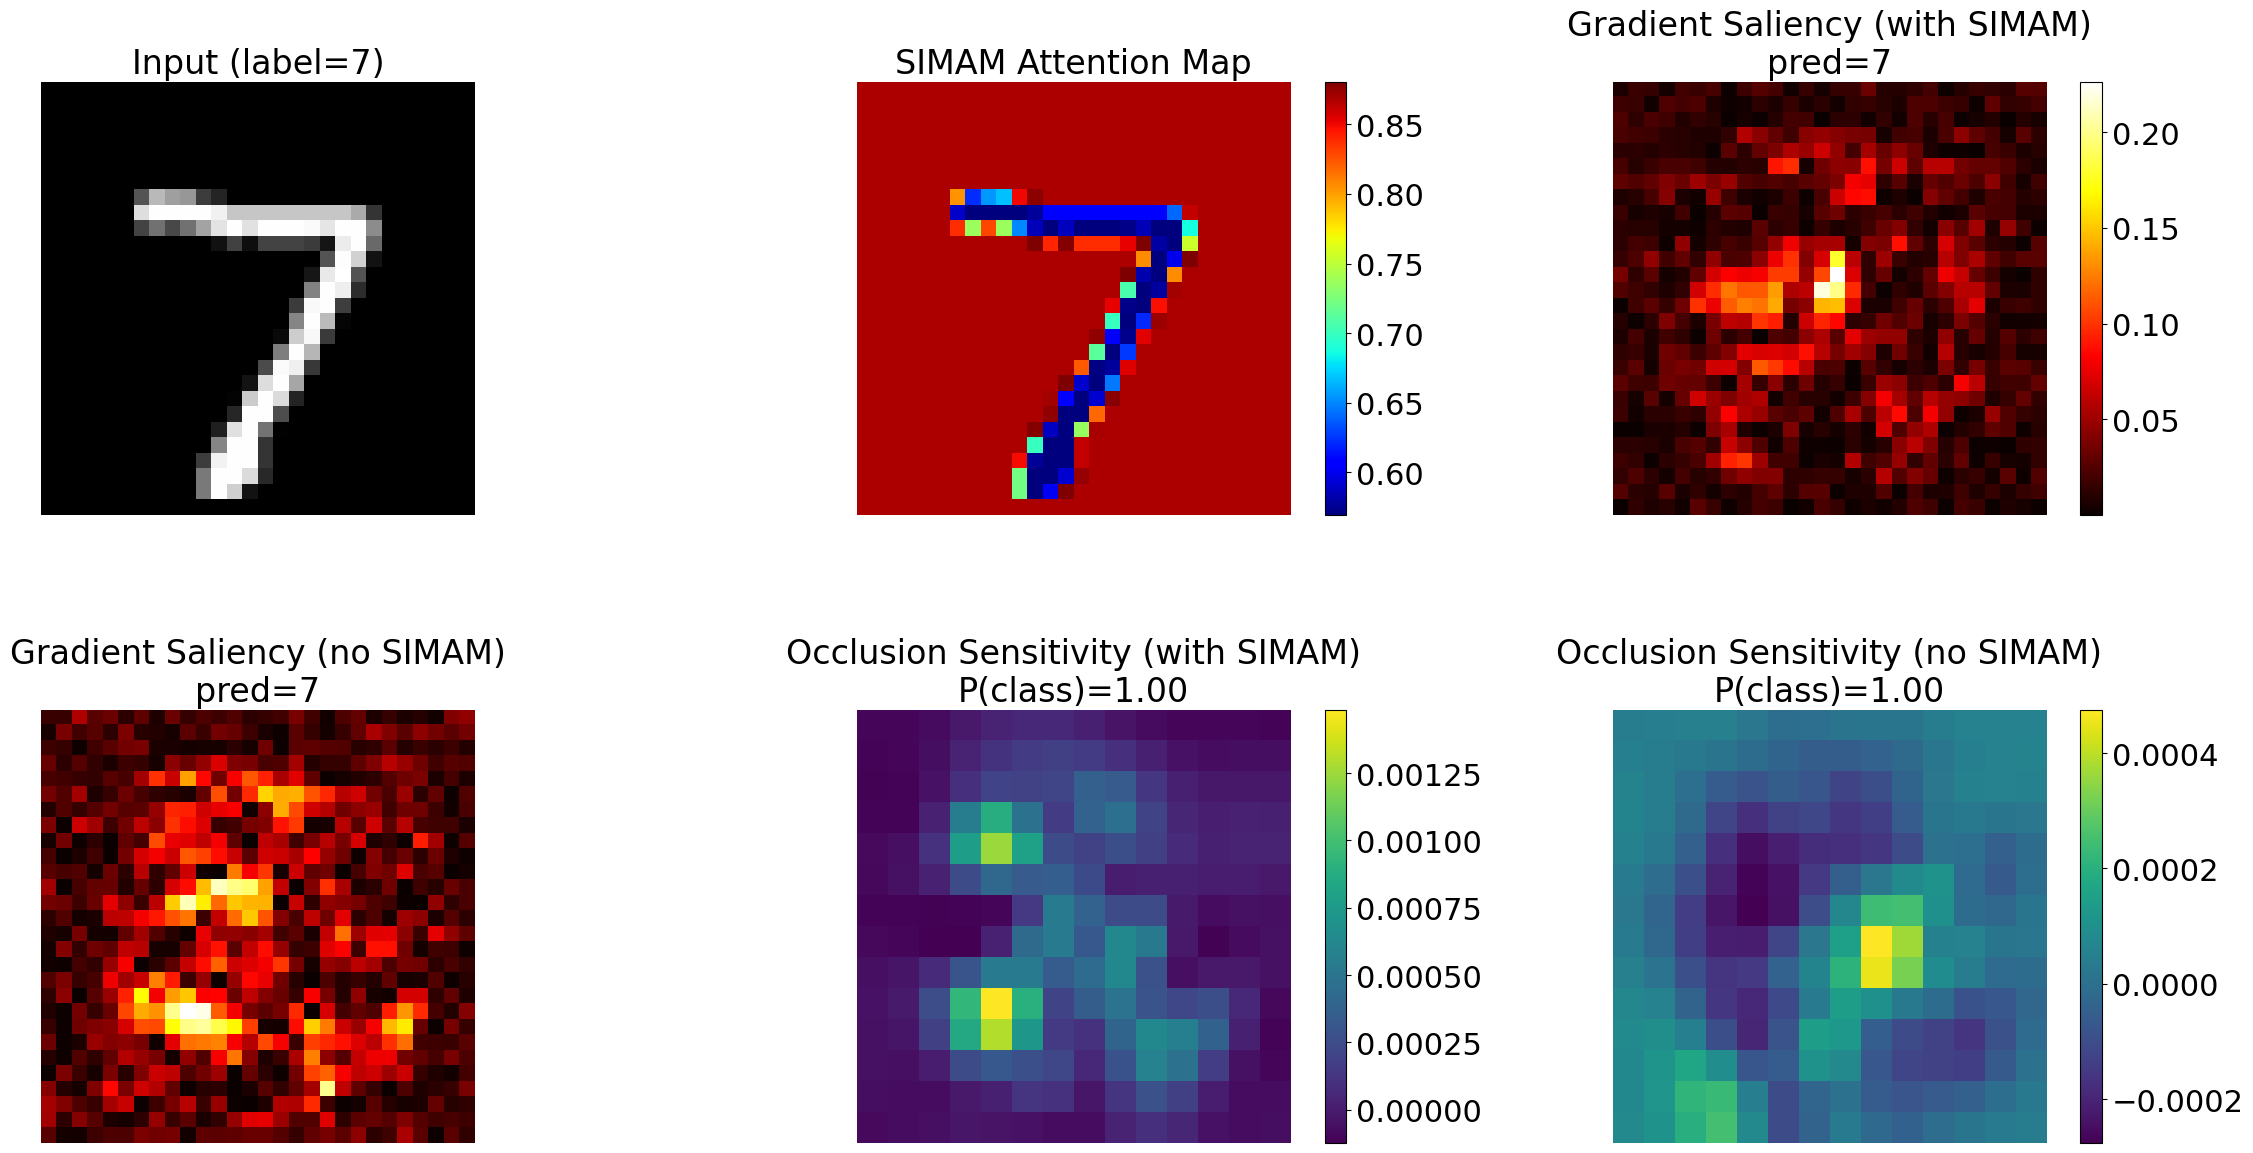

Saved: simam_comparison.png


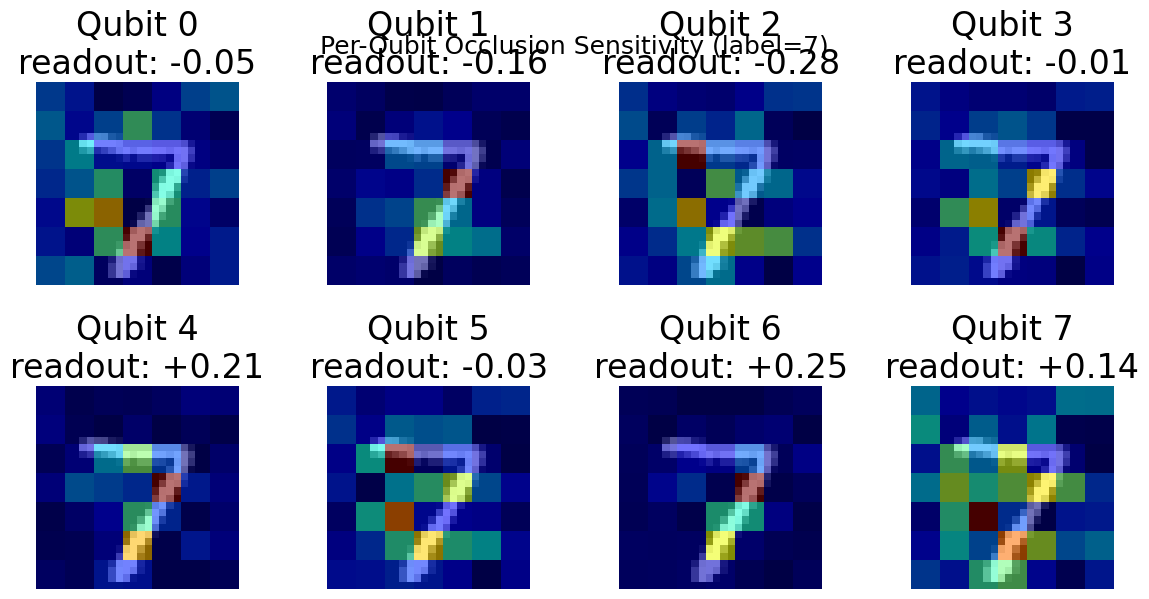

Saved: per_qubit_occlusion.png


In [41]:
# ============================================================
# Interpretability Analysis: SIMAM vs. No-SIMAM
#
# Produces, for a chosen test image:
#   1. SIMAM attention heatmap (direct)
#   2. Vanilla-gradient saliency map      (with vs. without SIMAM)
#   3. Occlusion sensitivity map          (with vs. without SIMAM)
#   4. Per-qubit occlusion sensitivity    (with vs. without SIMAM)
#
# Assumes SIMAM, quantum_circuit, quantum_layer, NUM_QUBITS,
# NUM_LAYERS, DEVICE, transform, and a trained checkpoint already
# exist (as produced by the main training notebook). If no
# checkpoint is found, the script falls back to randomly
# initialized weights purely for demonstrating the pipeline.
# ============================================================

import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import cm


# ------------------------------------------------------------
# 1. Toggleable DeepQNN (adds a use_simam switch)
# ------------------------------------------------------------

class DeepQNN_Toggle(nn.Module):
    """
    Same architecture as DeepQNN, but SIMAM can be switched
    on/off at construction time so the two variants share
    everything except the attention step.
    """

    def __init__(self, num_classes, quantum_layer_module,
                 num_qubits, use_simam=True, e_lambda=1e-4):
        super().__init__()

        self.use_simam = use_simam
        self.simam = SIMAM(e_lambda=e_lambda)

        self.classical = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_qubits),
        )

        self.quantum = quantum_layer_module

        self.classifier = nn.Sequential(
            nn.Linear(num_qubits, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def get_attention_map(self, x):
        """Returns the SIMAM attention weights only (for plotting)."""
        b, c, h, w = x.size()
        n = h * w - 1
        mean = x.mean(dim=(2, 3), keepdim=True)
        sq_diff = (x - mean) ** 2
        var = sq_diff.sum(dim=(2, 3), keepdim=True) / n
        energy = sq_diff / (4 * (var + self.simam.e_lambda)) + 0.5
        return torch.sigmoid(1.0 / energy)

    def forward(self, x, return_quantum_features=False):
        x = self.simam(x) if self.use_simam else x
        x = x.flatten(start_dim=1)
        x = self.classical(x)
        x = torch.tanh(x) * np.pi

        q_device = x.device
        q_out = self.quantum(x.cpu()).to(q_device)

        logits = self.classifier(q_out)

        if return_quantum_features:
            return logits, q_out
        return logits


# ------------------------------------------------------------
# 2. Build the two model variants (shares quantum layer + weights
#    so the comparison isolates the effect of SIMAM specifically)
# ------------------------------------------------------------

def build_model_pair(num_classes, checkpoint_path="best_model_checkpoint.pth"):
    """
    Returns (model_with_simam, model_without_simam).
    Both share identical classical/quantum weights loaded from
    a checkpoint trained WITH SimAM; only the SIMAM step differs
    at forward time. This isolates the causal effect of SIMAM
    on an otherwise identical network.
    """
    model_with = DeepQNN_Toggle(
        num_classes, quantum_layer, NUM_QUBITS, use_simam=True
    ).to(DEVICE)

    try:
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        model_with.load_state_dict(ckpt["model_state_dict"], strict=False)
        print(f"Loaded checkpoint: {checkpoint_path} (epoch {ckpt.get('epoch')})")
    except FileNotFoundError:
        print(f"No checkpoint found at {checkpoint_path} — using random init "
              f"(pipeline demo only, not the trained model).")

    model_without = copy.deepcopy(model_with)
    model_without.use_simam = False

    model_with.eval()
    model_without.eval()
    return model_with, model_without


# ------------------------------------------------------------
# 3. Vanilla-gradient saliency (FC-model analogue of Grad-CAM)
# ------------------------------------------------------------

def gradient_saliency(model, image, target_class=None):
    """
    image: tensor [1, 1, 28, 28], requires_grad will be set internally.
    Returns a [28, 28] saliency map = |d logit_target / d pixel|.
    """
    img = image.clone().detach().to(DEVICE)
    img.requires_grad_(True)

    logits = model(img)
    if target_class is None:
        target_class = logits.argmax(dim=1).item()

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    saliency = img.grad.data.abs().squeeze().cpu().numpy()
    return saliency, target_class


# ------------------------------------------------------------
# 4. Occlusion sensitivity (image-level, patch-based)
# ------------------------------------------------------------

def occlusion_sensitivity(model, image, target_class=None,
                           patch_size=4, stride=2, baseline_value=0.0):
    """
    Slides an occluding patch over the image and records the drop
    in the target class's predicted probability at each location.
    Returns a [H, W]-shaped sensitivity map (upsampled to full image).
    """
    model.eval()
    img = image.clone().to(DEVICE)

    with torch.no_grad():
        base_logits = model(img)
        base_probs = torch.softmax(base_logits, dim=1)
        if target_class is None:
            target_class = base_probs.argmax(dim=1).item()
        base_score = base_probs[0, target_class].item()

    _, _, H, W = img.shape
    heatmap = np.zeros((H, W))
    counts = np.zeros((H, W))

    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                occluded = img.clone()
                occluded[:, :, y:y + patch_size, x:x + patch_size] = baseline_value

                probs = torch.softmax(model(occluded), dim=1)
                score = probs[0, target_class].item()
                drop = base_score - score

                heatmap[y:y + patch_size, x:x + patch_size] += drop
                counts[y:y + patch_size, x:x + patch_size] += 1

    counts[counts == 0] = 1
    heatmap = heatmap / counts
    return heatmap, target_class, base_score


# ------------------------------------------------------------
# 5. Per-qubit occlusion sensitivity (as in Fig. 4 of the paper)
# ------------------------------------------------------------

def per_qubit_occlusion_sensitivity(model, image, patch_size=4, stride=4):
    """
    For each qubit's expectation value <Z_i>, measures how much
    occluding each image patch changes that specific qubit's readout.
    Returns array of shape [NUM_QUBITS, H, W].
    """
    model.eval()
    img = image.clone().to(DEVICE)

    with torch.no_grad():
        _, base_q = model(img, return_quantum_features=True)
        base_q = base_q.squeeze().cpu().numpy()  # [NUM_QUBITS]

    _, _, H, W = img.shape
    num_qubits = base_q.shape[0]
    heatmaps = np.zeros((num_qubits, H, W))
    counts = np.zeros((H, W))

    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                occluded = img.clone()
                occluded[:, :, y:y + patch_size, x:x + patch_size] = 0.0

                _, q_out = model(occluded, return_quantum_features=True)
                q_out = q_out.squeeze().cpu().numpy()

                delta = np.abs(base_q - q_out)
                for qi in range(num_qubits):
                    heatmaps[qi, y:y + patch_size, x:x + patch_size] += delta[qi]
                counts[y:y + patch_size, x:x + patch_size] += 1

    counts[counts == 0] = 1
    for qi in range(num_qubits):
        heatmaps[qi] /= counts

    return heatmaps


# ------------------------------------------------------------
# 6. Plotting utilities
# ------------------------------------------------------------

def _to_display_image(img_tensor):
    """Undo Normalize((0.1307,), (0.3081,)) for display."""
    arr = img_tensor.squeeze().detach().cpu().numpy()
    return arr * 0.3081 + 0.1307


def plot_simam_vs_no_simam(model_with, model_without, image, true_label,
                            class_names=None, save_path="simam_comparison.png"):
    """
    Main comparison figure:
      Row 1: input | SIMAM attention map | gradient saliency (with SIMAM)
      Row 2: --    | occlusion map (with SIMAM) | occlusion map (without SIMAM)
    """
    img = image.unsqueeze(0) if image.dim() == 3 else image
    img = img.to(DEVICE)

    # SIMAM attention map (direct)
    with torch.no_grad():
        attn_map = model_with.get_attention_map(img).squeeze().cpu().numpy()

    # Gradient saliency, with vs. without SIMAM
    sal_with, pred_with = gradient_saliency(model_with, img)
    sal_without, pred_without = gradient_saliency(model_without, img)

    # Occlusion sensitivity, with vs. without SIMAM
    occ_with, _, score_with = occlusion_sensitivity(model_with, img)
    occ_without, _, score_without = occlusion_sensitivity(model_without, img)

    disp_img = _to_display_image(img)

    fig, axes = plt.subplots(2, 3, figsize=(24, 12))

    axes[0, 0].imshow(disp_img, cmap="gray")
    axes[0, 0].set_title(f"Input (label={true_label})")
    axes[0, 0].axis("off")

    im1 = axes[0, 1].imshow(attn_map, cmap="jet")
    axes[0, 1].set_title("SIMAM Attention Map")
    axes[0, 1].axis("off")
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    im2 = axes[0, 2].imshow(sal_with, cmap="hot")
    axes[0, 2].set_title(f"Gradient Saliency (with SIMAM)\npred={pred_with}")
    axes[0, 2].axis("off")
    fig.colorbar(im2, ax=axes[0, 2], fraction=0.046)

    axes[1, 0].imshow(sal_without, cmap="hot")
    axes[1, 0].set_title(f"Gradient Saliency (no SIMAM)\npred={pred_without}")
    axes[1, 0].axis("off")

    im4 = axes[1, 1].imshow(occ_with, cmap="viridis")
    axes[1, 1].set_title(f"Occlusion Sensitivity (with SIMAM)\nP(class)={score_with:.2f}")
    axes[1, 1].axis("off")
    fig.colorbar(im4, ax=axes[1, 1], fraction=0.046)

    im5 = axes[1, 2].imshow(occ_without, cmap="viridis")
    axes[1, 2].set_title(f"Occlusion Sensitivity (no SIMAM)\nP(class)={score_without:.2f}")
    axes[1, 2].axis("off")
    fig.colorbar(im5, ax=axes[1, 2], fraction=0.046)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.45)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def plot_per_qubit_occlusion(model, image, true_label,
                              save_path="per_qubit_occlusion.png"):
    """
    Grid of per-qubit occlusion sensitivity maps, replicating
    the style of Fig. 4 (readout influence per qubit).
    """
    img = image.unsqueeze(0) if image.dim() == 3 else image
    img = img.to(DEVICE)

    heatmaps = per_qubit_occlusion_sensitivity(model, img)
    num_qubits = heatmaps.shape[0]

    with torch.no_grad():
        _, q_out = model(img, return_quantum_features=True)
        q_out = q_out.squeeze().cpu().numpy()

    disp_img = _to_display_image(img)

    cols = 4
    rows = int(np.ceil(num_qubits / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = axes.flatten()

    for qi in range(num_qubits):
        ax = axes[qi]
        ax.imshow(disp_img, cmap="gray")
        ax.imshow(heatmaps[qi], cmap="jet", alpha=0.55)
        ax.set_title(f"Qubit {qi}\nreadout: {q_out[qi]:+.2f}")
        ax.axis("off")

    for qi in range(num_qubits, len(axes)):
        axes[qi].axis("off")

    fig.suptitle(f"Per-Qubit Occlusion Sensitivity (label={true_label})")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, top=0.90)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


# ------------------------------------------------------------
# 7. Example usage
# ------------------------------------------------------------

if __name__ == "__main__":
    # Build the model pair (loads trained weights if available)
    model_with_simam, model_without_simam = build_model_pair(
        num_classes=NUM_CLASSES,
        checkpoint_path="/kaggle/working/best_model_checkpoint_reconstructed.pth",
    )

    # Pick one test sample to analyze
    sample_image, sample_label = official_test_dataset[0]

    # Full with/without SIMAM comparison figure
    plot_simam_vs_no_simam(
        model_with_simam,
        model_without_simam,
        sample_image,
        sample_label,
    )

    # Per-qubit occlusion sensitivity (with SIMAM model)
    plot_per_qubit_occlusion(
        model_with_simam,
        sample_image,
        sample_label,
    )

Loaded checkpoint: /kaggle/working/best_model_checkpoint_reconstructed.pth (epoch 8)


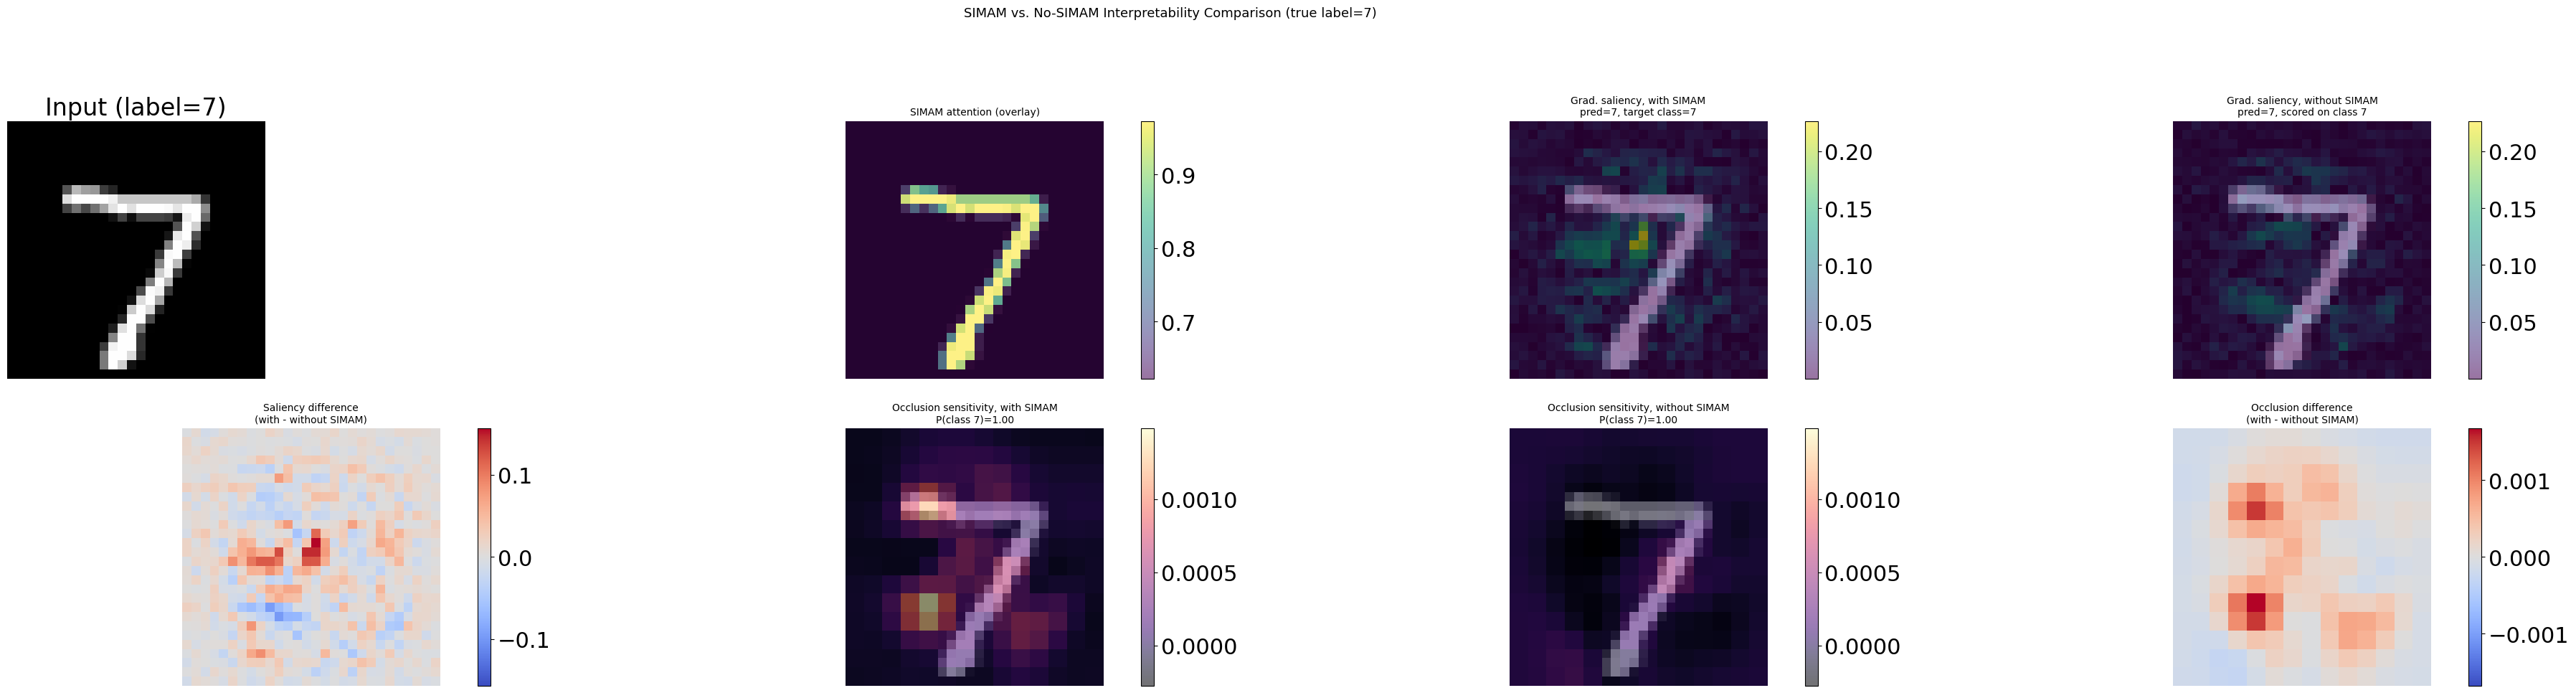

Saved: interpretability_outputs/simam_comparison_sample0.png
{
  "pred_class_with_simam": 7,
  "pred_class_without_simam": 7,
  "prediction_changed": false,
  "confidence_with_simam": 0.9990689158439636,
  "confidence_without_simam": 0.999089241027832,
  "confidence_delta": -2.0325183868408203e-05,
  "attn_saliency_corr": -0.12691511150310042,
  "saliency_ssim_with_vs_without": 0.24492021305327913,
  "occlusion_ssim_with_vs_without": -0.2116270100512727,
  "attn_foreground_energy_ratio": 0.1379936645273161,
  "saliency_with_foreground_energy_ratio": 0.06254880417359765,
  "saliency_without_foreground_energy_ratio": 0.10322163539980875,
  "attn_entropy": 1.144603286951189,
  "saliency_with_entropy": 4.29504183907387,
  "saliency_without_entropy": 4.9308685068487454
}
{
  "n_samples": 200,
  "accuracy_with_simam": 0.99,
  "accuracy_without_simam": 0.97,
  "accuracy_delta": 0.020000000000000018,
  "confidence_with_simam_mean": 0.98410705623166,
  "confidence_with_simam_std": 0.10258753907

/tmp/ipykernel_16/3108048486.py:752: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


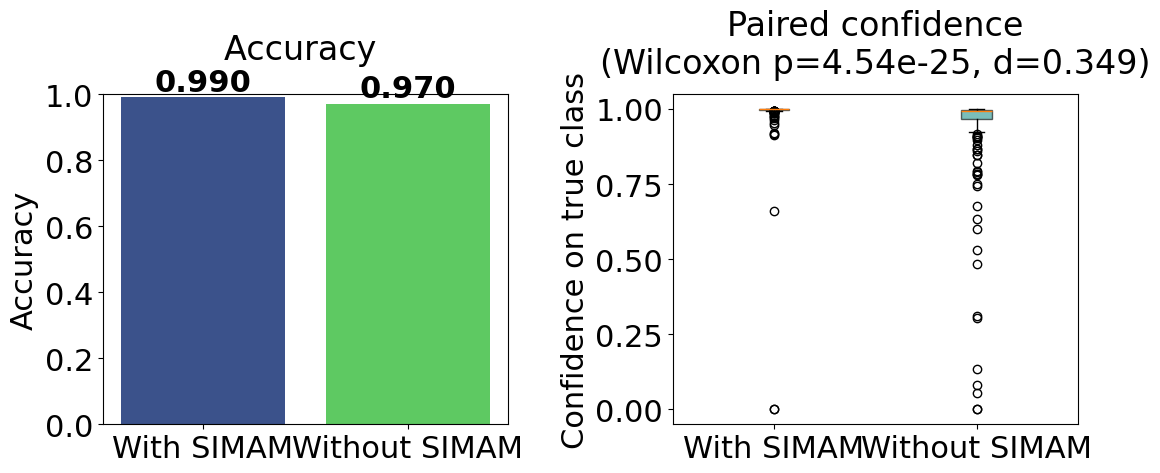

Saved: interpretability_outputs/dataset_level_comparison.png


In [42]:
# ============================================================================
# Publication-Grade Interpretability Analysis: SIMAM vs. No-SIMAM
# in a Hybrid Classical-Quantum Neural Network
# ============================================================================
#
# WHAT THIS ADDS ON TOP OF A BASIC "PLOT TWO HEATMAPS" SCRIPT
# ----------------------------------------------------------------------------
# A single before/after image is an anecdote, not evidence. To defensibly
# claim that SIMAM changes *what the network attends to* and *how well it
# performs*, this script produces:
#
#   (A) QUALITATIVE, publication-styled figures
#       - perceptually uniform colormaps (viridis / magma), not jet/hot,
#         which are known to visually distort magnitude (Borland & Taylor,
#         2007, "Rainbow Color Map (Still) Considered Harmful")
#       - SHARED color scales (vmin/vmax) between the "with" and "without"
#         panels of the same map type, so visual comparison is not an
#         artifact of independent autoscaling
#       - explicit with-minus-without DIFFERENCE maps on a diverging,
#         zero-centered colormap -- the single most legible panel for a
#         reviewer
#       - heatmaps overlaid on the input digit, not shown in isolation
#
#   (B) QUANTITATIVE, per-sample metrics
#       - Pearson correlation between the SIMAM attention map and the
#         gradient-saliency map -> does SIMAM's attention align with what
#         the classifier actually uses to decide?
#       - SSIM between saliency maps with vs. without SIMAM -> how much
#         does SIMAM restructure the evidence the network relies on?
#       - foreground-energy ratio -> fraction of attention/saliency mass
#         that falls on the digit strokes vs. background
#       - Shannon entropy of the (normalized) map -> a concentration /
#         selectivity measure (lower = more selective attention)
#       - predicted-class confidence with vs. without SIMAM
#
#   (C) DATASET-LEVEL statistics (not N=1)
#       - paired accuracy and mean confidence over N sampled test images
#         (same images run through both model variants)
#       - Wilcoxon signed-rank test on the paired confidence deltas
#         (non-parametric; doesn't assume normality of the deltas)
#       - paired Cohen's d as an effect size
#       - per-class average attention/saliency maps
#
#   (D) REPRODUCIBILITY + machine-readable outputs
#       - fixed seeds
#       - per-sample metrics -> CSV
#       - dataset-level summary -> JSON
#       - figures saved at 300 dpi
#
# Assumes SIMAM, quantum_circuit, quantum_layer, NUM_QUBITS, NUM_LAYERS,
# NUM_CLASSES, DEVICE, transform, and a trained checkpoint already exist (as
# produced by the main training notebook/script). If no checkpoint is found,
# falls back to randomly initialized weights, and every plot/result is
# labeled "DEMO (untrained weights)" so it can never be mistaken for a real
# result.
# ============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import wilcoxon, pearsonr

try:
    from skimage.metrics import structural_similarity as ssim
    _HAS_SKIMAGE = True
except ImportError:
    _HAS_SKIMAGE = False
    print("[warn] scikit-image not installed -> SSIM metric will be reported "
          "as NaN. Install with: pip install scikit-image --break-system-packages")

EPS = 1e-8


# ------------------------------------------------------------
# 0. Reproducibility
# ------------------------------------------------------------

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# 1. Toggleable DeepQNN (adds a use_simam switch)
# ------------------------------------------------------------

class DeepQNN_Toggle(nn.Module):
    """
    Same architecture as DeepQNN, but SIMAM can be switched on/off at
    construction time so the two variants share everything -- classical
    weights, quantum weights, architecture -- except the attention step.
    This is what makes the comparison causal rather than correlational:
    any difference in behavior is attributable to SIMAM specifically,
    not to some other confound (different training run, different init).
    """

    def __init__(self, num_classes, quantum_layer_module,
                 num_qubits, use_simam=True, e_lambda=1e-4):
        super().__init__()

        self.use_simam = use_simam
        self.simam = SIMAM(e_lambda=e_lambda)

        self.classical = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_qubits),
        )

        self.quantum = quantum_layer_module

        self.classifier = nn.Sequential(
            nn.Linear(num_qubits, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def get_attention_map(self, x):
        """Returns the SIMAM attention weights only (for plotting)."""
        b, c, h, w = x.size()
        n = h * w - 1
        mean = x.mean(dim=(2, 3), keepdim=True)
        sq_diff = (x - mean) ** 2
        var = sq_diff.sum(dim=(2, 3), keepdim=True) / n
        # NOTE: `energy` below is algebraically 1/e_t in SimAM's own notation
        # (e_t = 4(var+lambda) / (sq_diff + 2*var + 2*lambda)); the attention
        # weight is sigmoid(1/e_t) = sigmoid(energy), NOT sigmoid(1/energy).
        # Using sigmoid(1/energy) inverts the map: it upweights near-mean
        # (background) pixels instead of distinctive (foreground/edge) ones.
        energy = sq_diff / (4 * (var + self.simam.e_lambda)) + 0.5
        return torch.sigmoid(energy)

    def forward(self, x, return_quantum_features=False):
        x = self.simam(x) if self.use_simam else x
        x = x.flatten(start_dim=1)
        x = self.classical(x)
        x = torch.tanh(x) * np.pi

        q_device = x.device
        q_out = self.quantum(x.cpu()).to(q_device)

        logits = self.classifier(q_out)

        if return_quantum_features:
            return logits, q_out
        return logits


# ------------------------------------------------------------
# 2. Build the two model variants (shares weights so the
#    comparison isolates the effect of SIMAM specifically)
# ------------------------------------------------------------

def build_model_pair(num_classes, checkpoint_path="best_model_checkpoint.pth"):
    """
    Returns (model_with_simam, model_without_simam, is_demo).
    Both share identical classical/quantum weights loaded from a checkpoint
    trained WITH SimAM; only the SIMAM step differs at forward time.
    """
    model_with = DeepQNN_Toggle(
        num_classes, quantum_layer, NUM_QUBITS, use_simam=True
    ).to(DEVICE)

    is_demo = False
    try:
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        model_with.load_state_dict(ckpt["model_state_dict"], strict=False)
        print(f"Loaded checkpoint: {checkpoint_path} (epoch {ckpt.get('epoch')})")
    except FileNotFoundError:
        is_demo = True
        print(f"[WARNING] No checkpoint found at {checkpoint_path}. Falling back "
              f"to random init. ALL figures/metrics below are pipeline "
              f"demonstrations only and MUST NOT be reported as results.")

    import copy
    model_without = copy.deepcopy(model_with)
    model_without.use_simam = False

    model_with.eval()
    model_without.eval()
    return model_with, model_without, is_demo


# ------------------------------------------------------------
# 3. Vanilla-gradient saliency
# ------------------------------------------------------------

def gradient_saliency(model, image, target_class=None):
    """
    image: tensor [1, 1, 28, 28].
    Returns a [28, 28] saliency map = |d logit_target / d pixel|, and the
    target class actually used (so "with" and "without" runs can be scored
    against a common reference class -- see run_paired_analysis).
    """
    img = image.clone().detach().to(DEVICE)
    img.requires_grad_(True)

    logits = model(img)
    if target_class is None:
        target_class = logits.argmax(dim=1).item()

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    saliency = img.grad.data.abs().squeeze().cpu().numpy()
    return saliency, target_class


# ------------------------------------------------------------
# 4. Occlusion sensitivity (image-level, patch-based)
# ------------------------------------------------------------

def occlusion_sensitivity(model, image, target_class=None,
                           patch_size=4, stride=2, baseline_value=0.0):
    """
    Slides an occluding patch over the image and records the drop in the
    target class's predicted probability at each location. Returns a
    [H, W] sensitivity map.
    """
    model.eval()
    img = image.clone().to(DEVICE)

    with torch.no_grad():
        base_logits = model(img)
        base_probs = torch.softmax(base_logits, dim=1)
        if target_class is None:
            target_class = base_probs.argmax(dim=1).item()
        base_score = base_probs[0, target_class].item()

    _, _, H, W = img.shape
    heatmap = np.zeros((H, W))
    counts = np.zeros((H, W))

    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                occluded = img.clone()
                occluded[:, :, y:y + patch_size, x:x + patch_size] = baseline_value

                probs = torch.softmax(model(occluded), dim=1)
                score = probs[0, target_class].item()
                drop = base_score - score

                heatmap[y:y + patch_size, x:x + patch_size] += drop
                counts[y:y + patch_size, x:x + patch_size] += 1

    counts[counts == 0] = 1
    heatmap = heatmap / counts
    return heatmap, target_class, base_score


# ------------------------------------------------------------
# 5. Per-qubit occlusion sensitivity
# ------------------------------------------------------------

def per_qubit_occlusion_sensitivity(model, image, patch_size=4, stride=4):
    """
    For each qubit's expectation value <Z_i>, measures how much occluding
    each image patch changes that specific qubit's readout.
    Returns array of shape [NUM_QUBITS, H, W].
    """
    model.eval()
    img = image.clone().to(DEVICE)

    with torch.no_grad():
        _, base_q = model(img, return_quantum_features=True)
        base_q = base_q.squeeze().cpu().numpy()

    _, _, H, W = img.shape
    num_qubits = base_q.shape[0]
    heatmaps = np.zeros((num_qubits, H, W))
    counts = np.zeros((H, W))

    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                occluded = img.clone()
                occluded[:, :, y:y + patch_size, x:x + patch_size] = 0.0

                _, q_out = model(occluded, return_quantum_features=True)
                q_out = q_out.squeeze().cpu().numpy()

                delta = np.abs(base_q - q_out)
                for qi in range(num_qubits):
                    heatmaps[qi, y:y + patch_size, x:x + patch_size] += delta[qi]
                counts[y:y + patch_size, x:x + patch_size] += 1

    counts[counts == 0] = 1
    for qi in range(num_qubits):
        heatmaps[qi] /= counts

    return heatmaps


# ------------------------------------------------------------
# 6. Quantitative metrics
# ------------------------------------------------------------

def _normalize01(m):
    m = np.asarray(m, dtype=np.float64)
    lo, hi = m.min(), m.max()
    if hi - lo < EPS:
        return np.zeros_like(m)
    return (m - lo) / (hi - lo)


def shannon_entropy(m, bins=64):
    """
    Entropy of the map treated as a probability distribution over intensity
    bins. Lower entropy = more concentrated / selective attention or
    saliency; higher entropy = more diffuse.
    """
    m = _normalize01(m).ravel()
    hist, _ = np.histogram(m, bins=bins, range=(0.0, 1.0), density=False)
    p = hist / (hist.sum() + EPS)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def foreground_energy_ratio(heatmap, display_image, fg_threshold=0.35):
    """
    Fraction of a map's total energy that falls on digit-foreground pixels
    (display_image > fg_threshold) vs. background. A well-behaved
    attention/saliency map for a digit classifier should score high here.
    """
    m = np.asarray(heatmap, dtype=np.float64)
    m = np.clip(m, 0, None)  # only positive evidence counts as "energy"
    fg_mask = display_image > fg_threshold
    total = m.sum()
    if total < EPS:
        return float("nan")
    return float(m[fg_mask].sum() / total)


def pearson_map_corr(map_a, map_b):
    a = np.asarray(map_a, dtype=np.float64).ravel()
    b = np.asarray(map_b, dtype=np.float64).ravel()
    if np.std(a) < EPS or np.std(b) < EPS:
        return float("nan")
    r, _ = pearsonr(a, b)
    return float(r)


def ssim_map(map_a, map_b):
    if not _HAS_SKIMAGE:
        return float("nan")
    a = _normalize01(map_a)
    b = _normalize01(map_b)
    return float(ssim(a, b, data_range=1.0))


def compute_sample_metrics(model_with, model_without, image, display_image,
                            attn_map, sal_with, sal_without,
                            occ_with, occ_without, target_class_with,
                            target_class_without, score_with, score_without):
    """Bundles all per-sample quantitative metrics into one dict/row."""
    return {
        "pred_class_with_simam": target_class_with,
        "pred_class_without_simam": target_class_without,
        "prediction_changed": bool(target_class_with != target_class_without),
        "confidence_with_simam": float(score_with),
        "confidence_without_simam": float(score_without),
        "confidence_delta": float(score_with - score_without),
        "attn_saliency_corr": pearson_map_corr(attn_map, sal_with),
        "saliency_ssim_with_vs_without": ssim_map(sal_with, sal_without),
        "occlusion_ssim_with_vs_without": ssim_map(occ_with, occ_without),
        "attn_foreground_energy_ratio": foreground_energy_ratio(attn_map, display_image),
        "saliency_with_foreground_energy_ratio": foreground_energy_ratio(sal_with, display_image),
        "saliency_without_foreground_energy_ratio": foreground_energy_ratio(sal_without, display_image),
        "attn_entropy": shannon_entropy(attn_map),
        "saliency_with_entropy": shannon_entropy(sal_with),
        "saliency_without_entropy": shannon_entropy(sal_without),
    }


# ------------------------------------------------------------
# 7. Dataset-level, paired statistical comparison
# ------------------------------------------------------------

def run_dataset_level_comparison(model_with, model_without, dataset,
                                  n_samples=200, seed=42):
    """
    Runs both model variants on the SAME n_samples test images (paired
    design) and reports:
      - accuracy with vs. without SIMAM
      - mean +/- std confidence with vs. without SIMAM
      - Wilcoxon signed-rank test on paired confidence deltas
      - paired Cohen's d effect size
    A paired design is essential here: differences are attributed to SIMAM
    itself, not to sampling variance between two different image sets.
    """
    set_seed(seed)
    n_total = len(dataset)
    idx = random.sample(range(n_total), min(n_samples, n_total))

    rows = []
    with torch.no_grad():
        for i in idx:
            img, label = dataset[i]
            img = img.unsqueeze(0).to(DEVICE) if img.dim() == 3 else img.to(DEVICE)

            probs_with = torch.softmax(model_with(img), dim=1).squeeze().cpu().numpy()
            probs_without = torch.softmax(model_without(img), dim=1).squeeze().cpu().numpy()

            pred_with = int(np.argmax(probs_with))
            pred_without = int(np.argmax(probs_without))

            rows.append({
                "index": i,
                "true_label": int(label),
                "pred_with_simam": pred_with,
                "pred_without_simam": pred_without,
                "correct_with_simam": pred_with == int(label),
                "correct_without_simam": pred_without == int(label),
                "confidence_with_simam": float(probs_with[label]),
                "confidence_without_simam": float(probs_without[label]),
            })

    df = pd.DataFrame(rows)
    df["confidence_delta"] = df["confidence_with_simam"] - df["confidence_without_simam"]

    acc_with = df["correct_with_simam"].mean()
    acc_without = df["correct_without_simam"].mean()

    conf_with_mean, conf_with_std = df["confidence_with_simam"].mean(), df["confidence_with_simam"].std()
    conf_without_mean, conf_without_std = df["confidence_without_simam"].mean(), df["confidence_without_simam"].std()

    deltas = df["confidence_delta"].values
    if np.all(deltas == 0) or len(deltas) < 2:
        wilcoxon_stat, wilcoxon_p = float("nan"), float("nan")
    else:
        try:
            wilcoxon_stat, wilcoxon_p = wilcoxon(deltas)
            wilcoxon_stat, wilcoxon_p = float(wilcoxon_stat), float(wilcoxon_p)
        except ValueError:
            wilcoxon_stat, wilcoxon_p = float("nan"), float("nan")

    d_std = deltas.std(ddof=1)
    cohens_d = float(deltas.mean() / d_std) if d_std > EPS else float("nan")

    summary = {
        "n_samples": len(df),
        "accuracy_with_simam": float(acc_with),
        "accuracy_without_simam": float(acc_without),
        "accuracy_delta": float(acc_with - acc_without),
        "confidence_with_simam_mean": float(conf_with_mean),
        "confidence_with_simam_std": float(conf_with_std),
        "confidence_without_simam_mean": float(conf_without_mean),
        "confidence_without_simam_std": float(conf_without_std),
        "wilcoxon_statistic": wilcoxon_stat,
        "wilcoxon_p_value": wilcoxon_p,
        "paired_cohens_d": cohens_d,
    }
    return df, summary


def plot_dataset_level_summary(df, summary, save_path="dataset_level_comparison.png"):
    """Two-panel figure: accuracy bar chart + paired confidence distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(["With SIMAM", "Without SIMAM"],
                [summary["accuracy_with_simam"], summary["accuracy_without_simam"]],
                color=["#3b528b", "#5ec962"])
    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Accuracy (n={summary['n_samples']})")
    for i, v in enumerate([summary["accuracy_with_simam"], summary["accuracy_without_simam"]]):
        axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

    axes[1].boxplot(
        [df["confidence_with_simam"], df["confidence_without_simam"]],
        labels=["With SIMAM", "Without SIMAM"],
        patch_artist=True,
        boxprops=dict(facecolor="#21918c", alpha=0.6),
    )
    p_str = "n/a" if np.isnan(summary["wilcoxon_p_value"]) else f"{summary['wilcoxon_p_value']:.2e}"
    d_str = "n/a" if np.isnan(summary["paired_cohens_d"]) else f"{summary['paired_cohens_d']:.3f}"
    axes[1].set_ylabel("Confidence on true class")
    axes[1].set_title(f"Paired confidence (Wilcoxon p={p_str}, d={d_str})")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path}")


# ------------------------------------------------------------
# 8. Publication-styled qualitative figures
# ------------------------------------------------------------

def _to_display_image(img_tensor):
    """Undo Normalize((0.1307,), (0.3081,)) for display."""
    arr = img_tensor.squeeze().detach().cpu().numpy()
    return arr * 0.3081 + 0.1307


def _overlay(ax, display_image, heatmap, cmap="magma", alpha=0.55,
             vmin=None, vmax=None, title=""):
    ax.imshow(display_image, cmap="gray")
    im = ax.imshow(heatmap, cmap=cmap, alpha=alpha, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return im


def _diff_panel(ax, heatmap_diff, title=""):
    vabs = max(abs(heatmap_diff.min()), abs(heatmap_diff.max()), EPS)
    norm = TwoSlopeNorm(vmin=-vabs, vcenter=0.0, vmax=vabs)
    im = ax.imshow(heatmap_diff, cmap="coolwarm", norm=norm)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return im


def plot_simam_vs_no_simam(model_with, model_without, image, true_label,
                            is_demo=False, save_path="simam_comparison.png"):
    """
    Publication-styled comparison figure (2 rows x 4 cols):

    Row 1: input | SIMAM attention (overlay) | saliency overlay (with SIMAM)
           | saliency overlay (without SIMAM)
    Row 2: saliency difference (with-without) | occlusion overlay (with SIMAM)
           | occlusion overlay (without SIMAM) | occlusion difference (with-without)

    Saliency panels share one color scale; occlusion panels share another,
    so "with" vs. "without" is visually comparable rather than an artifact
    of independent autoscaling. Difference panels use a diverging,
    zero-centered colormap.
    """
    img = image.unsqueeze(0) if image.dim() == 3 else image
    img = img.to(DEVICE)

    with torch.no_grad():
        attn_map = model_with.get_attention_map(img).squeeze().cpu().numpy()

    sal_with, pred_with = gradient_saliency(model_with, img)
    sal_without, pred_without = gradient_saliency(model_without, img, target_class=pred_with)

    occ_with, _, score_with = occlusion_sensitivity(model_with, img, target_class=pred_with)
    occ_without, _, score_without = occlusion_sensitivity(model_without, img, target_class=pred_with)

    disp_img = _to_display_image(img)

    sal_vmin, sal_vmax = min(sal_with.min(), sal_without.min()), max(sal_with.max(), sal_without.max())
    occ_vmin, occ_vmax = min(occ_with.min(), occ_without.min()), max(occ_with.max(), occ_without.max())

    fig, axes = plt.subplots(2, 4, figsize=(40, 10))

    title_suffix = "  [DEMO -- untrained weights]" if is_demo else ""
    fig.suptitle(f"SIMAM vs. No-SIMAM Interpretability Comparison "
                 f"(true label={true_label}){title_suffix}", fontsize=13)

    axes[0, 0].imshow(disp_img, cmap="gray")
    axes[0, 0].set_title(f"Input (label={true_label})")
    axes[0, 0].axis("off")

    im1 = _overlay(axes[0, 1], disp_img, attn_map, cmap="viridis",
                    title="SIMAM attention (overlay)")
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    im2 = _overlay(axes[0, 2], disp_img, sal_with, cmap="viridis",
                    vmin=sal_vmin, vmax=sal_vmax,
                    title=f"Grad. saliency, with SIMAM\npred={pred_with}, target class={pred_with}")
    fig.colorbar(im2, ax=axes[0, 2], fraction=0.046)

    im3 = _overlay(axes[0, 3], disp_img, sal_without, cmap="viridis",
                    vmin=sal_vmin, vmax=sal_vmax,
                    title=f"Grad. saliency, without SIMAM\npred={pred_without}, scored on class {pred_with}")
    fig.colorbar(im3, ax=axes[0, 3], fraction=0.046)

    sal_diff = sal_with - sal_without
    im4 = _diff_panel(axes[1, 0], sal_diff, title="Saliency difference\n(with - without SIMAM)")
    fig.colorbar(im4, ax=axes[1, 0], fraction=0.046)

    im5 = _overlay(axes[1, 1], disp_img, occ_with, cmap="magma",
                    vmin=occ_vmin, vmax=occ_vmax,
                    title=f"Occlusion sensitivity, with SIMAM\nP(class {pred_with})={score_with:.2f}")
    fig.colorbar(im5, ax=axes[1, 1], fraction=0.046)

    im6 = _overlay(axes[1, 2], disp_img, occ_without, cmap="magma",
                    vmin=occ_vmin, vmax=occ_vmax,
                    title=f"Occlusion sensitivity, without SIMAM\nP(class {pred_with})={score_without:.2f}")
    fig.colorbar(im6, ax=axes[1, 2], fraction=0.046)

    occ_diff = occ_with - occ_without
    im7 = _diff_panel(axes[1, 3], occ_diff, title="Occlusion difference\n(with - without SIMAM)")
    fig.colorbar(im7, ax=axes[1, 3], fraction=0.046)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path}")

    metrics = compute_sample_metrics(
        model_with, model_without, img, disp_img, attn_map,
        sal_with, sal_without, occ_with, occ_without,
        pred_with, pred_without, score_with, score_without,
    )
    return metrics


def plot_per_qubit_occlusion(model, image, true_label,
                              save_path="per_qubit_occlusion.png"):
    """Grid of per-qubit occlusion sensitivity maps (readout influence per qubit)."""
    img = image.unsqueeze(0) if image.dim() == 3 else image
    img = img.to(DEVICE)

    heatmaps = per_qubit_occlusion_sensitivity(model, img)
    num_qubits = heatmaps.shape[0]

    with torch.no_grad():
        _, q_out = model(img, return_quantum_features=True)
        q_out = q_out.squeeze().cpu().numpy()

    disp_img = _to_display_image(img)

    cols = 4
    rows = int(np.ceil(num_qubits / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).flatten()

    for qi in range(num_qubits):
        ax = axes[qi]
        ax.imshow(disp_img, cmap="gray")
        ax.imshow(heatmaps[qi], cmap="magma", alpha=0.55)
        ax.set_title(f"Qubit {qi}\nreadout: {q_out[qi]:+.2f}", fontsize=9)
        ax.axis("off")

    for qi in range(num_qubits, len(axes)):
        axes[qi].axis("off")

    fig.suptitle(f"Per-Qubit Occlusion Sensitivity (label={true_label})")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, top=0.90)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path}")


# ------------------------------------------------------------
# 9. Per-class average attention maps (aggregate evidence)
# ------------------------------------------------------------

def compute_class_average_maps(model_with, dataset, num_classes,
                                samples_per_class=20, seed=42):
    """
    Averages the SIMAM attention map over `samples_per_class` examples of
    each class, so the qualitative story ("SIMAM focuses on digit strokes")
    is backed by an aggregate, not one cherry-picked image.
    """
    set_seed(seed)
    by_class = {c: [] for c in range(num_classes)}
    idx_order = list(range(len(dataset)))
    random.shuffle(idx_order)

    for i in idx_order:
        _, label = dataset[i]
        label = int(label)
        if len(by_class[label]) < samples_per_class:
            by_class[label].append(i)
        if all(len(v) >= samples_per_class for v in by_class.values()):
            break

    avg_maps = {}
    with torch.no_grad():
        for c, indices in by_class.items():
            maps = []
            for i in indices:
                img, _ = dataset[i]
                img = img.unsqueeze(0).to(DEVICE) if img.dim() == 3 else img.to(DEVICE)
                attn = model_with.get_attention_map(img).squeeze().cpu().numpy()
                maps.append(_normalize01(attn))
            if maps:
                avg_maps[c] = np.mean(maps, axis=0)
    return avg_maps


def plot_class_average_maps(avg_maps, save_path="class_average_attention.png"):
    classes = sorted(avg_maps.keys())
    cols = 5
    rows = int(np.ceil(len(classes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, c in zip(axes, classes):
        im = ax.imshow(avg_maps[c], cmap="viridis")
        ax.set_title(f"Class {c}", fontsize=10)
        ax.axis("off")

    for ax in axes[len(classes):]:
        ax.axis("off")

    fig.suptitle("Average SIMAM Attention per Class")
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path}")


def plot_dataset_level_summary(df, summary, save_path="dataset_level_comparison.png"):
    """Two-panel figure: accuracy bar chart + paired confidence distribution."""

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ------------------------------------------------------------
    # Accuracy bar chart
    # ------------------------------------------------------------
    accuracy_values = [
        summary["accuracy_with_simam"],
        summary["accuracy_without_simam"]
    ]

    axes[0].bar(
        ["With SIMAM", "Without SIMAM"],
        accuracy_values,
        color=["#3b528b", "#5ec962"]
    )

    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(
        f"Accuracy ",
        # (n={summary['n_samples']})
        pad=25
    )

    for i, v in enumerate(accuracy_values):
        axes[0].text(
            i,
            v + 0.02,
            f"{v:.3f}",
            ha="center",
            fontweight="bold"
        )

    # ------------------------------------------------------------
    # Confidence boxplot
    # ------------------------------------------------------------
    axes[1].boxplot(
        [
            df["confidence_with_simam"],
            df["confidence_without_simam"]
        ],
        labels=["With SIMAM", "Without SIMAM"],
        patch_artist=True,
        boxprops=dict(
            facecolor="#21918c",
            alpha=0.6
        )
    )

    p_str = (
        "n/a"
        if np.isnan(summary["wilcoxon_p_value"])
        else f"{summary['wilcoxon_p_value']:.2e}"
    )

    d_str = (
        "n/a"
        if np.isnan(summary["paired_cohens_d"])
        else f"{summary['paired_cohens_d']:.3f}"
    )

    axes[1].set_ylabel("Confidence on true class")
    axes[1].set_title(
        f"Paired confidence\n(Wilcoxon p={p_str}, d={d_str})",
        pad=15
    )

    # ------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------
    plt.tight_layout(pad=2.0)

    # Reserve extra space above subplots
    fig.subplots_adjust(top=0.86)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {save_path}")
    
# ------------------------------------------------------------
# 10. Orchestration
# ------------------------------------------------------------

if __name__ == "__main__":
    set_seed(42)

    model_with_simam, model_without_simam, is_demo = build_model_pair(
        num_classes=NUM_CLASSES,
        checkpoint_path="/kaggle/working/best_model_checkpoint_reconstructed.pth",
    )

    os.makedirs("interpretability_outputs", exist_ok=True)

    # --- (A) single-image qualitative figure + its quantitative metrics ---
    sample_image, sample_label = official_test_dataset[0]
    sample_metrics = plot_simam_vs_no_simam(
        model_with_simam, model_without_simam, sample_image, sample_label,
        is_demo=is_demo,
        save_path="interpretability_outputs/simam_comparison_sample0.png",
    )
    print(json.dumps(sample_metrics, indent=2))

    # plot_per_qubit_occlusion(
    #     model_with_simam, sample_image, sample_label,
    #     save_path="interpretability_outputs/per_qubit_occlusion_sample0.png",
    # )

    # --- (B) dataset-level, paired statistical comparison ---
    df, summary = run_dataset_level_comparison(
        model_with_simam, model_without_simam, official_test_dataset,
        n_samples=200, seed=42,
    )
    df.to_csv("interpretability_outputs/paired_per_sample_results.csv", index=False)
    with open("interpretability_outputs/dataset_level_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print(json.dumps(summary, indent=2))

    plot_dataset_level_summary(
        df, summary,
        save_path="interpretability_outputs/dataset_level_comparison.png",
    )

    # --- (C) per-class aggregate attention maps ---
    avg_maps = compute_class_average_maps(
        model_with_simam, official_test_dataset, NUM_CLASSES,
        samples_per_class=20, seed=42,
    )
    # plot_class_average_maps(
    #     avg_maps,
    #     save_path="interpretability_outputs/class_average_attention.png",
    # )

    if is_demo:
        print("\n[REMINDER] No trained checkpoint was found -- all figures and "
              "metrics above were produced from randomly initialized weights "
              "and are for pipeline verification only.")